# Production Code

## Data Split

We set up a random seed first for reproducibility. **NOTE** that this guarantees deterministic behavior only on the same machine, same OS, same PyTorch version, same hardware.

In [1]:
import random
import numpy as np
import torch

#-----------------------
# Set random seed
#-----------------------

seed = 42
def set_seed(seed):
    random.seed(seed) # python
    np.random.seed(seed) # numpy
    torch.manual_seed(seed) # PyTorch CPU RNG
    torch.cuda.manual_seed_all(seed) # PyTorch CUDA RNG
    # further torch determinism would severely impact transformer CPU/GPU efficiency

set_seed(seed)

**Set up the data for train-evaluate-test.**

1. Create the database by reading the CSV file into a pandas `DataFrame`.

2. Remove the 20% hold-out set. Use random split with a set seed value for reproducibility.

3. Get the indices for the 5x5 fold CV split. These indices will be used like this: `enumerate(kf.split(dataset))`, where `dataset` can be any of the uniquely defined dataset classes.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, RepeatedKFold

#-----------------------
# Read in the data
#-----------------------

aag_gap = pd.read_csv("AAG_adc2.csv")
aag_smiles = pd.read_csv("AAG_numbers_smiles.csv")
aag_adc2_data = aag_gap.merge(aag_smiles).astype({"Molecule":"string","SMILES":"string","dE(S0-S1)":"float","dE(S0-T1)":"float","dE(S1-T1)":"float","f12(S0-S1)":"float"})

# generate binary data for classification and post-hoc filtering
threshold = 0.0
aag_adc2_data["stg_binary"] = (aag_adc2_data["dE(S1-T1)"] >= threshold).astype(int)

#-----------------------
# Split the data
#-----------------------

train_cv_df, test_df = train_test_split(aag_adc2_data, test_size=0.2, shuffle=True, random_state=seed) # shuffle=True ensures random pick, otherwise just get the first 80% and last 20% indices
train_cv_smiles = train_cv_df["SMILES"].values
train_cv_stg = train_cv_df["dE(S1-T1)"].values # train_cv_df["dE(S1-T1)"].to_numpy(dtype=float) might be better

rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=seed)

# example use:

# for train_idx, val_idx in rkf.split(X_train):
#     X_tr, X_val = X_train[train_idx], X_train[val_idx]
#     y_tr, y_val = y_train[train_idx], y_train[val_idx]
#     # train + evaluate your model here

## XGBoost

In [3]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

def smiles_to_fp(smiles, fpSize=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(fpSize, dtype=np.int8)
    
    fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=fpSize)
    fp = fp_gen.GetFingerprint(mol)
    arr = np.zeros((fpSize,), dtype=np.int8)
    
    Chem.DataStructs.ConvertToNumpyArray(fp, arr) # converting the ExplicitBitVect to numpy and then doing further operations is faster than doing something like torch.tensor(X, dtype=torch.float32) directly, maybe change the Dataset code for the other models... 
    return arr


### Hyperparameter Optimization

> We use the entire 80% training split, not the 5x5 CV splits

In [4]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
import json

# y = train_cv_stg
y = train_cv_df["dE(S1-T1)"].to_numpy(dtype=float)

def objective(trial):
    # Define the hyperparameter search space
    fpSize = trial.suggest_categorical("fpSize", [512, 1024, 2048])
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": seed,
        "tree_method": "hist",
    }

    X = np.vstack([smiles_to_fp(smiles, fpSize) for smiles in train_cv_smiles]) # fingerprint radius is fixed to 2
    model = XGBRegressor(**params)

    # internal CV, unrelated to the 5x5 CV
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)
    scores = cross_val_score(
        model, X, y,
        scoring="neg_mean_squared_error",
        cv=cv,
        n_jobs=-1
    )

    # Optuna minimizes the objective, so return positive MSE
    return -scores.mean()

# Create and run the study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best trial:")
print(study.best_trial.params)

# save results
with open("xgboost_optparams.json", "w") as f:
    json.dump(study.best_trial.params, f)

[I 2026-05-18 14:29:22,966] A new study created in memory with name: no-name-9049a7fa-2e6e-4594-8511-0d1399993ba6
[I 2026-05-18 14:30:22,408] Trial 0 finished with value: 0.04041483044676814 and parameters: {'fpSize': 2048, 'n_estimators': 273, 'max_depth': 9, 'learning_rate': 0.0017929809551048925, 'subsample': 0.7962364820329539, 'colsample_bytree': 0.8726314938790718, 'min_child_weight': 2}. Best is trial 0 with value: 0.04041483044676814.
[I 2026-05-18 14:30:49,722] Trial 1 finished with value: 0.025741464199687297 and parameters: {'fpSize': 512, 'n_estimators': 535, 'max_depth': 6, 'learning_rate': 0.013745259547674934, 'subsample': 0.7425312727535269, 'colsample_bytree': 0.9285964172692027, 'min_child_weight': 10}. Best is trial 1 with value: 0.025741464199687297.
[I 2026-05-18 14:31:29,617] Trial 2 finished with value: 0.04514436352081157 and parameters: {'fpSize': 2048, 'n_estimators': 205, 'max_depth': 3, 'learning_rate': 0.006887640847893983, 'subsample': 0.8846810079380252, 

Best trial:
{'fpSize': 512, 'n_estimators': 565, 'max_depth': 10, 'learning_rate': 0.142289979510285, 'subsample': 0.9154689937417197, 'colsample_bytree': 0.7288373928085079, 'min_child_weight': 8}


### 5x5 CV

In [9]:
import json
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#-----------------------
# load results
#-----------------------

with open("xgboost_optparams.json", "r") as f:
    optparams = json.load(f)
fpSize = optparams["fpSize"]
model_params = {k: v for k, v in optparams.items() if k != "fpSize"}

#-----------------------
# do the 5x5 CV
#-----------------------

cv_mae_tr = []
cv_rmse_tr = []
cv_mse_tr = []
cv_R2_tr = []
cv_mae_val = []
cv_rmse_val = []
cv_mse_val = []
cv_R2_val = []
for fold, (train_idx, val_idx) in enumerate(rkf.split(train_cv_df)):
    model = XGBRegressor(**model_params)
    X_tr_, X_val_ = train_cv_df["SMILES"].values[train_idx], train_cv_df["SMILES"].values[val_idx]
    X_tr = np.vstack([smiles_to_fp(smiles, fpSize) for smiles in X_tr_])
    X_val = np.vstack([smiles_to_fp(smiles, fpSize) for smiles in X_val_])
    y_tr, y_val = train_cv_df["dE(S1-T1)"].to_numpy(dtype=float)[train_idx], train_cv_df["dE(S1-T1)"].to_numpy(dtype=float)[val_idx]

    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    preds = model.predict(X_tr)
    cv_mae_tr.append(mean_absolute_error(y_tr, preds))
    cv_rmse_tr.append(root_mean_squared_error(y_tr, preds))
    cv_mse_tr.append(mean_squared_error(y_tr, preds))
    cv_R2_tr.append(r2_score(y_tr, preds))

    preds = model.predict(X_val)
    cv_mae_val.append(mean_absolute_error(y_val, preds))
    cv_rmse_val.append(root_mean_squared_error(y_val, preds))
    cv_mse_val.append(mean_squared_error(y_val, preds))
    cv_R2_val.append(r2_score(y_val, preds))

    print("------------------------")
    print(f"CV loop {fold} finished with: train_loss={cv_mse_tr[-1]:.4f}, val_loss={cv_mse_val[-1]:.4f}")
    print("------------------------")


#-----------------------
# save results
#-----------------------

cv_df_tr = pd.DataFrame({"subset": "train", "mae": cv_mae_tr, "mse": cv_mse_tr, "rmse": cv_rmse_tr, "R2": cv_R2_tr})
cv_df_val = pd.DataFrame({"subset": "valid", "mae": cv_mae_val, "mse": cv_mse_val, "rmse": cv_rmse_val, "R2": cv_R2_val})
cv_df = pd.concat([cv_df_tr, cv_df_val], ignore_index=True)
cv_df.to_csv("xgboost_5x5CV.csv")

------------------------
CV loop 0 finished with: train_loss=0.0022, val_loss=0.0076
------------------------
------------------------
CV loop 1 finished with: train_loss=0.0022, val_loss=0.0075
------------------------
------------------------
CV loop 2 finished with: train_loss=0.0022, val_loss=0.0075
------------------------
------------------------
CV loop 3 finished with: train_loss=0.0023, val_loss=0.0074
------------------------
------------------------
CV loop 4 finished with: train_loss=0.0023, val_loss=0.0074
------------------------
------------------------
CV loop 5 finished with: train_loss=0.0022, val_loss=0.0073
------------------------
------------------------
CV loop 6 finished with: train_loss=0.0023, val_loss=0.0075
------------------------
------------------------
CV loop 7 finished with: train_loss=0.0023, val_loss=0.0076
------------------------
------------------------
CV loop 8 finished with: train_loss=0.0023, val_loss=0.0075
------------------------
----------

### One‑Shot Evaluation

In [4]:
import matplotlib.pyplot as plt

def truepred_plotter(predvals, truevals):
    ax_min = -0.5
    ax_max = 2.
    fig = plt.figure()
    plt.scatter(truevals, predvals, color='mediumblue', alpha=0.5, marker="o")
    plt.plot([ax_min, ax_max], [ax_min, ax_max], color='gray', linestyle='--')
    plt.xlabel('True Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.xlim(ax_min, ax_max)
    plt.ylim(ax_min, ax_max)
    for ax in fig.axes:
        ax.tick_params(width=2, labelsize=12)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    plt.grid()
    plt.show()

We cheat a bit here because in the code below XGBoost is re-trained with the optimized parameters on the whole training set, which is larger than what the HPO used for training.

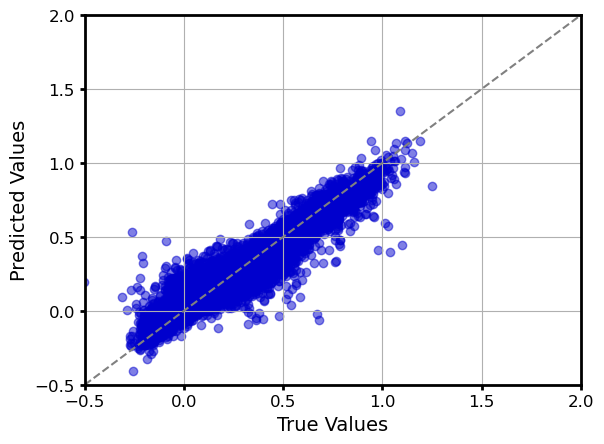

In [5]:
import json
from xgboost import XGBRegressor

#-----------------------
# train model with opt hyperparams on the initial 80% train-cv set
#-----------------------

with open("xgboost_optparams.json", "r") as f:
    optparams = json.load(f)
fpSize = optparams["fpSize"]
model_params = {k: v for k, v in optparams.items() if k != "fpSize"}

X = np.vstack([smiles_to_fp(smiles, fpSize) for smiles in train_cv_smiles])
y = train_cv_stg

model = XGBRegressor(**model_params)
model.fit(X, y, verbose=False)

#-----------------------
# predict on the test set
#-----------------------

test_smiles = test_df["SMILES"].values
X_tst = np.vstack([smiles_to_fp(smiles, fpSize) for smiles in test_smiles])
test_stg = test_df["dE(S1-T1)"].values

preds = model.predict(X_tst)

truepred_plotter(preds, test_stg)

In [6]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

rmse = root_mean_squared_error(test_stg, preds)
mse = mean_squared_error(test_stg, preds)
r2 = r2_score(test_stg, preds)

print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MSE = 0.0067
Test RMSE = 0.0819
Test R2 = 0.877


In [7]:
oneshot_results = pd.DataFrame({"model": "XGBoost", "truevals": test_stg, "predvals": preds})
oneshot_results.to_csv("XGBoost_oneshot.csv")

## Model 1

In [8]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, Subset
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class stgDataset(Dataset): # do not use this with DataLoader(..., num_workers > 0) on Windows OS !!!
    def __init__(self, smiles, stg, fp_rad, fp_size):
        super().__init__()
        assert len(smiles) == len(stg), "The lengths of smiles and stg are not equal!"
        self.stg = stg
        self.fp_rad = fp_rad
        self.fp_size = fp_size
        morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=self.fp_rad, fpSize=self.fp_size)
        fps = [] # we don't use np array because it only has advantage if we know the size beforehand and we pre-allocate it
        for s in smiles:
            mol = Chem.MolFromSmiles(s)
            if mol is None:
                raise ValueError(f"Invalid SMILES: {s}")
            # Fast bit vector fingerprint
            fp = morgan_gen.GetFingerprint(mol)
            # Convert to numpy array (fast)
            arr = np.zeros((self.fp_size,), dtype=np.int8)
            Chem.DataStructs.ConvertToNumpyArray(fp, arr)
            fps.append(arr)
        # Store fingerprints as a single contiguous tensor
        self.X = torch.tensor(np.stack(fps), dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        y = torch.tensor(self.stg[idx], dtype=torch.float32)
        return self.X[idx], y

class SimpleRegressor(nn.Module):
    def __init__(self, in_dim, d_model, out_dim, droprate):
        super(SimpleRegressor, self).__init__()
        self.input_layer = nn.Linear(in_dim, d_model)
        self.mid_layer = nn.Linear(d_model, d_model)
        self.out_layer = nn.Linear(d_model, out_dim)
        self.act = nn.SiLU() # smoother activation than ReLU
        # self.act = nn.GELU()
        self.norm = nn.LayerNorm(d_model) # stabilizes activation
        self.dropout = nn.Dropout(p=droprate) # injects noise (regularization)

    def forward(self, x):
        x = self.act(self.input_layer(x))
        x = self.norm(self.act(self.mid_layer(x)))
        x = self.dropout(x)
        output = self.out_layer(x)
        return output

def train_epoch_simplereg(model, train_loader, optimizer, loss_fn, device):

    model.train()
    total_loss = 0.0

    for data_, target_ in train_loader:
        data = data_.to(device)
        target = target_.to(device)
        outputs = model(data).squeeze(1)
        loss = loss_fn(outputs, target)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        total_loss += loss.item() * data_.size(0)
    return total_loss / len(train_loader.dataset)

def eval_simplereg(model, test_loader, loss_fn, device):

    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for data_, target_ in test_loader:
            data = data_.to(device)
            target = target_.to(device)
            outputs = model(data).squeeze(1)
            loss = loss_fn(outputs, target)
            total_loss += loss.item() * data_.size(0)
    return total_loss / len(test_loader.dataset)

### Hyperparameter Optimization

In [ ]:
import optuna
import json
import copy

def objective(trial):

    # Define the hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    fp_rad = trial.suggest_categorical("fp_rad", [2, 4])
    in_dim = trial.suggest_categorical("in_dim", [512, 1024, 2048]) # input dimension = fingerprint size
    d_model = trial.suggest_categorical("d_model", [32, 64, 128, 256])
    droprate = trial.suggest_categorical("droprate", [0.05, 0.1, 0.2])
    out_dim = 1
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True) # continuous LR search is best for optuna performance
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    num_epochs = 30

    # set up dataloaders and the model
    dataset = stgDataset(train_cv_smiles, train_cv_stg, fp_rad, in_dim)
    train_data, eval_data = random_split(dataset, [0.8, 0.2]) # internal validation
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
    eval_loader = DataLoader(eval_data, batch_size=batch_size, shuffle=False, pin_memory=True)

    model = SimpleRegressor(in_dim, d_model, out_dim, droprate).to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_state = None
    patience = 3
    wait = 0

    # train with pruning and early stopping
    for epoch in range(num_epochs):  # Max epochs
        train_loss = train_epoch_simplereg(model, train_loader, optimizer, loss_fn, device)
        val_loss = eval_simplereg(model, eval_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
        
        # Track best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if trial.should_prune():
            print(f"Trial {trial.number} pruned at epoch {epoch}")
            raise optuna.TrialPruned()

        # Early stopping
        if wait >= patience:
            print(f"Trial {trial.number} early-stopped at epoch {epoch}")
            break
        trial.report(val_loss, step=epoch)
    
    torch.save(best_state, f"model1_trial_{trial.number}.pt")
    return best_val_loss

# Create and run the study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best trial:")
print(study.best_trial.params)

# save results
with open("Model1_optparams.json", "w") as f:
    json.dump(study.best_trial.params, f)

> We do NOT store the number of epochs from the best Optuna trial. Early stopping is data dependent and need to be implemented again during the 5×5 CV and the final prediction.

### 5x5 CV

In [ ]:
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#-----------------------
# load the optimized parameters
#-----------------------

with open("Model1_optparams.json", "r") as f:
    optparams = json.load(f)

print(f"Optimized parameters loaded: {optparams}")

#-----------------------
# do the 5x5 CV
#-----------------------

batch_size = optparams["batch_size"]
fp_rad = optparams["fp_rad"]
in_dim = optparams["in_dim"]
d_model = optparams["d_model"]
droprate = optparams["droprate"]
out_dim = 1
lr = optparams["lr"]
weight_decay = optparams["weight_decay"]
num_epochs = 30

dataset = stgDataset(train_cv_smiles, train_cv_stg, fp_rad, in_dim)
loss_fn = nn.MSELoss() # stateless, doesn't matter where we initialize

train_mae_list = []
train_mse_list = []
train_rmse_list = []
train_r2_list = []

val_mae_list = []
val_mse_list = []
val_rmse_list = []
val_r2_list = []

patience = 3  # how many epochs to wait for improvement, good practice is to set it slightly higher than in optuna
min_delta = 0.0  # minimum improvement to reset patience

for fold, (train_idx, val_idx) in enumerate(rkf.split(dataset)):
    train_ds = Subset(dataset, train_idx)
    val_ds   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

    model = SimpleRegressor(in_dim, d_model, out_dim, droprate).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay) # always initialize optimizer after model

    best_val_loss = float("inf")
    patience_counter = 0
    for epoch in range(num_epochs):
        tr_loss = train_epoch_simplereg(model, train_loader, optimizer, loss_fn, device)
        tst_loss = eval_simplereg(model, val_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f}, val_loss={tst_loss:.4f}")

        # --- EARLY STOPPING LOGIC ---
        if tst_loss < best_val_loss - min_delta:
            best_val_loss = tst_loss
            patience_counter = 0
            best_state = model.state_dict()  # save best model for this fold
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break
    
    # restore best model for this fold
    model.load_state_dict(best_state)

    # ---- Compute sklearn metrics for this fold ----
    # Collect predictions for train set
    y_train_true = []
    y_train_pred = []
    model.eval()
    with torch.no_grad():
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            y_train_true.append(yb.cpu().numpy())
            y_train_pred.append(preds.cpu().numpy())

    y_train_true = np.concatenate(y_train_true)
    y_train_pred = np.concatenate(y_train_pred)

    # Collect predictions for val set
    y_val_true = []
    y_val_pred = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            y_val_true.append(yb.cpu().numpy())
            y_val_pred.append(preds.cpu().numpy())

    y_val_true = np.concatenate(y_val_true)
    y_val_pred = np.concatenate(y_val_pred)

    # Train metrics
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_mse = mean_squared_error(y_train_true, y_train_pred)
    train_rmse = root_mean_squared_error(y_train_true, y_train_pred)
    train_r2 = r2_score(y_train_true, y_train_pred)

    # Val metrics
    val_mae = mean_absolute_error(y_val_true, y_val_pred)
    val_mse = mean_squared_error(y_val_true, y_val_pred)
    val_rmse = root_mean_squared_error(y_val_true, y_val_pred)
    val_r2 = r2_score(y_val_true, y_val_pred)

    # Store metrics
    train_mae_list.append(train_mae)
    train_mse_list.append(train_mse)
    train_rmse_list.append(train_rmse)
    train_r2_list.append(train_r2)

    val_mae_list.append(val_mae)
    val_mse_list.append(val_mse)
    val_rmse_list.append(val_rmse)
    val_r2_list.append(val_r2)

    print("------------------------")
    print(f"Fold {fold} finished:")
    print(f"Train: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R2={train_r2:.4f}")
    print(f"Val:   MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R2={val_r2:.4f}")
    print("------------------------")

    # print("------------------------")
    # print(f"CV loop {fold} finished with best_val_loss={best_val_loss:.4f}")
    # print("------------------------")

#-----------------------
# save results
#-----------------------

cv_df_tr = pd.DataFrame({"subset": "train", "mae": train_mae_list, "mse": train_mse_list, "rmse": train_rmse_list, "R2": train_r2_list})
cv_df_val = pd.DataFrame({"subset": "valid", "mae": val_mae_list, "mse": val_mse_list, "rmse": val_rmse_list, "R2": val_r2_list})
cv_df = pd.concat([cv_df_tr, cv_df_val], ignore_index=True)
cv_df.to_csv("model1_5x5CV.csv")

### One‑Shot Evaluation

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def get_predictions(dtaloader, model, device="cpu"): 
    N = 0
    with torch.no_grad():
        for data_, target_ in dtaloader:
            data = data_.to(device)
            target = target_.to(device)
            # outputs = model(data).squeeze(1)
            if N == 0:
                predvals = model(data).squeeze(1)
                truevals = target
                N = 1
            else:
                predvals = torch.cat((predvals, model(data).squeeze(1)), 0)
                truevals = torch.cat((truevals, target), 0)
    print(f"Shape of pred tensor: {predvals.shape}")
    print(f"Shape of true tensor: {truevals.shape}")
    return predvals, truevals

def truepred_plotter(predvals, truevals):
    ax_min = -0.5
    ax_max = 2.
    fig = plt.figure()
    plt.scatter(truevals, predvals, color='mediumblue', alpha=0.5, marker="o")
    plt.plot([ax_min, ax_max], [ax_min, ax_max], color='gray', linestyle='--')
    plt.xlabel('True Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.xlim(ax_min, ax_max)
    plt.ylim(ax_min, ax_max)
    for ax in fig.axes:
        ax.tick_params(width=2, labelsize=12)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    plt.grid()
    plt.show()

In [14]:
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

#-----------------------
# load the optimized parameters
#-----------------------

with open("Model1_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
fp_rad = optparams["fp_rad"]
in_dim = optparams["in_dim"]
d_model = optparams["d_model"]
droprate = optparams["droprate"]
out_dim = 1

test_smiles = test_df["SMILES"].values
test_stg = test_df["dE(S1-T1)"].values
tst_ds = stgDataset(test_smiles, test_stg, fp_rad, in_dim)
test_loader = DataLoader(tst_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

model = SimpleRegressor(in_dim, d_model, out_dim, droprate).to(device)
model.load_state_dict(torch.load("model1_trial_22.pt", map_location=device))

running on cpu
Optimized parameters loaded: {'batch_size': 32, 'fp_rad': 2, 'in_dim': 2048, 'd_model': 128, 'droprate': 0.05, 'lr': 0.006559869883588499, 'weight_decay': 0.001953307275087445}


<All keys matched successfully>

c:\Users\feher\miniconda3\envs\ml_env_cpu\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape of pred tensor: torch.Size([13739])
Shape of true tensor: torch.Size([13739])


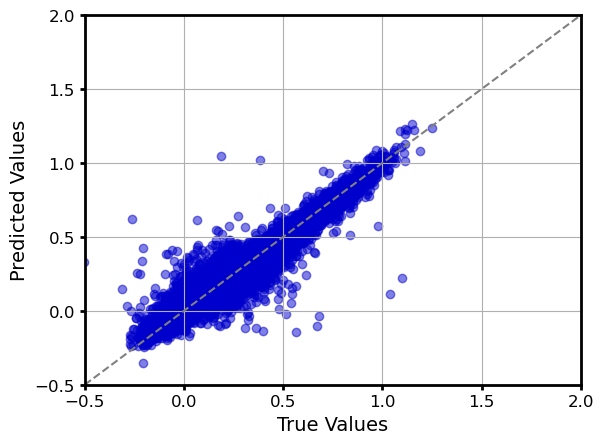

In [15]:
predvals_tensor, truevals_tensor = get_predictions(test_loader, model)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [16]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.0468
Test MSE = 0.0049
Test RMSE = 0.0698
Test R2 = 0.9108


In [17]:
oneshot_results = pd.DataFrame({"model": "model_1", "truevals": truevals, "predvals": predvals})
oneshot_results.to_csv("model1_oneshot.csv")

In [13]:
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#-----------------------
# load the optimized parameters
#-----------------------

with open("Model1_optparams.json", "r") as f:
    optparams = json.load(f)

print(f"Optimized parameters loaded: {optparams}")

#-----------------------
# train on test set
#-----------------------

batch_size = optparams["batch_size"]
fp_rad = optparams["fp_rad"]
in_dim = optparams["in_dim"]
d_model = optparams["d_model"]
droprate = optparams["droprate"]
out_dim = 1
lr = optparams["lr"]
weight_decay = optparams["weight_decay"]

# featurizer = rdFingerprintGenerator.GetMorganGenerator(radius=fp_rad, fpSize=in_dim)
# tr_ds = stgDataset(train_cv_smiles, train_cv_stg, featurizer)
tr_ds = stgDataset(train_cv_smiles, train_cv_stg, fp_rad, in_dim)
test_smiles = test_df["SMILES"].values
test_stg = test_df["dE(S1-T1)"].values
# tst_ds = stgDataset(test_smiles, test_stg, featurizer)
tst_ds = stgDataset(test_smiles, test_stg, fp_rad, in_dim)
loss_fn = nn.MSELoss()
num_epochs = 25

patience = 3  # how many epochs to wait for improvement, good practice is to set it slightly higher than in optuna
min_delta = 0.0  # minimum improvement to reset patience

train_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(tst_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

model = SimpleRegressor(in_dim, d_model, out_dim, droprate).to(device)
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay) # always initialize optimizer after model

best_val_loss = float("inf")
patience_counter = 0
for epoch in range(num_epochs):
    tr_loss = train_epoch_simplereg(model, train_loader, optimizer, loss_fn, device)
    tst_loss = eval_simplereg(model, test_loader, loss_fn, device)
    print(f"Epoch {epoch}: train_loss={tr_loss:.4f}, test_loss={tst_loss:.4f}")

    # --- EARLY STOPPING LOGIC ---
    if tst_loss < best_val_loss - min_delta:
        best_val_loss = tst_loss
        patience_counter = 0
        best_state = model.state_dict()  # save best model for this fold
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch}")
        break

# restore best model for this fold
model.load_state_dict(best_state)

print("------------------------")
print(f"Training finished with best_val_loss={best_val_loss:.4f}")
print("------------------------")

Optimized parameters loaded: {'batch_size': 64, 'fp_rad': 2, 'in_dim': 2048, 'd_model': 256, 'droprate': 0.05, 'lr': 0.0018254040779271932, 'weight_decay': 2.504323202447989e-06}


c:\Users\feher\miniconda3\envs\ml_env_cpu\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 0: train_loss=0.0619, test_loss=0.0264
Epoch 1: train_loss=0.0245, test_loss=0.0218
Epoch 2: train_loss=0.0208, test_loss=0.0194
Epoch 3: train_loss=0.0176, test_loss=0.0155
Epoch 4: train_loss=0.0135, test_loss=0.0128
Epoch 5: train_loss=0.0107, test_loss=0.0104
Epoch 6: train_loss=0.0088, test_loss=0.0085
Epoch 7: train_loss=0.0074, test_loss=0.0085
Epoch 8: train_loss=0.0064, test_loss=0.0070
Epoch 9: train_loss=0.0056, test_loss=0.0065
Epoch 10: train_loss=0.0048, test_loss=0.0063
Epoch 11: train_loss=0.0043, test_loss=0.0057
Epoch 12: train_loss=0.0038, test_loss=0.0053
Epoch 13: train_loss=0.0034, test_loss=0.0051
Epoch 14: train_loss=0.0031, test_loss=0.0046
Epoch 15: train_loss=0.0028, test_loss=0.0046
Epoch 16: train_loss=0.0025, test_loss=0.0044
Epoch 17: train_loss=0.0022, test_loss=0.0044
Epoch 18: train_loss=0.0021, test_loss=0.0041
Epoch 19: train_loss=0.0019, test_loss=0.0043
Epoch 20: train_loss=0.0018, test_loss=0.0038
Epoch 21: train_loss=0.0016, test_loss=0.004

Shape of pred tensor: torch.Size([13739])
Shape of true tensor: torch.Size([13739])


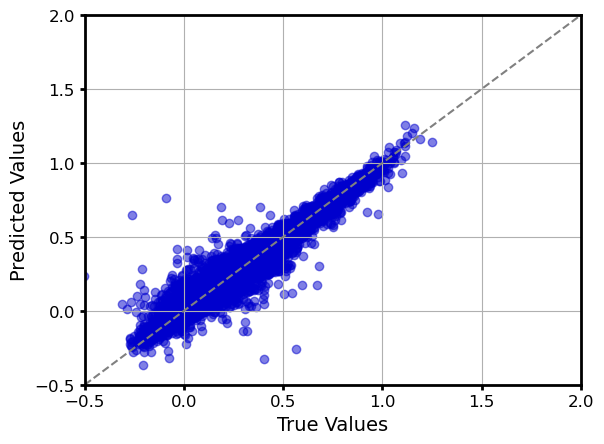

In [15]:
predvals_tensor, truevals_tensor = get_predictions(test_loader, model)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [16]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.0413
Test MSE = 0.0037
Test RMSE = 0.0608
Test R2 = 0.9322


## Model 2

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn.models import AttentiveFP
import copy

HYBRIDIZATION_TYPES = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]

def one_hot(value, choices):
    return [int(value == choice) for choice in choices]

def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
        *one_hot(atom.GetHybridization(), HYBRIDIZATION_TYPES), # Better to do this way, hybridization is a categorical variable, not a continuous one. One‑hot encoding preserves that structure.
    ]

def bond_features(bond):
    bt = bond.GetBondType()
    stereo = bond.GetStereo()
    return [
        int(bt == Chem.rdchem.BondType.SINGLE),
        int(bt == Chem.rdchem.BondType.DOUBLE),
        int(bt == Chem.rdchem.BondType.TRIPLE),
        int(bt == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
        int(stereo == Chem.rdchem.BondStereo.STEREOZ),
        int(stereo == Chem.rdchem.BondStereo.STEREOE),
    ]

def smiles_to_graph(smiles, y=None):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        raise ValueError(f'Invalid SMILES: {smiles}')

    x = torch.tensor([atom_features(atom) for atom in mol.GetAtoms()], dtype=torch.float32)

    edge_indices = []
    edge_attrs = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        bf = bond_features(bond)
        edge_indices.append([i, j])
        edge_indices.append([j, i])
        edge_attrs.append(bf)
        edge_attrs.append(bf)

    if edge_indices:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float32)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 8), dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, smiles=str(smiles))
    if y is not None:
        data.y = torch.tensor([float(y)], dtype=torch.float32)
    return data

class MolGraphDataset(Dataset):
    def __init__(self, smiles_list, y_list):
        super().__init__()
        assert len(smiles_list) == len(y_list), 'The lengths of smiles and y values are not equal!'
        self.graphs = [smiles_to_graph(smiles, y) for smiles, y in zip(smiles_list, y_list)]

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]

class AttentiveGraphRegressor(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_channels, num_layers, num_timesteps, dropout):
        super().__init__()
        self.model = AttentiveFP(
            in_channels=node_feat_dim,
            hidden_channels=hidden_channels,
            out_channels=1,
            edge_dim=edge_feat_dim,
            num_layers=num_layers,
            num_timesteps=num_timesteps,
            dropout=dropout,
        )

    def forward(self, data):
        return self.model(data.x, data.edge_index, data.edge_attr, data.batch).view(-1)

def train_epoch_model2(model, train_loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    n = 0

    for batch in train_loader:
        batch = batch.to(device)
        pred = model(batch)
        y = batch.y.view(-1)
        loss = loss_fn(pred, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_size = y.numel()
        total_loss += loss.item() * batch_size
        n += batch_size

    return total_loss / max(n, 1)

def eval_model2(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    n = 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            y = batch.y.view(-1)
            loss = loss_fn(pred, y)

            batch_size = y.numel()
            total_loss += loss.item() * batch_size
            n += batch_size

    return total_loss / max(n, 1)

@torch.no_grad()
def get_graph_predictions(loader, model, device='cpu'):
    model.eval()
    y_true = []
    y_pred = []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)
        y_true.append(batch.y.view(-1).detach().cpu().numpy())
        y_pred.append(pred.detach().cpu().numpy())

    truevals = np.concatenate(y_true)
    predvals = np.concatenate(y_pred)
    print(f'Shape of pred array: {predvals.shape}')
    print(f'Shape of true array: {truevals.shape}')
    return predvals, truevals

def fit_model2_with_early_stopping(model, train_loader, val_loader, optimizer, loss_fn, device, num_epochs, patience, min_delta=0.0):
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        tr_loss = train_epoch_model2(model, train_loader, optimizer, loss_fn, device)
        val_loss = eval_model2(model, val_loader, loss_fn, device)
        print(f'Epoch {epoch}: train_loss={tr_loss:.4f}, val_loss={val_loss:.4f}')

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f'Early stopping triggered at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    return best_val_loss


### Hyperparameter Optimization

In [ ]:
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split
import copy
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

def objective(trial):

    # Define the hyperparameter search space
    params = {
        'batch_size': trial.suggest_categorical('batch_size', [16, 32, 64]),
        'hidden_channels': trial.suggest_categorical('hidden_channels', [64, 128, 256, 384]),
        'num_layers': trial.suggest_categorical('num_layers', [2, 3, 4]),
        'num_timesteps': trial.suggest_categorical('num_timesteps', [2, 3, 4]),
        'dropout': trial.suggest_categorical('dropout', [0.0, 0.05, 0.1, 0.2]),
        'lr': trial.suggest_float('lr', 1e-5, 1e-3, log=True),
        'weight_decay': trial.suggest_float('weight_decay', 1e-8, 1e-3, log=True),
    }
    num_epochs = 45

    # set up dataloaders and the model
    dataset = MolGraphDataset(train_cv_smiles, train_cv_stg)
    node_feat_dim = dataset[0].x.shape[1]
    edge_feat_dim = dataset[0].edge_attr.shape[1]

    generator = torch.Generator().manual_seed(seed + trial.number)
    train_data, eval_data = random_split(dataset, [0.8, 0.2], generator=generator) # internal validation

    train_loader = PyGDataLoader(train_data, batch_size=params['batch_size'], shuffle=True, pin_memory=True)
    eval_loader = PyGDataLoader(eval_data, batch_size=params['batch_size'], shuffle=False, pin_memory=True)

    model = AttentiveGraphRegressor(
        node_feat_dim=node_feat_dim,
        edge_feat_dim=edge_feat_dim,
        hidden_channels=params["hidden_channels"],
        num_layers=params["num_layers"],
        num_timesteps=params["num_timesteps"],
        dropout=params["dropout"],
        ).to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])

    best_val_loss = float('inf')
    best_state = None
    patience = 3
    wait = 0
    # train with pruning and early stopping
    for epoch in range(num_epochs):
        train_loss = train_epoch_model2(model, train_loader, optimizer, loss_fn, device)
        val_loss = eval_model2(model, eval_loader, loss_fn, device)
        print(f'Trial {trial.number}, epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        trial.report(val_loss, step=epoch)
        if trial.should_prune():
            print(f'Trial {trial.number} pruned at epoch {epoch}')
            raise optuna.TrialPruned()

        if wait >= patience:
            print(f'Trial {trial.number} early-stopped at epoch {epoch}')
            break

    torch.save(best_state, f"model2_trial_{trial.number}.pt")
    return best_val_loss

# Create and run the study
pruner = optuna.pruners.PercentilePruner(
    percentile=40,             # prune only bottom 40%
    n_startup_trials=10,       # first 10 trials never pruned
    n_warmup_steps=8,          # no pruning before epoch 8
    interval_steps=1)
study = optuna.create_study(direction="minimize", pruner=pruner)
study.optimize(objective, n_trials=45)

print('Best trial:')
print(study.best_trial.params)

# save results
with open("Model2_optparams.json", 'w') as f:
    json.dump(study.best_trial.params, f, indent=2)


### 5x5 CV

In [ ]:
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from torch.utils.data import Subset
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'running on {device}')

#-----------------------
# load the optimized parameters
#-----------------------

with open("Model2_optparams.json", 'r') as f:
    optparams = json.load(f)
print(f'Optimized parameters loaded: {optparams}')

batch_size = optparams['batch_size']
hidden_channels = optparams['hidden_channels']
num_layers = optparams['num_layers']
num_timesteps = optparams['num_timesteps']
dropout = optparams['dropout']
lr = optparams['lr']
weight_decay = optparams['weight_decay']
num_epochs = 45

dataset = MolGraphDataset(train_cv_smiles, train_cv_stg)
node_feat_dim = dataset[0].x.shape[1]
edge_feat_dim = dataset[0].edge_attr.shape[1]
loss_fn = nn.MSELoss()

#-----------------------
# do the 5x5 CV
#-----------------------

train_mae_list = []
train_mse_list = []
train_rmse_list = []
train_r2_list = []

val_mae_list = []
val_mse_list = []
val_rmse_list = []
val_r2_list = []

patience = 3
min_delta = 0.0
for fold, (train_idx, val_idx) in enumerate(rkf.split(dataset)):
    train_ds = Subset(dataset, train_idx)
    val_ds = Subset(dataset, val_idx)

    train_loader = PyGDataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = PyGDataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

    model = AttentiveGraphRegressor(
        node_feat_dim=node_feat_dim,
        edge_feat_dim=edge_feat_dim,
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        num_timesteps=num_timesteps,
        dropout=dropout,
        ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    fit_model2_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        num_epochs=num_epochs,
        patience=patience,
        min_delta=min_delta,
    )

    # ---- Compute sklearn metrics for this fold ----
    # Collect predictions for train set
    y_train_pred, y_train_true = get_graph_predictions(train_loader, model, device)
    # y_train_true = y_train_true_.detach().cpu().numpy()
    # y_train_pred = y_train_pred_.detach().cpu().numpy()

    # Collect predictions for val set
    y_val_pred, y_val_true = get_graph_predictions(val_loader, model, device)
    # y_val_true = y_val_true_.detach().cpu().numpy()
    # y_val_pred = y_val_pred_.detach().cpu().numpy()

    # Train metrics
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_mse = mean_squared_error(y_train_true, y_train_pred)
    train_rmse = root_mean_squared_error(y_train_true, y_train_pred)
    train_r2 = r2_score(y_train_true, y_train_pred)

    # Val metrics
    val_mae = mean_absolute_error(y_val_true, y_val_pred)
    val_mse = mean_squared_error(y_val_true, y_val_pred)
    val_rmse = root_mean_squared_error(y_val_true, y_val_pred)
    val_r2 = r2_score(y_val_true, y_val_pred)

    # Store metrics
    train_mae_list.append(train_mae)
    train_mse_list.append(train_mse)
    train_rmse_list.append(train_rmse)
    train_r2_list.append(train_r2)

    val_mae_list.append(val_mae)
    val_mse_list.append(val_mse)
    val_rmse_list.append(val_rmse)
    val_r2_list.append(val_r2)

    print("------------------------")
    print(f"Fold {fold} finished:")
    print(f"Train: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R2={train_r2:.4f}")
    print(f"Val:   MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R2={val_r2:.4f}")
    print("------------------------")

#-----------------------
# save results
#-----------------------

cv_df_tr = pd.DataFrame({"subset": "train", "mae": train_mae_list, "mse": train_mse_list, "rmse": train_rmse_list, "R2": train_r2_list})
cv_df_val = pd.DataFrame({"subset": "valid", "mae": val_mae_list, "mse": val_mse_list, "rmse": val_rmse_list, "R2": val_r2_list})
cv_df = pd.concat([cv_df_tr, cv_df_val], ignore_index=True)
cv_df.to_csv("model2_5x5CV.csv")

### One‑Shot Evaluation

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def truepred_plotter(predvals, truevals):
    ax_min = -0.5
    ax_max = 2.
    fig = plt.figure()
    plt.scatter(truevals, predvals, color='mediumblue', alpha=0.5, marker="o")
    plt.plot([ax_min, ax_max], [ax_min, ax_max], color='gray', linestyle='--')
    plt.xlabel('True Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.xlim(ax_min, ax_max)
    plt.ylim(ax_min, ax_max)
    for ax in fig.axes:
        ax.tick_params(width=2, labelsize=12)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    plt.grid()
    plt.show()

#### Hold-Out Test Set

In [20]:
import json

#-----------------------
# load the optimized parameters
#-----------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'running on {device}')

with open("Model2_optparams.json", 'r') as f:
    optparams = json.load(f)
print(f'Optimized parameters loaded: {optparams}')

batch_size = optparams['batch_size']
hidden_channels = optparams['hidden_channels']
num_layers = optparams['num_layers']
num_timesteps = optparams['num_timesteps']
dropout = optparams['dropout']

test_smiles = test_df['SMILES'].values
test_stg = test_df['dE(S1-T1)'].values
test_ds = MolGraphDataset(test_smiles, test_stg)

node_feat_dim = test_ds[0].x.shape[1]
edge_feat_dim = test_ds[0].edge_attr.shape[1]

test_loader = PyGDataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

# model = make_model2_from_params(optparams, node_feat_dim, edge_feat_dim, device)
model = AttentiveGraphRegressor(
    node_feat_dim=node_feat_dim,
    edge_feat_dim=edge_feat_dim,
    hidden_channels=hidden_channels,
    num_layers=num_layers,
    num_timesteps=num_timesteps,
    dropout=dropout,
).to(device)

model.load_state_dict(torch.load("model2_trial_2.pt", map_location=device))

running on cpu
Optimized parameters loaded: {'batch_size': 64, 'hidden_channels': 384, 'num_layers': 4, 'num_timesteps': 2, 'dropout': 0.0, 'lr': 0.0002309837412562226, 'weight_decay': 0.00029659622749499473}


<All keys matched successfully>

c:\Users\feher\miniconda3\envs\ml_env_cpu\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape of pred array: (13739,)
Shape of true array: (13739,)


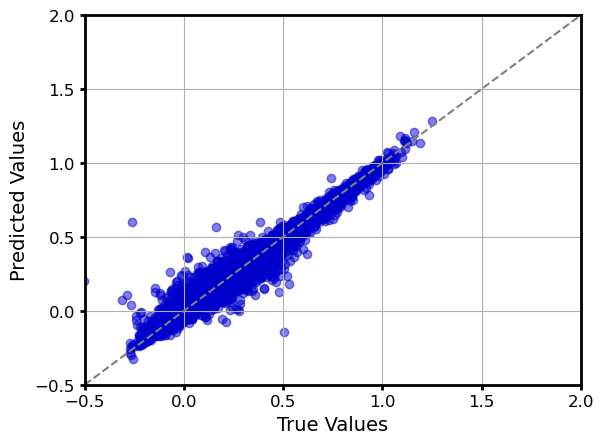

In [21]:
predvals, truevals = get_graph_predictions(test_loader, model, device)
truepred_plotter(predvals, truevals)

In [22]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.0312
Test MSE = 0.0021
Test RMSE = 0.046
Test R2 = 0.9612


In [23]:
oneshot_results = pd.DataFrame({"model": "model_2", "truevals": truevals, "predvals": predvals})
oneshot_results.to_csv("model2_oneshot.csv")

#### External Test Set

In [20]:
import json
import pandas as pd
from rdkit import Chem

def canonicalize(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")
    return Chem.MolToSmiles(mol, canonical=True)

#-----------------------
# load the optimized parameters
#-----------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'running on {device}')

with open("Model2_optparams.json", 'r') as f:
    optparams = json.load(f)
print(f'Optimized parameters loaded: {optparams}')

batch_size = optparams['batch_size']
hidden_channels = optparams['hidden_channels']
num_layers = optparams['num_layers']
num_timesteps = optparams['num_timesteps']
dropout = optparams['dropout']

# external_a = pd.read_csv("extrapolation_data_1.txt")
external_a = pd.read_csv("extrapolation_data_2.txt")
external_a["canon_SMILES"] = [canonicalize(s) for s in external_a["SMILES"].values]
test_smiles = external_a["canon_SMILES"].values
test_stg = external_a["STG"].values
test_ds = MolGraphDataset(test_smiles, test_stg)

node_feat_dim = test_ds[0].x.shape[1]
edge_feat_dim = test_ds[0].edge_attr.shape[1]

test_loader = PyGDataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

# model = make_model2_from_params(optparams, node_feat_dim, edge_feat_dim, device)
model = AttentiveGraphRegressor(
    node_feat_dim=node_feat_dim,
    edge_feat_dim=edge_feat_dim,
    hidden_channels=hidden_channels,
    num_layers=num_layers,
    num_timesteps=num_timesteps,
    dropout=dropout,
).to(device)

model.load_state_dict(torch.load("model2_trial_2.pt", map_location=device))

running on cuda
Optimized parameters loaded: {'batch_size': 64, 'hidden_channels': 384, 'num_layers': 4, 'num_timesteps': 2, 'dropout': 0.0, 'lr': 0.0002309837412562226, 'weight_decay': 0.00029659622749499473}


<All keys matched successfully>

Shape of pred array: (59,)
Shape of true array: (59,)


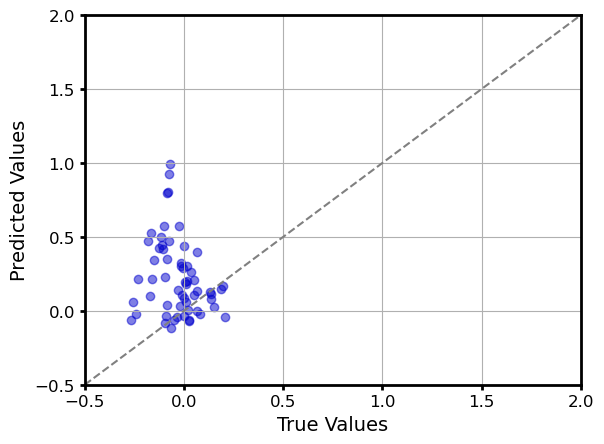

In [21]:
predvals, truevals = get_graph_predictions(test_loader, model, device)
truepred_plotter(predvals, truevals)

In [22]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.2891
Test MSE = 0.1557
Test RMSE = 0.3946
Test R2 = -12.1908


In [3]:
import json
import pandas as pd

#-----------------------
# load the optimized parameters
#-----------------------

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'running on {device}')

with open("Model2_optparams.json", 'r') as f:
    optparams = json.load(f)
print(f'Optimized parameters loaded: {optparams}')

batch_size = optparams['batch_size']
hidden_channels = optparams['hidden_channels']
num_layers = optparams['num_layers']
num_timesteps = optparams['num_timesteps']
dropout = optparams['dropout']

# external_a = pd.read_csv("extrapolation_data_1.txt")
external_a = pd.read_csv("extrapolation_data_2.txt")
test_smiles = external_a["SMILES"].values
test_stg = external_a["STG"].values
test_ds = MolGraphDataset(test_smiles, test_stg)

node_feat_dim = test_ds[0].x.shape[1]
edge_feat_dim = test_ds[0].edge_attr.shape[1]

test_loader = PyGDataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

# model = make_model2_from_params(optparams, node_feat_dim, edge_feat_dim, device)
model = AttentiveGraphRegressor(
    node_feat_dim=node_feat_dim,
    edge_feat_dim=edge_feat_dim,
    hidden_channels=hidden_channels,
    num_layers=num_layers,
    num_timesteps=num_timesteps,
    dropout=dropout,
).to(device)

model.load_state_dict(torch.load("model2_trial_2.pt", map_location=device))

running on cpu
Optimized parameters loaded: {'batch_size': 64, 'hidden_channels': 384, 'num_layers': 4, 'num_timesteps': 2, 'dropout': 0.0, 'lr': 0.0002309837412562226, 'weight_decay': 0.00029659622749499473}


<All keys matched successfully>

Shape of pred array: (59,)
Shape of true array: (59,)


c:\Users\feher\miniconda3\envs\ml_env_cpu\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


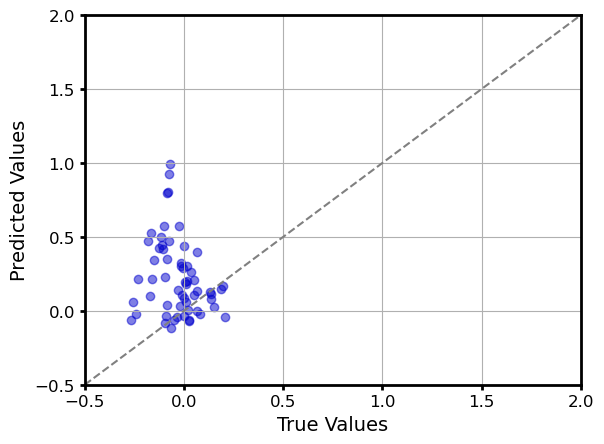

In [6]:
predvals, truevals = get_graph_predictions(test_loader, model, device)
truepred_plotter(predvals, truevals)

In [7]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.2891
Test MSE = 0.1557
Test RMSE = 0.3946
Test R2 = -12.1908


In [8]:
oneshot_results = pd.DataFrame({"model": "model_2", "truevals": truevals, "predvals": predvals})
oneshot_results.to_csv("model2_external.csv")

### Single SMILES Prediction

In [10]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import matplotlib.pyplot as plt

def canonicalize(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")
    return Chem.MolToSmiles(mol, canonical=True)

In [20]:
cyclazine = "C1=CC=C2C=CC=C3C=CC=C1N23"
heptazine = "N1=CN=C2N=CN=C3N=CN=C1N23"
mol_1 = "Nc1ccc2c(N)c3c(N)cc(N)c3c(N)c2cc1"
mol_2 = "C1C=CC=C1"
canon_mol = canonicalize(mol_2)
dta = smiles_to_graph(canon_mol)

print(dta)
print(dta.x.shape[1])
print(dta.edge_attr.shape[1])

node_feat_dim = dta.x.shape[1]
edge_feat_dim = dta.edge_attr.shape[1]

Data(x=[5, 10], edge_index=[2, 10], edge_attr=[10, 8], smiles='C1=CCC=C1')
10
8


In [21]:
import json
import pandas as pd

#-----------------------
# load the optimized parameters
#-----------------------

with open("Model2_optparams.json", 'r') as f:
    optparams = json.load(f)
print(f'Optimized parameters loaded: {optparams}')

hidden_channels = optparams['hidden_channels']
num_layers = optparams['num_layers']
num_timesteps = optparams['num_timesteps']
dropout = optparams['dropout']

# model = make_model2_from_params(optparams, node_feat_dim, edge_feat_dim, device)
model = AttentiveGraphRegressor(
    node_feat_dim=node_feat_dim,
    edge_feat_dim=edge_feat_dim,
    hidden_channels=hidden_channels,
    num_layers=num_layers,
    num_timesteps=num_timesteps,
    dropout=dropout)

model.load_state_dict(torch.load("model2_trial_2.pt"))
model.eval()

Optimized parameters loaded: {'batch_size': 64, 'hidden_channels': 384, 'num_layers': 4, 'num_timesteps': 2, 'dropout': 0.0, 'lr': 0.0002309837412562226, 'weight_decay': 0.00029659622749499473}


AttentiveGraphRegressor(
  (model): AttentiveFP(in_channels=10, hidden_channels=384, out_channels=1, edge_dim=8, num_layers=4, num_timesteps=2)
)

In [22]:
from torch_geometric.data import Batch

with torch.no_grad():
    batch = Batch.from_data_list([dta])
    pred = model(batch)

prediction = pred.detach().cpu().numpy()
prediction = round(prediction.item(), 3)
prediction = f"{prediction} eV"
print(f"prediction: {prediction}")

prediction: 1.728 eV


## Model 3

In [ ]:
#-----------------------
# train the tokenizer
#
# - we train it on the initial 80% test+CV data, it will not see the test set 
# - we save it here at the model definition and reuse for the other parts (hparamopt, CV, test-prediciton)
#
#-----------------------

from tokenizers import Tokenizer, models, trainers, pre_tokenizers # conda install -c conda-forge tokenizers

# Define a regex pattern for SMILES tokens
smiles_pattern = r"Cl?|Br?|[A-Z][a-z]?|\d|=|#|\(|\)|\.|\[.*?\]|."

# Initialize tokenizer
tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.Split(smiles_pattern, behavior="isolated")

# Set up trainer
trainer = trainers.BpeTrainer(vocab_size=512, special_tokens=["[PAD]", "[UNK]"])

# Train from in-memory list
tokenizer.train_from_iterator(train_cv_smiles, trainer=trainer)

# Save tokenizer
tokenizer.save("model3_smiles-tokenizer.json")

In [24]:
#-----------------------
# define the model
#-----------------------

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset
from math import log
from tokenizers import Tokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SinusoidalPositionalEncoding(nn.Module): # absolute, fixed, faster
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.size(1)]

class PositionalEncoding(nn.Module): # absolute, learnable (chemBERTa style)
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)  # shape: (1, seq_len)
        pos_embed = self.pos_embedding(positions)  # shape: (1, seq_len, d_model)
        return x + pos_embed

class stgDataset(Dataset): # no padding, dynamic padding will be added later via the collate function
    def __init__(self, smiles, stg, tokenizer, max_length=64):
        super().__init__()
        assert len(smiles) == len(stg), "The lengths of smiles and stg are not equal!"
        self.smiles = smiles
        self.stg = torch.tensor(stg, dtype=torch.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.smiles)
    
    def __getitem__(self, idx):
        s = self.smiles[idx]
        enc = self.tokenizer.encode(s)
        ids = enc.ids
        
        # 1. TRUNCATION ONLY (Hard cap at max_length)
        if len(ids) > self.max_length:
            ids = ids[:self.max_length]
            
        # Attention mask is just 1s for real tokens right now
        attn = [1] * len(ids)
        
        # Return raw, variable-length python lists
        return {"input_ids": ids, "attention_mask": attn, "target": self.stg[idx]}

class FastDataCollator:
    def __init__(self, pad_id):
        self.pad_id = pad_id

    def __call__(self, batch):
        # 1. Convert lists to tensors immediately
        input_ids = [torch.tensor(item["input_ids"], dtype=torch.long) for item in batch]
        attn_masks = [torch.tensor(item["attention_mask"], dtype=torch.long) for item in batch]
        targets = [item["target"] for item in batch]
        
        # 2. Use PyTorch's native C++ utility to dynamically pad the tensors
        padded_ids = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=self.pad_id)
        
        # 3. Do the same for attention masks (padding value is 0)
        padded_attn = torch.nn.utils.rnn.pad_sequence(attn_masks, batch_first=True, padding_value=0)
        
        return {"input_ids": padded_ids, "attention_mask": padded_attn, "target": torch.stack(targets)}

class SMILESTransformerRegressor(nn.Module):
    def __init__(
        self,
        vocab_size,
        pad_token_id,
        max_len=256,
        embed_dim=128,
        nhead=8,
        num_layers=3,
        dropout=0.1,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.max_len = max_len
        self.ff_dim = 4 * self.embed_dim # 4x expansion in the transformer encoder ("canonical" transformer ratio)
        self.token_embed = nn.Embedding(vocab_size, self.embed_dim, padding_idx=pad_token_id)
        # self.pos_embed = PositionalEncoding(max_len, embed_dim) # better for natural language
        self.pos_embed = SinusoidalPositionalEncoding(self.embed_dim, self.max_len) # better for chemistry (SMILES) if dataset is small/medium
        encoder_layer = nn.TransformerEncoderLayer(d_model=self.embed_dim, nhead=nhead, dim_feedforward=self.ff_dim, dropout=dropout, batch_first=True, activation="gelu") # does only support relu (default) or gelu, the gelu implementation is very slow
        # encoder_layer = nn.TransformerEncoderLayer(d_model=self.embed_dim, nhead=nhead, dim_feedforward=self.ff_dim, dropout=dropout, batch_first=True, activation=F.silu) # F.silu is also very slow because this (i.e., not using "relu" or "gelu") turns off nested tensor optimization
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        # encoder_layer.activation = nn.SiLU() # hack around nested tensor optimization, might not be safe
        # regression head
        self.head = nn.Sequential(
            nn.LayerNorm(self.embed_dim), 
            nn.Linear(self.embed_dim, self.embed_dim * 2), # 2x expansion in the regression head
            nn.SiLU(),
            nn.Linear(self.embed_dim * 2, 1), # dropout not recommended for a head this small
        )

    def forward(self, input_ids, attention_mask):
        # input_ids: (batch, seq_len), attention_mask: (batch, seq_len) with 1 for real tokens
        batch_size, seq_len = input_ids.shape
        if seq_len > self.max_len:
            raise ValueError("seq_len > max_len")

        x = self.token_embed(input_ids)
        x = self.pos_embed(x)

        # src_key_padding_mask: True where tokens are PAD (to be ignored)
        src_key_padding_mask = attention_mask == 0  # (batch, seq_len) bool

        x = self.encoder(x, src_key_padding_mask=src_key_padding_mask)  # (batch, seq_len, embed_dim)

        # Masked mean pooling (ignore PAD tokens)
        mask = attention_mask.unsqueeze(-1).type_as(x)  # (batch, seq_len, 1)
        summed = (x * mask).sum(dim=1)                 # (batch, embed_dim)
        counts = mask.sum(dim=1).clamp(min=1e-9)        # (batch, 1)
        pooled = summed / counts                       # (batch, embed_dim)

        out = self.head(pooled).squeeze(-1)             # (batch,)
        return out

def train_epoch(model, dataloader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["target"].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask)
        loss = loss_fn(preds, targets)
        loss.backward()
        optimizer.step()
        scheduler.step() # must come after optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
    return total_loss / len(dataloader.dataset)

def eval_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["target"].to(device)

            preds = model(input_ids, attention_mask)
            loss = loss_fn(preds, targets)
            total_loss += loss.item() * input_ids.size(0)
    return total_loss / len(dataloader.dataset)

def get_predictions(dtaloader, model, device="cpu"): 
    N = 0
    with torch.no_grad():
        for batch in dtaloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["target"].to(device)
            if N == 0:
                predvals = model(input_ids, attention_mask)
                truevals = targets
                N = 1
            else:
                predvals = torch.cat((predvals, model(input_ids, attention_mask)), 0)
                truevals = torch.cat((truevals, targets), 0)
    print(f"Shape of pred tensor: {predvals.shape}")
    print(f"Shape of true tensor: {truevals.shape}")
    return predvals, truevals

# transformers trained from scratch benefit a lot from warmup
def get_linear_warmup_cosine_decay(warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        # cosine decay
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + torch.cos(torch.tensor(progress * 3.1415926535)))
    return lr_lambda

### Hyperparameter Optimization

What **do not** tune:

- `max_len` → we set it to equal to the length of the longest SMILES in the dataset (64)
- `vocab_size` → we do not re-train the tokenizer
- `dropout` → only used inside the encoder

In [ ]:
import optuna
import json
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

# Load tokenizer (pre-trained for this dataset)
tokenizer = Tokenizer.from_file("model3_smiles-tokenizer.json")
pad_id = tokenizer.token_to_id("[PAD]")
if pad_id is None:
    raise ValueError("Tokenizer must have [PAD] token defined")
data_collator = FastDataCollator(pad_id=pad_id)

def objective(trial):

    # -------------------------
    # Parameters
    # -------------------------
    max_len = 64 # the longest SMILES is 64 characters long in the complete dataset
    vocab_size = len(tokenizer.get_vocab()) # get the vocab size from the tokenizer (assumes tokenizer is from the tokenizer library)
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    embed_dim = trial.suggest_categorical("embed_dim", [128, 256, 384]) # aim to be simpler/smaller than chemBERTa
    nhead = trial.suggest_categorical("nhead", [4, 8]) # embed_dim must be divisible by nhead
    num_layers = trial.suggest_int("num_layers", 2, 5)
    lr = trial.suggest_float("lr", 5e-6, 3e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 5e-2, log=True)
    num_epochs = 50 # from‑scratch models are expected to converge slower than the fine-tuning of ChemBERTa
    # -------------------------
    # Data
    # -------------------------
    dataset = stgDataset(train_cv_smiles, train_cv_stg, tokenizer, max_length=max_len)
    train_data, test_data = random_split(dataset, [0.8, 0.2])
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=data_collator, pin_memory=True)
    eval_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True)
    # -------------------------
    # Model
    # -------------------------
    model = SMILESTransformerRegressor(vocab_size=vocab_size,
                                       pad_token_id=pad_id,
                                       max_len=max_len,
                                       embed_dim=embed_dim,
                                       nhead=nhead,
                                       num_layers=num_layers,
                                       dropout=dropout).to(device)
    # -------------------------
    # Optimizer (two‑group AdamW parameter setup)
    # -------------------------
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    # -------------------------
    # Warmup + cosine decay
    # -------------------------
    total_steps = 5000
    warmup_steps = int(0.05 * total_steps)  # 5% warmup, the ratio itself does not need heavy tuning
    scheduler = LambdaLR(optimizer, lr_lambda=get_linear_warmup_cosine_decay(warmup_steps, total_steps))
    # -------------------------
    # Train loop with pruning and early stopping
    # -------------------------
    best_val_loss = float("inf")
    best_state = None
    patience = 3
    wait = 0
    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, loss_fn, device)
        val_loss = eval_epoch(model, eval_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
        
        # Track best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if trial.should_prune():
            print(f"Trial {trial.number} pruned at epoch {epoch}")
            raise optuna.TrialPruned()

        # Early stopping
        if wait >= patience:
            print(f"Trial {trial.number} early-stopped at epoch {epoch}")
            break
        trial.report(val_loss, step=epoch)

    torch.save(best_state, f"model3_trial_{trial.number}.pt")
    return best_val_loss

# Create and run the study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial.params)

# save results
with open("Model3_optparams.json", "w") as f:
    json.dump(study.best_trial.params, f)

### 5x5 CV

In [ ]:
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from torch.utils.data import Subset

#-----------------------
# load the tokenizer
#-----------------------

tokenizer = Tokenizer.from_file("model3_smiles-tokenizer.json")
pad_id = tokenizer.token_to_id("[PAD]")
if pad_id is None:
    raise ValueError("Tokenizer must have [PAD] token defined")
data_collator = FastDataCollator(pad_id=pad_id)

#-----------------------
# load the optimized parameters
#-----------------------

with open("Model3_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

max_len = 64
dropout = optparams["dropout"]
vocab_size = len(tokenizer.get_vocab())
batch_size = optparams["batch_size"]
embed_dim = optparams["embed_dim"]
nhead = optparams["nhead"]
num_layers = optparams["num_layers"]
lr = optparams["lr"]
weight_decay = optparams["weight_decay"]
num_epochs = 50

dataset = stgDataset(train_cv_smiles, train_cv_stg, tokenizer, max_length=max_len)
loss_fn = nn.MSELoss()

#-----------------------
# do the 5x5 CV
#-----------------------

train_mae_list = []
train_mse_list = []
train_rmse_list = []
train_r2_list = []

val_mae_list = []
val_mse_list = []
val_rmse_list = []
val_r2_list = []

patience = 3  # how many epochs to wait for improvement, good practice is to set it slightly higher than in optuna
min_delta = 0.0  # minimum improvement to reset patience
for fold, (train_idx, val_idx) in enumerate(rkf.split(dataset)):
    train_ds = Subset(dataset, train_idx)
    val_ds   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=data_collator, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True)

    # model
    model = SMILESTransformerRegressor(vocab_size=vocab_size,
                                       pad_token_id=pad_id,
                                       max_len=max_len,
                                       embed_dim=embed_dim,
                                       nhead=nhead,
                                       num_layers=num_layers,
                                       dropout=dropout).to(device)
    
    # optimizer
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr, weight_decay=weight_decay)

    # warmup
    total_steps = 5000
    warmup_steps = int(0.05 * total_steps)  # 5% warmup, the ratio itself does not need heavy tuning
    scheduler = LambdaLR(optimizer, lr_lambda=get_linear_warmup_cosine_decay(warmup_steps, total_steps))

    best_val_loss = float("inf")
    patience_counter = 0
    for epoch in range(num_epochs):
        tr_loss = train_epoch(model, train_loader, optimizer, scheduler, loss_fn, device)
        tst_loss = eval_epoch(model, val_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f}, val_loss={tst_loss:.4f}")

        # --- EARLY STOPPING LOGIC ---
        if tst_loss < best_val_loss - min_delta:
            best_val_loss = tst_loss
            patience_counter = 0
            best_state = model.state_dict()  # save best model for this fold
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break
    
    # restore best model for this fold
    model.load_state_dict(best_state)

    # ---- Compute sklearn metrics for this fold ----
    # Collect predictions for train set
    y_train_pred_, y_train_true_ = get_predictions(train_loader, model, device)
    y_train_true = y_train_true_.detach().cpu().numpy()
    y_train_pred = y_train_pred_.detach().cpu().numpy()

    # Collect predictions for val set
    y_val_pred_, y_val_true_ = get_predictions(val_loader, model, device)
    y_val_true = y_val_true_.detach().cpu().numpy()
    y_val_pred = y_val_pred_.detach().cpu().numpy()

    # Train metrics
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_mse = mean_squared_error(y_train_true, y_train_pred)
    train_rmse = root_mean_squared_error(y_train_true, y_train_pred)
    train_r2 = r2_score(y_train_true, y_train_pred)

    # Val metrics
    val_mae = mean_absolute_error(y_val_true, y_val_pred)
    val_mse = mean_squared_error(y_val_true, y_val_pred)
    val_rmse = root_mean_squared_error(y_val_true, y_val_pred)
    val_r2 = r2_score(y_val_true, y_val_pred)

    # Store metrics
    train_mae_list.append(train_mae)
    train_mse_list.append(train_mse)
    train_rmse_list.append(train_rmse)
    train_r2_list.append(train_r2)

    val_mae_list.append(val_mae)
    val_mse_list.append(val_mse)
    val_rmse_list.append(val_rmse)
    val_r2_list.append(val_r2)

    print("------------------------")
    print(f"Fold {fold} finished:")
    print(f"Train: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R2={train_r2:.4f}")
    print(f"Val:   MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R2={val_r2:.4f}")
    print("------------------------")

#-----------------------
# save results
#-----------------------

cv_df_tr = pd.DataFrame({"subset": "train", "mae": train_mae_list, "mse": train_mse_list, "rmse": train_rmse_list, "R2": train_r2_list})
cv_df_val = pd.DataFrame({"subset": "valid", "mae": val_mae_list, "mse": val_mse_list, "rmse": val_rmse_list, "R2": val_r2_list})
cv_df = pd.concat([cv_df_tr, cv_df_val], ignore_index=True)
cv_df.to_csv("model3_5x5CV.csv")

### One‑Shot Evaluation

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def get_predictions(dtaloader, model, device="cpu"): 
    N = 0
    with torch.no_grad():
        for batch in dtaloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["target"].to(device)
            if N == 0:
                predvals = model(input_ids, attention_mask)
                truevals = targets
                N = 1
            else:
                predvals = torch.cat((predvals, model(input_ids, attention_mask)), 0)
                truevals = torch.cat((truevals, targets), 0)
    print(f"Shape of pred tensor: {predvals.shape}")
    print(f"Shape of true tensor: {truevals.shape}")
    return predvals, truevals

def truepred_plotter(predvals, truevals):
    ax_min = -0.5
    ax_max = 2.
    fig = plt.figure()
    plt.scatter(truevals, predvals, color='mediumblue', alpha=0.5, marker="o")
    plt.plot([ax_min, ax_max], [ax_min, ax_max], color='gray', linestyle='--')
    plt.xlabel('True Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.xlim(ax_min, ax_max)
    plt.ylim(ax_min, ax_max)
    for ax in fig.axes:
        ax.tick_params(width=2, labelsize=12)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    plt.grid()
    plt.show()

In [26]:
import json

#-----------------------
# load the tokenizer
#-----------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

# Load tokenizer (pre-trained for this dataset)
tokenizer = Tokenizer.from_file("model3_smiles-tokenizer.json")
pad_id = tokenizer.token_to_id("[PAD]")
if pad_id is None:
    raise ValueError("Tokenizer must have [PAD] token defined")
data_collator = FastDataCollator(pad_id=pad_id)

#-----------------------
# load the optimized parameters
#-----------------------

with open("Model3_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

max_len = 64
dropout = optparams["dropout"]
vocab_size = len(tokenizer.get_vocab())
batch_size = optparams["batch_size"]
embed_dim = optparams["embed_dim"]
nhead = optparams["nhead"]
num_layers = optparams["num_layers"]

test_smiles = test_df["SMILES"].values
test_stg = test_df["dE(S1-T1)"].values
test_ds = stgDataset(test_smiles, test_stg, tokenizer, max_length=max_len)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True)

# model
model = SMILESTransformerRegressor(vocab_size=vocab_size,
                                    pad_token_id=pad_id,
                                    max_len=max_len,
                                    embed_dim=embed_dim,
                                    nhead=nhead,
                                    num_layers=num_layers,
                                    dropout=dropout).to(device)
model.load_state_dict(torch.load("model3_trial_24.pt", map_location=device))

running on cpu
Optimized parameters loaded: {'dropout': 0.10970755389576518, 'batch_size': 16, 'embed_dim': 384, 'nhead': 4, 'num_layers': 3, 'lr': 8.275985995761376e-05, 'weight_decay': 1.2975158006302118e-06}


<All keys matched successfully>

c:\Users\feher\miniconda3\envs\ml_env_cpu\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape of pred tensor: torch.Size([13739])
Shape of true tensor: torch.Size([13739])


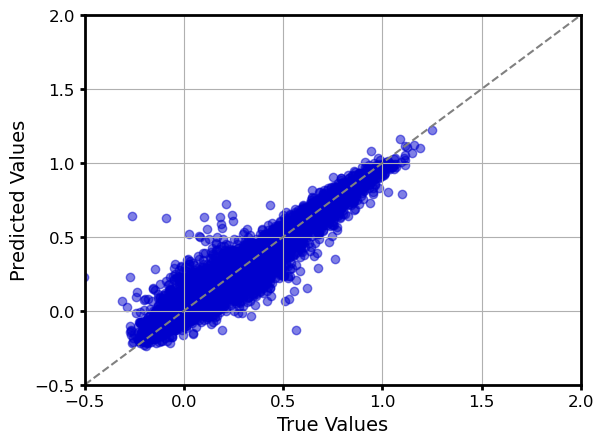

In [27]:
predvals_tensor, truevals_tensor = get_predictions(test_loader, model, device)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [28]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.0491
Test MSE = 0.0049
Test RMSE = 0.0702
Test R2 = 0.9098


In [29]:
oneshot_results = pd.DataFrame({"model": "model_3", "truevals": truevals, "predvals": predvals})
oneshot_results.to_csv("model3_oneshot.csv")

## Model 4

In [3]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset
import pandas as pd

tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1", clean_up_tokenization_spaces=False)

class SmilesDataset(Dataset):
    def __init__(self, smiles, labels, tokenizer):
        self.smiles = smiles
        self.labels = labels
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.smiles[idx],
            truncation=False,
            padding=False,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }

    def __len__(self):
        return len(self.smiles)

class predDataset(Dataset):
    def __init__(self, smiles, tokenizer):
        self.smiles = smiles
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.smiles[idx],
            truncation=False,
            padding=False,
            return_tensors="pt"
        )
        return {"input_ids": enc["input_ids"].squeeze(0), "attention_mask": enc["attention_mask"].squeeze(0),}

    def __len__(self):
        return len(self.smiles)

class RegressionHead(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.hs = hidden_size
        self.mlp = nn.Sequential(
            nn.LayerNorm(self.hs),
            nn.Linear(self.hs, self.hs * 2),
            nn.SiLU(),
            nn.Linear(self.hs * 2, 1))

    def forward(self, x):
        return self.mlp(x)

class ChemBERTaRegressor_clspool(nn.Module):
    def __init__(self, freeze_encoder=False):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
        self.hidden_dim = self.encoder.config.hidden_size # 768 for chemBERTa

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.head = RegressionHead(self.hidden_dim)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls = outputs.last_hidden_state[:, 0]  # CLS token = '<s>'
        return self.head(cls)

class ChemBERTaRegressor_meanpool(nn.Module):
    def __init__(self, freeze_encoder=False):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
        self.hidden_dim = self.encoder.config.hidden_size # 768 for chemBERTa

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.head = RegressionHead(self.hidden_dim)

    def mean_pool(self, hidden_states, attention_mask):
        # attention_mask: [batch, seq]
        # hidden_states:  [batch, seq, hidden]
        
        mask = attention_mask.unsqueeze(-1)          # [batch, seq, 1]
        masked_hidden = hidden_states * mask         # zero out padding
        summed = masked_hidden.sum(dim=1)            # sum over tokens
        counts = mask.sum(dim=1).clamp(min=1e-9)     # avoid division by zero
        return summed / counts                       # mean pooling

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state           # [batch, seq, hidden]
        pooled = self.mean_pool(hidden, attention_mask)  # [batch, hidden]

        return self.head(pooled)

def train_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["labels"].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask).squeeze()
        loss = loss_fn(preds, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
    return total_loss / len(dataloader.dataset)

def eval_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["labels"].to(device)

            preds = model(input_ids, attention_mask).squeeze()
            loss = loss_fn(preds, targets)
            total_loss += loss.item() * input_ids.size(0)
    return total_loss / len(dataloader.dataset)

def get_transformer_predictions(dtaloader, model, device="cpu"): 
    N = 0
    with torch.no_grad():
        for batch in dtaloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["labels"].to(device)
            if N == 0:
                predvals = model(input_ids, attention_mask)
                truevals = targets
                N = 1
            else:
                predvals = torch.cat((predvals, model(input_ids, attention_mask)), 0)
                truevals = torch.cat((truevals, targets), 0)
    print(f"Shape of pred tensor: {predvals.shape}")
    print(f"Shape of true tensor: {truevals.shape}")
    return predvals, truevals


### Hyperparameter Optimization

We only fine-tune chemBERTa so most model parameters are fixed. We do not use `max_len`, instead utilize a built-in Huggingface data collator for dynamic padding.

What **can be** tuned are the gradient-related parameters:

- `batch_size` → controls **gradient noise**, the "use the largest `batch_size` that GPU memory allows" strategy is not recommended for transformers
- learning rate → controls **update magnitude**, most successful ChemBERTa regression papers use `lr=1e‑4`, in our pre-studies `lr=2e-5` looked better
- `max_len` (???)

> The Adam optimizer is highly dependent on the learning rate as weight decay scales with `lr`. LayerNorm and bias terms get over‑regularized, and transformer layers collapse easily. That is why AdamW is recommended as weight decay is independent of `lr`. This makes egularization stay stable at higher `lr`.

In [ ]:
import optuna
import json
import copy
from transformers import DataCollatorWithPadding

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

# Tokenizer loaded in the model definition already
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True) # per-batch dynamic padding

def objective(trial):

    # Parameters to be optimized
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64])
    lr = trial.suggest_float("lr", 5e-6, 3e-4, log=True) # log scale means the upper limit has more focus, going above 3e-4 is not recommended. Tested with 1e-3, failed horribly.
    num_epochs = 25

    # Set up the dataloaders using dataset and tokenizer
    dataset = SmilesDataset(train_cv_smiles, train_cv_stg, tokenizer)
    train_data, test_data = random_split(dataset, [0.8, 0.2])
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=data_collator, pin_memory=True)
    eval_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True) # Shuffling validation/test data has no benefit and can make debugging harder.

    # Model
    model = ChemBERTaRegressor_meanpool(freeze_encoder=False).to(device)
    # Optimizer recommended for RoBERTa‑based transformer models
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    patience = 3
    wait = 0
    # train with pruning and early stopping
    for epoch in range(num_epochs):  # Max epochs
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss = eval_epoch(model, eval_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
        
        # Track best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if trial.should_prune():
            print(f"Trial {trial.number} pruned at epoch {epoch}")
            raise optuna.TrialPruned()

        # Early stopping
        if wait >= patience:
            print(f"Trial {trial.number} early-stopped at epoch {epoch}")
            break
        trial.report(val_loss, step=epoch)

    torch.save(best_state, f"model4_trial_{trial.number}.pt")
    return best_val_loss

# Create and run the study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25)

print("Best trial:")
print(study.best_trial.params)

# save results
with open("Model4_optparams.json", "w") as f:
    json.dump(study.best_trial.params, f)

### 5x5 CV

In [ ]:
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from torch.utils.data import Subset
from transformers import DataCollatorWithPadding

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True) # per-batch dynamic padding

#-----------------------
# load the optimized parameters
#-----------------------

with open("Model4_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
lr = optparams["lr"]
num_epochs = 25

dataset = SmilesDataset(train_cv_smiles, train_cv_stg, tokenizer)
loss_fn = nn.MSELoss()

#-----------------------
# do the 5x5 CV
#-----------------------

train_mae_list = []
train_mse_list = []
train_rmse_list = []
train_r2_list = []

val_mae_list = []
val_mse_list = []
val_rmse_list = []
val_r2_list = []

patience = 3  # how many epochs to wait for improvement, good practice is to set it slightly higher than in optuna
min_delta = 0.0  # minimum improvement to reset patience

for fold, (train_idx, val_idx) in enumerate(rkf.split(dataset)):
    train_ds = Subset(dataset, train_idx)
    val_ds   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=data_collator, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True)

    model = ChemBERTaRegressor_meanpool(freeze_encoder=False).to(device)
    # Optimizer recommended for RoBERTa‑based transformer models
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr)

    best_val_loss = float("inf")
    patience_counter = 0
    for epoch in range(num_epochs):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        tst_loss = eval_epoch(model, val_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f}, val_loss={tst_loss:.4f}")

        # --- EARLY STOPPING LOGIC ---
        if tst_loss < best_val_loss - min_delta:
            best_val_loss = tst_loss
            patience_counter = 0
            best_state = model.state_dict()  # save best model for this fold
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break
    
    # restore best model for this fold
    model.load_state_dict(best_state)

    # ---- Compute sklearn metrics for this fold ----
    # Collect predictions for train set
    y_train_pred_, y_train_true_ = get_transformer_predictions(train_loader, model, device)
    y_train_true = y_train_true_.detach().cpu().numpy()
    y_train_pred = y_train_pred_.detach().cpu().numpy()

    # Collect predictions for val set
    y_val_pred_, y_val_true_ = get_transformer_predictions(val_loader, model, device)
    y_val_true = y_val_true_.detach().cpu().numpy()
    y_val_pred = y_val_pred_.detach().cpu().numpy()

    # Train metrics
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_mse = mean_squared_error(y_train_true, y_train_pred)
    train_rmse = root_mean_squared_error(y_train_true, y_train_pred)
    train_r2 = r2_score(y_train_true, y_train_pred)

    # Val metrics
    val_mae = mean_absolute_error(y_val_true, y_val_pred)
    val_mse = mean_squared_error(y_val_true, y_val_pred)
    val_rmse = root_mean_squared_error(y_val_true, y_val_pred)
    val_r2 = r2_score(y_val_true, y_val_pred)

    # Store metrics
    train_mae_list.append(train_mae)
    train_mse_list.append(train_mse)
    train_rmse_list.append(train_rmse)
    train_r2_list.append(train_r2)

    val_mae_list.append(val_mae)
    val_mse_list.append(val_mse)
    val_rmse_list.append(val_rmse)
    val_r2_list.append(val_r2)

    print("------------------------")
    print(f"Fold {fold} finished:")
    print(f"Train: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R2={train_r2:.4f}")
    print(f"Val:   MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R2={val_r2:.4f}")
    print("------------------------")

#-----------------------
# save results
#-----------------------

cv_df_tr = pd.DataFrame({"subset": "train", "mae": train_mae_list, "mse": train_mse_list, "rmse": train_rmse_list, "R2": train_r2_list})
cv_df_val = pd.DataFrame({"subset": "valid", "mae": val_mae_list, "mse": val_mse_list, "rmse": val_rmse_list, "R2": val_r2_list})
cv_df = pd.concat([cv_df_tr, cv_df_val], ignore_index=True)
cv_df.to_csv("model4_5x5CV.csv")

### One‑Shot Evaluation

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def truepred_plotter(predvals, truevals):
    ax_min = -0.5
    ax_max = 2.
    fig = plt.figure()
    plt.scatter(truevals, predvals, color='mediumblue', alpha=0.5, marker="o")
    plt.plot([ax_min, ax_max], [ax_min, ax_max], color='gray', linestyle='--')
    plt.xlabel('True Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.xlim(ax_min, ax_max)
    plt.ylim(ax_min, ax_max)
    for ax in fig.axes:
        ax.tick_params(width=2, labelsize=12)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    plt.grid()
    plt.show()


In [5]:
#-----------------------
# load the optimized parameters
#-----------------------

import json
from transformers import DataCollatorWithPadding

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

with open("Model4_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]

test_smiles = test_df["SMILES"].values
test_stg = test_df["dE(S1-T1)"].values
test_ds = SmilesDataset(test_smiles, test_stg, tokenizer)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True)

#-----------------------
# load model from checkpoint
#-----------------------

model = ChemBERTaRegressor_meanpool(freeze_encoder=False).to(device)
model.load_state_dict(torch.load("model4_trial_4.pt", map_location=device))


running on cuda
Optimized parameters loaded: {'batch_size': 64, 'lr': 6.08490835421604e-05}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

In [7]:
pytorch_total_params = sum(p.numel() for p in model.parameters())
pytorch_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"total number of params: {pytorch_total_params}")
print(f"number of trainable params: {pytorch_trainable_params}")

total number of params: 45288193
number of trainable params: 45288193


c:\Users\feher\miniconda3\envs\ml_env_cpu\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape of pred tensor: torch.Size([13739, 1])
Shape of true tensor: torch.Size([13739])


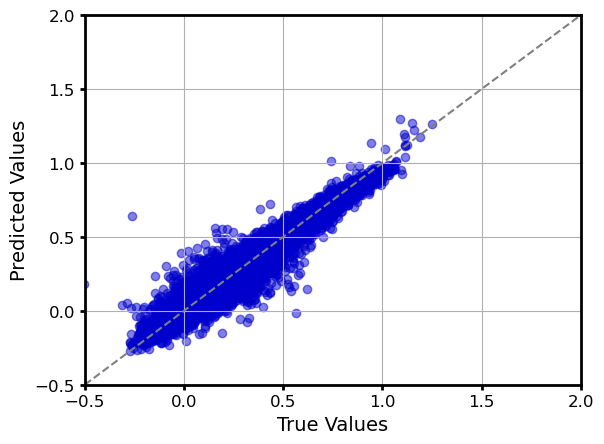

In [33]:
predvals_tensor, truevals_tensor = get_transformer_predictions(test_loader, model, device)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [34]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.046
Test MSE = 0.0042
Test RMSE = 0.0645
Test R2 = 0.9237


In [39]:
oneshot_results = pd.DataFrame({"model": "model_4", "truevals": truevals, "predvals": predvals.squeeze()})
oneshot_results.to_csv("model4_oneshot.csv")

### Single SMILES Prediction

In [27]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import pandas as pd
import matplotlib.pyplot as plt

def canonicalize(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")
    return Chem.MolToSmiles(mol, canonical=True)

def tanimoto_to_df(df, input_smiles_, smiles_col="SMILES"):
    """
    Compute Tanimoto similarity between an input SMILES and all SMILES in df[smiles_col].
    Returns a Pandas Series of similarity values.
    """

    input_smiles = canonicalize(input_smiles_)
    # Convert input SMILES to RDKit Mol
    mol_query = Chem.MolFromSmiles(input_smiles)
    fp_query = AllChem.GetMorganFingerprintAsBitVect(mol_query, radius=2, nBits=2048)

    similarities = []

    for smi in df[smiles_col]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            similarities.append(None)
            continue

        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        sim = DataStructs.TanimotoSimilarity(fp_query, fp)
        similarities.append(sim)

    return pd.Series(similarities, index=df.index)

def simple_tanimoto(input_smiles_, ref_smiles_):
    """
    Compute Tanimoto similarity between an input SMILES and a reference SMILES.
    """
    input_smiles = canonicalize(input_smiles_)
    ref_smiles = canonicalize(ref_smiles_)
    mol_query = Chem.MolFromSmiles(input_smiles)
    fp_query = AllChem.GetMorganFingerprintAsBitVect(mol_query, radius=2, nBits=2048)
    mol_ref = Chem.MolFromSmiles(ref_smiles)
    fp_ref = AllChem.GetMorganFingerprintAsBitVect(mol_ref, radius=2, nBits=2048)
    return DataStructs.TanimotoSimilarity(fp_query, fp_ref)


def get_prediction(smi_to_pred): # smi_to_pred = ["C1=CC=C1", "N#CC1=C(N)C(C#N)=C1N"]

    inp_smiles = canonicalize(smi_to_pred)
    pred_set = predDataset([inp_smiles], tokenizer)
    pred_loader = DataLoader(pred_set)
    with torch.no_grad():
        firstbatch = True
        for batch in pred_loader:
            input_ids = batch["input_ids"]
            attention_mask = batch["attention_mask"]
            if firstbatch == False:
                predvals_ = model(input_ids, attention_mask)
                predvals = torch.cat((predvals, predvals_), 0)
            else:
                predvals = model(input_ids, attention_mask)
                firstbatch = False

    # return predvals
    y = round(predvals.item(), 4)
    return {"prediction": y}

def plot_tanimoto_hist(similarities, bins=30):
    """
    Plot a histogram of Tanimoto similarity values.
    `similarities` should be a Pandas Series or list of floats.
    """
    # Drop None or NaN values
    sims = pd.Series(similarities).dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(sims, bins=bins, color="steelblue", edgecolor="black", alpha=0.8)
    plt.xlabel("Tanimoto similarity")
    plt.ylabel("Count")
    plt.title("Distribution of Tanimoto similarities")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
#-----------------------
# load the optimized parameters
#-----------------------

import json
from transformers import DataCollatorWithPadding

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

with open("Model4_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]

train_ds = SmilesDataset(train_cv_smiles, train_cv_stg, tokenizer)
test_smiles = test_df["SMILES"].values
test_stg = test_df["dE(S1-T1)"].values
test_ds = SmilesDataset(test_smiles, test_stg, tokenizer)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=data_collator, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True)

#-----------------------
# load model from checkpoint
#-----------------------

tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1", clean_up_tokenization_spaces=False)
model = ChemBERTaRegressor_meanpool(freeze_encoder=False).to(device)
model.load_state_dict(torch.load("model4_trial_4.pt", map_location=device))

running on cpu
Optimized parameters loaded: {'batch_size': 64, 'lr': 6.08490835421604e-05}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

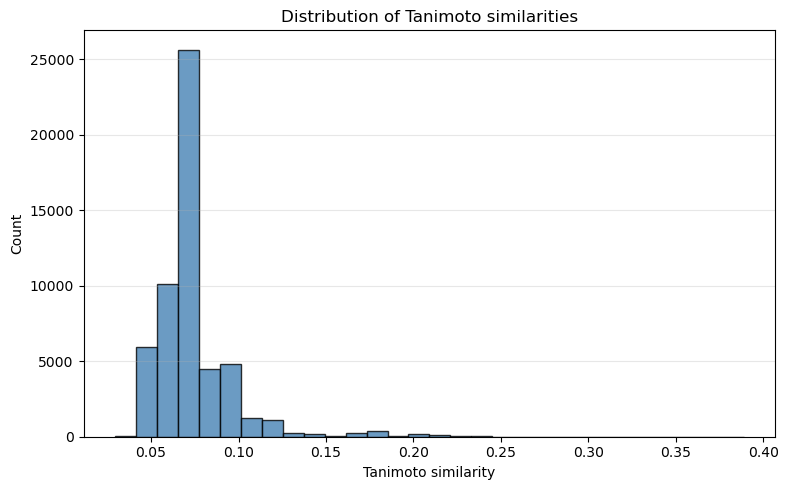

In [18]:
cyclazine = "C1=CC=C2C=CC=C3C=CC=C1N23"
heptazine = "N1=CN=C2N=CN=C3N=CN=C1N23"
sims = tanimoto_to_df(train_cv_df, heptazine)
plot_tanimoto_hist(sims)
plt.close()

In [ ]:
print(sims.min())
print(sims.max())
print(sims.mean())
most_similar = train_cv_df.loc[sims.idxmax(), "SMILES"]
print(f"most similar SMILES in the training set: {most_similar}")
print(simple_tanimoto(heptazine, most_similar)) # cross-check

0.029411764705882353
0.3888888888888889
0.0742853832211301
most similar SMILES in the training set: NC1=NC=N1
0.3888888888888889


In [22]:
train_cv_df.query("SMILES == 'NC1=NC=N1'")

,Molecule,dE(S0-S1),dE(S0-T1),dE(S1-T1),f12(S0-S1),SMILES,stg_binary
19,I_21,1.6025,1.9096,-0.3071,0.0012,NC1=NC=N1,0


In [20]:
get_prediction(heptazine)

{'prediction': 0.335}

## Model 4b

In [23]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset
import pandas as pd

tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k", clean_up_tokenization_spaces=False)

class SmilesDataset(Dataset):
    def __init__(self, smiles, labels, tokenizer):
        self.smiles = smiles
        self.labels = labels
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.smiles[idx],
            truncation=False,
            padding=False,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float)
        }

    def __len__(self):
        return len(self.smiles)

class RegressionHead(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.hs = hidden_size
        self.mlp = nn.Sequential(
            nn.LayerNorm(self.hs),
            nn.Linear(self.hs, self.hs * 2),
            nn.SiLU(),
            nn.Linear(self.hs * 2, 1))

    def forward(self, x):
        return self.mlp(x)

class ChemBERTaRegressor_clspool(nn.Module):
    def __init__(self, freeze_encoder=False):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")
        self.hidden_dim = self.encoder.config.hidden_size # 768 for chemBERTa

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.head = RegressionHead(self.hidden_dim)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls = outputs.last_hidden_state[:, 0]  # CLS token = '<s>'
        return self.head(cls)

class ChemBERTaRegressor_meanpool(nn.Module):
    def __init__(self, freeze_encoder=False):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")
        self.hidden_dim = self.encoder.config.hidden_size # 768 for chemBERTa

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.head = RegressionHead(self.hidden_dim)

    def mean_pool(self, hidden_states, attention_mask):
        # attention_mask: [batch, seq]
        # hidden_states:  [batch, seq, hidden]
        
        mask = attention_mask.unsqueeze(-1)          # [batch, seq, 1]
        masked_hidden = hidden_states * mask         # zero out padding
        summed = masked_hidden.sum(dim=1)            # sum over tokens
        counts = mask.sum(dim=1).clamp(min=1e-9)     # avoid division by zero
        return summed / counts                       # mean pooling

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state           # [batch, seq, hidden]
        pooled = self.mean_pool(hidden, attention_mask)  # [batch, hidden]

        return self.head(pooled)

def train_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["labels"].to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask).squeeze()
        loss = loss_fn(preds, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
    return total_loss / len(dataloader.dataset)

def eval_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["labels"].to(device)

            preds = model(input_ids, attention_mask).squeeze()
            loss = loss_fn(preds, targets)
            total_loss += loss.item() * input_ids.size(0)
    return total_loss / len(dataloader.dataset)

def get_transformer_predictions(dtaloader, model, device="cpu"): 
    N = 0
    with torch.no_grad():
        for batch in dtaloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["labels"].to(device)
            if N == 0:
                predvals = model(input_ids, attention_mask)
                truevals = targets
                N = 1
            else:
                predvals = torch.cat((predvals, model(input_ids, attention_mask)), 0)
                truevals = torch.cat((truevals, targets), 0)
    print(f"Shape of pred tensor: {predvals.shape}")
    print(f"Shape of true tensor: {truevals.shape}")
    return predvals, truevals


### Hyperparameter Optimization

In [ ]:
import optuna
import json
import copy
from transformers import DataCollatorWithPadding

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

# Tokenizer loaded in the model definition already
data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True) # per-batch dynamic padding

def objective(trial):

    # Parameters to be optimized
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64])
    lr = trial.suggest_float("lr", 5e-6, 3e-4, log=True) # log scale means the upper limit has more focus, going above 3e-4 is not recommended. Tested with 1e-3, failed horribly.
    num_epochs = 25

    # Set up the dataloaders using dataset and tokenizer
    dataset = SmilesDataset(train_cv_smiles, train_cv_stg, tokenizer)
    train_data, test_data = random_split(dataset, [0.8, 0.2])
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=data_collator, pin_memory=True)
    eval_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True) # Shuffling validation/test data has no benefit and can make debugging harder.

    # Model
    model = ChemBERTaRegressor_meanpool(freeze_encoder=False).to(device)
    # Optimizer recommended for RoBERTa‑based transformer models
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    patience = 3
    wait = 0
    # train with pruning and early stopping
    for epoch in range(num_epochs):  # Max epochs
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss = eval_epoch(model, eval_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
        
        # Track best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if trial.should_prune():
            print(f"Trial {trial.number} pruned at epoch {epoch}")
            raise optuna.TrialPruned()

        # Early stopping
        if wait >= patience:
            print(f"Trial {trial.number} early-stopped at epoch {epoch}")
            break
        trial.report(val_loss, step=epoch)

    torch.save(best_state, f"model4b_trial_{trial.number}.pt")
    return best_val_loss

# Create and run the study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25)

print("Best trial:")
print(study.best_trial.params)

# save results
with open("Model4b_optparams.json", "w") as f:
    json.dump(study.best_trial.params, f)

### 5x5 CV

In [ ]:
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from torch.utils.data import Subset
from transformers import DataCollatorWithPadding

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True) # per-batch dynamic padding

#-----------------------
# load the optimized parameters
#-----------------------

with open("Model4b_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
lr = optparams["lr"]
num_epochs = 25

dataset = SmilesDataset(train_cv_smiles, train_cv_stg, tokenizer)
loss_fn = nn.MSELoss()

#-----------------------
# do the 5x5 CV
#-----------------------

train_mae_list = []
train_mse_list = []
train_rmse_list = []
train_r2_list = []

val_mae_list = []
val_mse_list = []
val_rmse_list = []
val_r2_list = []

patience = 3  # how many epochs to wait for improvement, good practice is to set it slightly higher than in optuna
min_delta = 0.0  # minimum improvement to reset patience

for fold, (train_idx, val_idx) in enumerate(rkf.split(dataset)):
    train_ds = Subset(dataset, train_idx)
    val_ds   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=data_collator, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True)

    model = ChemBERTaRegressor_meanpool(freeze_encoder=False).to(device)
    # Optimizer recommended for RoBERTa‑based transformer models
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr)

    best_val_loss = float("inf")
    patience_counter = 0
    for epoch in range(num_epochs):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        tst_loss = eval_epoch(model, val_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f}, val_loss={tst_loss:.4f}")

        # --- EARLY STOPPING LOGIC ---
        if tst_loss < best_val_loss - min_delta:
            best_val_loss = tst_loss
            patience_counter = 0
            best_state = model.state_dict()  # save best model for this fold
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break
    
    # restore best model for this fold
    model.load_state_dict(best_state)

    # ---- Compute sklearn metrics for this fold ----
    # Collect predictions for train set
    y_train_pred_, y_train_true_ = get_transformer_predictions(train_loader, model, device)
    y_train_true = y_train_true_.detach().cpu().numpy()
    y_train_pred = y_train_pred_.detach().cpu().numpy()

    # Collect predictions for val set
    y_val_pred_, y_val_true_ = get_transformer_predictions(val_loader, model, device)
    y_val_true = y_val_true_.detach().cpu().numpy()
    y_val_pred = y_val_pred_.detach().cpu().numpy()

    # Train metrics
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_mse = mean_squared_error(y_train_true, y_train_pred)
    train_rmse = root_mean_squared_error(y_train_true, y_train_pred)
    train_r2 = r2_score(y_train_true, y_train_pred)

    # Val metrics
    val_mae = mean_absolute_error(y_val_true, y_val_pred)
    val_mse = mean_squared_error(y_val_true, y_val_pred)
    val_rmse = root_mean_squared_error(y_val_true, y_val_pred)
    val_r2 = r2_score(y_val_true, y_val_pred)

    # Store metrics
    train_mae_list.append(train_mae)
    train_mse_list.append(train_mse)
    train_rmse_list.append(train_rmse)
    train_r2_list.append(train_r2)

    val_mae_list.append(val_mae)
    val_mse_list.append(val_mse)
    val_rmse_list.append(val_rmse)
    val_r2_list.append(val_r2)

    print("------------------------")
    print(f"Fold {fold} finished:")
    print(f"Train: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R2={train_r2:.4f}")
    print(f"Val:   MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R2={val_r2:.4f}")
    print("------------------------")

#-----------------------
# save results
#-----------------------

cv_df_tr = pd.DataFrame({"subset": "train", "mae": train_mae_list, "mse": train_mse_list, "rmse": train_rmse_list, "R2": train_r2_list})
cv_df_val = pd.DataFrame({"subset": "valid", "mae": val_mae_list, "mse": val_mse_list, "rmse": val_rmse_list, "R2": val_r2_list})
cv_df = pd.concat([cv_df_tr, cv_df_val], ignore_index=True)
cv_df.to_csv("model4b_5x5CV.csv")

### One‑Shot Evaluation

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def truepred_plotter(predvals, truevals):
    ax_min = -0.5
    ax_max = 2.
    fig = plt.figure()
    plt.scatter(truevals, predvals, color='mediumblue', alpha=0.5, marker="o")
    plt.plot([ax_min, ax_max], [ax_min, ax_max], color='gray', linestyle='--')
    plt.xlabel('True Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.xlim(ax_min, ax_max)
    plt.ylim(ax_min, ax_max)
    for ax in fig.axes:
        ax.tick_params(width=2, labelsize=12)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    plt.grid()
    plt.show()


#### Hold-Out Test Set

In [10]:
#-----------------------
# load the optimized parameters
#-----------------------

import json
from transformers import DataCollatorWithPadding

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

with open("Model4b_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]

test_smiles = test_df["SMILES"].values
test_stg = test_df["dE(S1-T1)"].values
test_ds = SmilesDataset(test_smiles, test_stg, tokenizer)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True)

#-----------------------
# load model from checkpoint
#-----------------------

tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k", clean_up_tokenization_spaces=False)
model = ChemBERTaRegressor_meanpool(freeze_encoder=False).to(device)
model.load_state_dict(torch.load("model4b_trial_0.pt", map_location=device))


running on cuda
Optimized parameters loaded: {'batch_size': 32, 'lr': 3.438218331384998e-05}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/PubChem10M_SMILES_BPE_450k
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

In [11]:
pytorch_total_params = sum(p.numel() for p in model.parameters())
pytorch_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"total number of params: {pytorch_total_params}")
print(f"number of trainable params: {pytorch_trainable_params}")

total number of params: 84633601
number of trainable params: 84633601


c:\Users\feher\miniconda3\envs\ml_env_cpu\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape of pred tensor: torch.Size([13739, 1])
Shape of true tensor: torch.Size([13739])


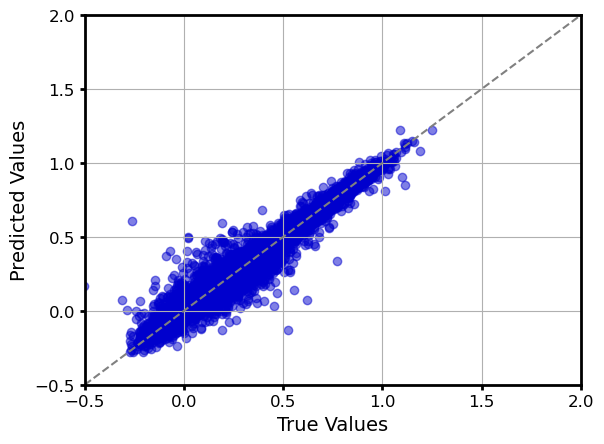

In [43]:
predvals_tensor, truevals_tensor = get_transformer_predictions(test_loader, model, device)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [44]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.0366
Test MSE = 0.003
Test RMSE = 0.0549
Test R2 = 0.9448


In [45]:
oneshot_results = pd.DataFrame({"model": "model_4b", "truevals": truevals, "predvals": predvals.squeeze()})
oneshot_results.to_csv("model4b_oneshot.csv")

#### External Test Set

In [25]:
from rdkit import Chem

def canonicalize(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")
    return Chem.MolToSmiles(mol, canonical=True)

#-----------------------
# load the optimized parameters
#-----------------------

import pandas as pd
import json
from transformers import DataCollatorWithPadding

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"running on {device}")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

with open("Model4b_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]

#-----------------------
# load model from checkpoint
#-----------------------

tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k", clean_up_tokenization_spaces=False)
model = ChemBERTaRegressor_meanpool(freeze_encoder=False).to(device)
model.load_state_dict(torch.load("model4b_trial_0.pt", map_location=device))


running on cuda
Optimized parameters loaded: {'batch_size': 32, 'lr': 3.438218331384998e-05}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/PubChem10M_SMILES_BPE_450k
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

In [26]:
# external_a = pd.read_csv("extrapolation_data_1.txt")
external_a = pd.read_csv("extrapolation_data_2.txt")
external_a["canon_SMILES"] = [canonicalize(s) for s in external_a["SMILES"].values]
test_smiles = external_a["canon_SMILES"].values
test_stg = external_a["STG"].values
test_ds = SmilesDataset(test_smiles, test_stg, tokenizer)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True)

Shape of pred tensor: torch.Size([59, 1])
Shape of true tensor: torch.Size([59])


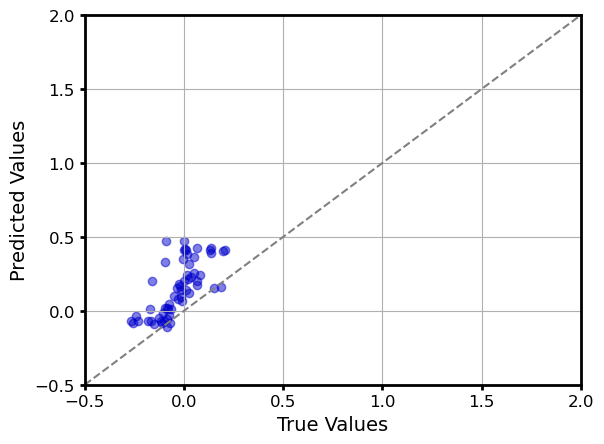

In [27]:
predvals_tensor, truevals_tensor = get_transformer_predictions(test_loader, model, device)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [28]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.1852
Test MSE = 0.0508
Test RMSE = 0.2253
Test R2 = -3.3022


In [29]:
oneshot_results = pd.DataFrame({"model": "model_4b", "truevals": truevals, "predvals": predvals.squeeze()})
oneshot_results.to_csv("model4b_external.csv")

In [12]:
# external_a = pd.read_csv("extrapolation_data_1.txt")
external_a = pd.read_csv("extrapolation_data_2.txt")
test_smiles = external_a["SMILES"].values
test_stg = external_a["STG"].values
test_ds = SmilesDataset(test_smiles, test_stg, tokenizer)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=data_collator, pin_memory=True)

c:\Users\feher\miniconda3\envs\ml_env_cpu\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape of pred tensor: torch.Size([59, 1])
Shape of true tensor: torch.Size([59])


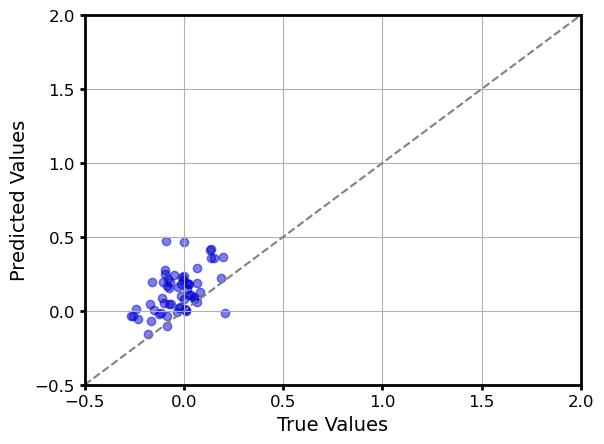

In [13]:
predvals_tensor, truevals_tensor = get_transformer_predictions(test_loader, model, device)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [14]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.1702
Test MSE = 0.0427
Test RMSE = 0.2067
Test R2 = -2.6191


In [16]:
oneshot_results = pd.DataFrame({"model": "model_4b", "truevals": truevals, "predvals": predvals.squeeze()})
oneshot_results.to_csv("model4b_external.csv")

## Model 5

In [46]:
from rdkit import Chem
import torch
from torch_geometric.data import Data

# -------------------------
# Atom feature extraction
# -------------------------
def atom_features(atom):
    return torch.tensor([
        atom.GetAtomicNum(),                 # atomic number
        atom.GetTotalDegree(),               # degree
        atom.GetFormalCharge(),              # formal charge
        int(atom.GetIsAromatic()),           # aromaticity
        atom.GetTotalNumHs(),                # number of Hs
        atom.GetHybridization().real,        # hybridization enum
    ], dtype=torch.float)

# -------------------------
# Bond feature extraction
# -------------------------
def bond_features(bond):
    bt = bond.GetBondType()
    return torch.tensor([
        int(bt == Chem.rdchem.BondType.SINGLE),
        int(bt == Chem.rdchem.BondType.DOUBLE),
        int(bt == Chem.rdchem.BondType.TRIPLE),
        int(bt == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ], dtype=torch.float)

# -------------------------
# Convert SMILES → PyG Data
# -------------------------
def smiles_to_pyg(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    # Node features
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        bf = bond_features(bond)

        # Undirected graph → add both directions
        edge_index.append([i, j])
        edge_attr.append(bf)

        edge_index.append([j, i])
        edge_attr.append(bf)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.stack(edge_attr, dim=0)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    return data

from torch.utils.data import Dataset, DataLoader, random_split
from torch_geometric.data import Batch
from transformers import AutoTokenizer

class MolHybridDataset(Dataset):
    def __init__(self, smiles_list, y_list, smiles_to_pyg_fn):
        self.smiles = smiles_list
        self.y = y_list
        self.smiles_to_pyg = smiles_to_pyg_fn

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        s = self.smiles[idx]
        g = self.smiles_to_pyg(s)  # returns a PyG Data object
        y = self.y[idx]
        return {"smiles": s, "graph": g, "y": y}

def collate_fn(batch):
    smiles_list = [b["smiles"] for b in batch]
    graphs = [b["graph"] for b in batch]
    ys = torch.tensor([b["y"] for b in batch], dtype=torch.float)

    chem_inputs = tokenizer(
        smiles_list,
        padding=True,
        truncation=True,
        return_tensors="pt",
        max_len=64,
    )

    pyg_batch = Batch.from_data_list(graphs)
    return chem_inputs, pyg_batch, ys

In [47]:
import torch
import torch.nn as nn
from torch_geometric.nn import GINConv, global_add_pool
import torch.nn.functional as F

#----------------------
# Graph encoder in PyG (GIN as GraphGPS-style stand‑in)
#   - GIN is a simple GNN that outputs graph embeddings
#----------------------

class PyGGraphEncoder(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, num_layers: int = 5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.input_norm = nn.LayerNorm(in_dim)
        self.convs = nn.ModuleList()
        self.bn = nn.ModuleList()

        for layer in range(num_layers):
            layer_in_dim = in_dim if layer == 0 else self.hidden_dim
            
            mlp = nn.Sequential(
                nn.Linear(layer_in_dim, self.hidden_dim),
                nn.SiLU(),
                nn.Linear(self.hidden_dim, self.hidden_dim))
            
            self.convs.append(GINConv(mlp))
            self.bn.append(nn.BatchNorm1d(self.hidden_dim))

    def forward(self, x, edge_index, batch):
        # x: [num_nodes, in_dim]
        # edge_index: [2, num_edges]
        # batch: [num_nodes]
        
        # Apply LayerNorm BEFORE the very first linear layer operation
        # to balance out the different scales in the node vectors.
        x = self.input_norm(x) 
        
        for conv, bn in zip(self.convs, self.bn):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.silu(x)
            
        # Graph-level embedding
        g = global_add_pool(x, batch)  # [batch_size, hidden_dim]
        return g

#----------------------
# ChemBERTa + PyG hybrid model
#----------------------

from transformers import AutoModel

class ChemBERTaGraphHybrid(nn.Module):
    def __init__(
        self,
        chemberta_name: str = "seyonec/ChemBERTa-zinc-base-v1",
        node_feat_dim: int = 32,
        graph_hidden_dim: int = 256,
        num_graph_layers: int = 5,
        out_dim: int = 1,
        freeze_chemberta: bool = False,
        freeze_graph: bool = False,
    ):
        super().__init__()

        # ChemBERTa encoder
        self.chemberta = AutoModel.from_pretrained(chemberta_name)
        self.chem_hidden_dim = self.chemberta.config.hidden_size

        if freeze_chemberta:
            for p in self.chemberta.parameters():
                p.requires_grad = False

        # PyG graph encoder (GIN stand-in for GraphGPS)
        self.graph_encoder = PyGGraphEncoder(
            in_dim=node_feat_dim,
            hidden_dim=graph_hidden_dim,
            num_layers=num_graph_layers,
        )

        if freeze_graph:
            for p in self.graph_encoder.parameters():
                p.requires_grad = False

        # Fusion + prediction head
        # Dynamically calculate fusion layer dimensions
        self.fusion_in_dim = self.chem_hidden_dim + self.graph_encoder.hidden_dim
        self.fusion = nn.Sequential(
            nn.LayerNorm(self.fusion_in_dim),
            nn.Linear(self.fusion_in_dim, self.fusion_in_dim * 2),
            nn.SiLU(),
            nn.Linear(self.fusion_in_dim * 2, out_dim))

    # def forward(self, chem_inputs, pyg_batch): # CLS pooling
    #     # chem_inputs: dict from ChemBERTa tokenizer
    #     chem_out = self.chemberta(**chem_inputs)
    #     chem_repr = chem_out.last_hidden_state[:, 0]  # [B, chem_hidden_dim]

    #     # pyg_batch: a torch_geometric.data.Batch
    #     x, edge_index, batch = pyg_batch.x, pyg_batch.edge_index, pyg_batch.batch
    #     graph_repr = self.graph_encoder(x, edge_index, batch)  # [B, graph_hidden_dim]

    #     z = torch.cat([chem_repr, graph_repr], dim=-1)
    #     pred = self.fusion(z)  # [B, out_dim]
    #     return pred
    
    def forward(self, chem_inputs, pyg_batch):
        # 1. Forward pass through ChemBERTa
        # chem_inputs: dict from ChemBERTa tokenizer
        chem_out = self.chemberta(**chem_inputs)
        
        # 2. MEAN POOLING (Safe type-casting for the mask)
        # Cast the 0/1 integer mask to match the transformer's floating-point type
        # pyg_batch: a torch_geometric.data.Batch
        mask = chem_inputs["attention_mask"].unsqueeze(-1).to(chem_out.last_hidden_state.dtype)
        
        # Calculate token average while completely ignoring the [PAD] tokens
        chem_repr = (chem_out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)

        # 3. Forward pass through your upgraded GIN (Outputs standard Sum Pooling)
        x, edge_index, batch = pyg_batch.x, pyg_batch.edge_index, pyg_batch.batch
        graph_repr = self.graph_encoder(x, edge_index, batch)  # [B, graph_hidden_dim]

        # 4. Concatenate and predict
        z = torch.cat([chem_repr, graph_repr], dim=-1)
        pred = self.fusion(z)
        
        return pred



In [48]:
def train_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for chem_inputs, pyg_batch, y in dataloader:
        chem_inputs = {k: v.to(device) for k, v in chem_inputs.items()}
        pyg_batch = pyg_batch.to(device)
        y = y.to(device)

        pred = model(chem_inputs, pyg_batch).squeeze(-1)
        loss = loss_fn(pred, y) # batch‑mean loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * chem_inputs['input_ids'].size(0) # convert the batch‑mean loss back into a sum (mean_loss * batch_size)
    return total_loss / len(dataloader.dataset) # convert the accumulated sum of losses back into a mean loss per sample across the entire dataset (= definition of epoch loss)

def eval_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for chem_inputs, pyg_batch, y in dataloader:
            chem_inputs = {k: v.to(device) for k, v in chem_inputs.items()}
            pyg_batch = pyg_batch.to(device)
            y = y.to(device)

            pred = model(chem_inputs, pyg_batch).squeeze(-1)
            loss = loss_fn(pred, y)
            total_loss += loss.item() * chem_inputs['input_ids'].size(0)
    return total_loss / len(dataloader.dataset)

def get_transformer_predictions(dtaloader, model, device="cpu"): 
    N = 0
    with torch.no_grad():
        for chem_inputs, pyg_batch, y in dtaloader:
            chem_inputs = {k: v.to(device) for k, v in chem_inputs.items()}
            pyg_batch = pyg_batch.to(device)
            y = y.to(device)
            if N == 0:
                predvals = model(chem_inputs, pyg_batch)
                truevals = y
                N = 1
            else:
                predvals = torch.cat((predvals, model(chem_inputs, pyg_batch)), 0)
                truevals = torch.cat((truevals, y), 0)
    print(f"Shape of pred tensor: {predvals.shape}")
    print(f"Shape of true tensor: {truevals.shape}")
    return predvals, truevals

### Hyperparameter Optimization

What **do not** tune:

- `node_feat_dim` → must match graph feature size (`Data.x` size)
- `chemberta_dim` → fixed at 768 for ChemBERTa
- `gpse_dim` → fixed by the GPSE model (to be implemented)

In [ ]:
import optuna
import json
import copy

tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):

    # Define the hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    graph_hidden_dim = trial.suggest_categorical("graph_hidden_dim", [128, 192, 256])
    num_graph_layers = trial.suggest_categorical("num_graph_layers", [3, 4, 5])
    lr = trial.suggest_float("lr", 5e-6, 1e-4, log=True)
    num_epochs = 30

    # set up dataloaders and the model
    dataset = MolHybridDataset(smiles_list=train_cv_smiles, y_list=train_cv_stg, smiles_to_pyg_fn=smiles_to_pyg)
    train_data, eval_data = random_split(dataset, [0.8, 0.2]) # internal validation
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, pin_memory=True)
    eval_loader = DataLoader(eval_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, pin_memory=True)

    # model
    model = ChemBERTaGraphHybrid(
        chemberta_name="seyonec/ChemBERTa-zinc-base-v1",
        node_feat_dim=6,      # must match Data.x size (= input dimension for the graph encoder)
        graph_hidden_dim=graph_hidden_dim,
        num_graph_layers=num_graph_layers,
        out_dim=1).to(device)
    # optimizer
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr)
    # loss
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    patience = 2
    wait = 0
    for epoch in range(num_epochs):  # Max epochs
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss = eval_epoch(model, eval_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
        
        # Track best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if trial.should_prune():
            print(f"Trial {trial.number} pruned at epoch {epoch}")
            raise optuna.TrialPruned()

        # Early stopping
        if wait >= patience:
            print(f"Trial {trial.number} early-stopped at epoch {epoch}")
            break
        trial.report(val_loss, step=epoch)
    
    torch.save(best_state, f"model5_trial_{trial.number}.pt")
    return best_val_loss

# try less aggressive pruning ???
# pruner = optuna.pruners.PercentilePruner(
#     percentile=40,             # prune only bottom 40%
#     n_startup_trials=10,       # first 10 trials never pruned
#     n_warmup_steps=8,          # no pruning before epoch 8
#     interval_steps=1)
# study = optuna.create_study(direction="minimize", pruner=pruner)

# Create and run the study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best trial:")
print(study.best_trial.params)

# save results
with open("Model5_optparams.json", "w") as f:
    json.dump(study.best_trial.params, f)

### 5x5 CV

In [ ]:
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from torch.utils.data import Subset

#-----------------------
# load the tokenizer and the optimized parameters
#-----------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

with open("Model5_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
graph_hidden_dim = optparams["graph_hidden_dim"]
num_graph_layers = optparams["num_graph_layers"]
lr = optparams["lr"]
num_epochs = 30

dataset = MolHybridDataset(smiles_list=train_cv_smiles, y_list=train_cv_stg, smiles_to_pyg_fn=smiles_to_pyg)
loss_fn = nn.MSELoss()

#-----------------------
# do the 5x5 CV
#-----------------------

train_mae_list = []
train_mse_list = []
train_rmse_list = []
train_r2_list = []

val_mae_list = []
val_mse_list = []
val_rmse_list = []
val_r2_list = []

patience = 3  # how many epochs to wait for improvement, good practice is to set it slightly higher than in optuna
min_delta = 0.0  # minimum improvement to reset patience

for fold, (train_idx, val_idx) in enumerate(rkf.split(dataset)):
    train_ds = Subset(dataset, train_idx)
    val_ds   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, pin_memory=True)

    # model
    model = ChemBERTaGraphHybrid(
        chemberta_name="seyonec/ChemBERTa-zinc-base-v1",
        node_feat_dim=6,
        graph_hidden_dim=graph_hidden_dim,
        num_graph_layers=num_graph_layers,
        out_dim=1).to(device)
    # optimizer
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr)

    best_val_loss = float("inf")
    patience_counter = 0
    for epoch in range(num_epochs):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        tst_loss = eval_epoch(model, val_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f}, val_loss={tst_loss:.4f}")

        # --- EARLY STOPPING LOGIC ---
        if tst_loss < best_val_loss - min_delta:
            best_val_loss = tst_loss
            patience_counter = 0
            best_state = model.state_dict()  # save best model for this fold
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break
    
    # restore best model for this fold
    model.load_state_dict(best_state)

    # ---- Compute sklearn metrics for this fold ----
    # Collect predictions for train set
    y_train_pred_, y_train_true_ = get_transformer_predictions(train_loader, model, device)
    y_train_true = y_train_true_.detach().cpu().numpy()
    y_train_pred = y_train_pred_.detach().cpu().numpy()

    # Collect predictions for val set
    y_val_pred_, y_val_true_ = get_transformer_predictions(val_loader, model, device)
    y_val_true = y_val_true_.detach().cpu().numpy()
    y_val_pred = y_val_pred_.detach().cpu().numpy()

    # Train metrics
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_mse = mean_squared_error(y_train_true, y_train_pred)
    train_rmse = root_mean_squared_error(y_train_true, y_train_pred)
    train_r2 = r2_score(y_train_true, y_train_pred)

    # Val metrics
    val_mae = mean_absolute_error(y_val_true, y_val_pred)
    val_mse = mean_squared_error(y_val_true, y_val_pred)
    val_rmse = root_mean_squared_error(y_val_true, y_val_pred)
    val_r2 = r2_score(y_val_true, y_val_pred)

    # Store metrics
    train_mae_list.append(train_mae)
    train_mse_list.append(train_mse)
    train_rmse_list.append(train_rmse)
    train_r2_list.append(train_r2)

    val_mae_list.append(val_mae)
    val_mse_list.append(val_mse)
    val_rmse_list.append(val_rmse)
    val_r2_list.append(val_r2)

    print("------------------------")
    print(f"Fold {fold} finished:")
    print(f"Train: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R2={train_r2:.4f}")
    print(f"Val:   MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R2={val_r2:.4f}")
    print("------------------------")

#-----------------------
# save results
#-----------------------

cv_df_tr = pd.DataFrame({"subset": "train", "mae": train_mae_list, "mse": train_mse_list, "rmse": train_rmse_list, "R2": train_r2_list})
cv_df_val = pd.DataFrame({"subset": "valid", "mae": val_mae_list, "mse": val_mse_list, "rmse": val_rmse_list, "R2": val_r2_list})
cv_df = pd.concat([cv_df_tr, cv_df_val], ignore_index=True)
cv_df.to_csv("model5_5x5CV.csv")

### One‑Shot Evaluation

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def truepred_plotter(predvals, truevals):
    ax_min = -0.5
    ax_max = 2.
    fig = plt.figure()
    plt.scatter(truevals, predvals, color='mediumblue', alpha=0.5, marker="o")
    plt.plot([ax_min, ax_max], [ax_min, ax_max], color='gray', linestyle='--')
    plt.xlabel('True Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.xlim(ax_min, ax_max)
    plt.ylim(ax_min, ax_max)
    for ax in fig.axes:
        ax.tick_params(width=2, labelsize=12)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    plt.grid()
    plt.show()


In [50]:
#-----------------------
# load the optimized parameters
#-----------------------

import json

with open("Model5_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
graph_hidden_dim = optparams["graph_hidden_dim"]
num_graph_layers = optparams["num_graph_layers"]

test_smiles = test_df["SMILES"].values
test_stg = test_df["dE(S1-T1)"].values
tst_ds = MolHybridDataset(smiles_list=test_smiles, y_list=test_stg, smiles_to_pyg_fn=smiles_to_pyg)
test_loader = DataLoader(tst_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, pin_memory=True)

#-----------------------
# load model from checkpoint
#-----------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1", clean_up_tokenization_spaces=False)
model = ChemBERTaGraphHybrid(
    chemberta_name="seyonec/ChemBERTa-zinc-base-v1",
    node_feat_dim=6,
    graph_hidden_dim=graph_hidden_dim,
    num_graph_layers=num_graph_layers,
    out_dim=1).to(device)
model.load_state_dict(torch.load("model5_trial_15.pt", map_location=device))


Optimized parameters loaded: {'batch_size': 16, 'graph_hidden_dim': 256, 'num_graph_layers': 4, 'lr': 2.906283310926898e-05}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

c:\Users\feher\miniconda3\envs\ml_env_cpu\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape of pred tensor: torch.Size([13739, 1])
Shape of true tensor: torch.Size([13739])


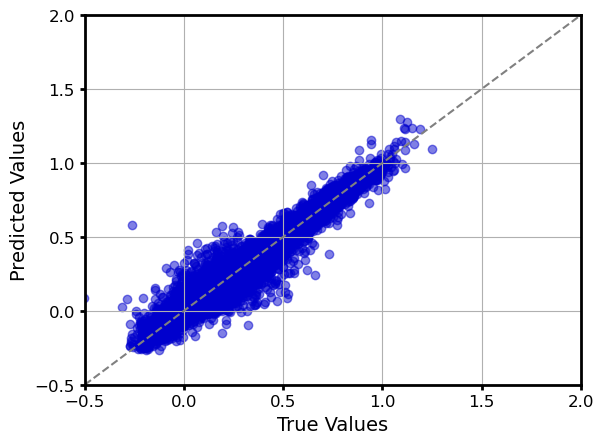

In [51]:
predvals_tensor, truevals_tensor = get_transformer_predictions(test_loader, model, device=device)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [52]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.0449
Test MSE = 0.0041
Test RMSE = 0.0637
Test R2 = 0.9256


In [53]:
oneshot_results = pd.DataFrame({"model": "model_5", "truevals": truevals, "predvals": predvals.squeeze()})
oneshot_results.to_csv("model5_oneshot.csv")

## Model 6

In [12]:
from rdkit import Chem
import torch
from torch_geometric.data import Data

# -------------------------
# Atom feature extraction
# -------------------------
def atom_features(atom):
    return torch.tensor([
        atom.GetAtomicNum(),                 # atomic number
        atom.GetTotalDegree(),               # degree
        atom.GetFormalCharge(),              # formal charge
        int(atom.GetIsAromatic()),           # aromaticity
        atom.GetTotalNumHs(),                # number of Hs
        atom.GetHybridization().real,        # hybridization enum
    ], dtype=torch.float)

# -------------------------
# Bond feature extraction
# -------------------------
def bond_features(bond):
    bt = bond.GetBondType()
    return torch.tensor([
        int(bt == Chem.rdchem.BondType.SINGLE),
        int(bt == Chem.rdchem.BondType.DOUBLE),
        int(bt == Chem.rdchem.BondType.TRIPLE),
        int(bt == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ], dtype=torch.float)

# -------------------------
# Convert SMILES → PyG Data
# -------------------------
def smiles_to_pyg(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    # Node features
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        bf = bond_features(bond)

        # Undirected graph → add both directions
        edge_index.append([i, j])
        edge_attr.append(bf)

        edge_index.append([j, i])
        edge_attr.append(bf)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.stack(edge_attr, dim=0)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    return data

from torch.utils.data import Dataset, DataLoader, random_split
from torch_geometric.data import Batch
from transformers import AutoTokenizer

class MolHybridDataset(Dataset):
    def __init__(self, smiles_list, y_list, smiles_to_pyg_fn):
        self.smiles = smiles_list
        self.y = y_list
        self.smiles_to_pyg = smiles_to_pyg_fn

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        s = self.smiles[idx]
        g = self.smiles_to_pyg(s)  # returns a PyG Data object
        y = self.y[idx]
        return {"smiles": s, "graph": g, "y": y}

def collate_fn(batch):
    smiles_list = [b["smiles"] for b in batch]
    graphs = [b["graph"] for b in batch]
    ys = torch.tensor([b["y"] for b in batch], dtype=torch.float)

    chem_inputs = tokenizer(
        smiles_list,
        padding=True, # it is done at batch-level, so it is dynamic padding
        truncation=True,
        return_tensors="pt",
        max_length=64,
    )

    pyg_batch = Batch.from_data_list(graphs)
    return chem_inputs, pyg_batch, ys

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GPSConv, GraphNorm, global_mean_pool, GINConv
from torch_geometric.utils import get_laplacian, to_dense_adj


# ---------------------------------------------------------
# Laplacian Positional Encoding (LapPE)
# ---------------------------------------------------------
def compute_lappe(edge_index, num_nodes, k, x):
    edge_index, edge_weight = get_laplacian(edge_index, normalization="sym", num_nodes=num_nodes)
    L = to_dense_adj(edge_index, edge_attr=edge_weight, max_num_nodes=num_nodes)[0].to(x.device)

    eigvals, eigvecs = torch.linalg.eigh(L)
    return eigvecs[:, :k]

# ---------------------------------------------------------
# Random Walk Structural Encoding (RWSE)
# ---------------------------------------------------------
def compute_rwse(edge_index, num_nodes, steps, x):
    A = to_dense_adj(edge_index, max_num_nodes=num_nodes)[0].to(x.device)
    deg = A.sum(dim=-1, keepdim=True) + 1e-8
    P = A / deg

    P_t = torch.eye(num_nodes, device=x.device, dtype=x.dtype)
    rwse_list = []

    for _ in range(steps):
        P_t = P_t @ P
        rwse_list.append(torch.diagonal(P_t).unsqueeze(-1))

    return torch.cat(rwse_list, dim=-1)

# ---------------------------------------------------------
# Centrality Encoding (degree + eigenvector centrality)
# ---------------------------------------------------------
def compute_centrality(edge_index, num_nodes, x):
    A = to_dense_adj(edge_index, max_num_nodes=num_nodes)[0].to(x.device)

    deg = A.sum(dim=-1, keepdim=True)

    v = torch.rand(num_nodes, 1, device=x.device, dtype=x.dtype)
    for _ in range(20):
        v = A @ v
        v = v / (v.norm() + 1e-8)

    return torch.cat([deg, v], dim=-1)

# ---------------------------------------------------------
# GPSE + GPSConv Encoder
# ---------------------------------------------------------
def make_gps_layer(hidden_dim):
    # Local GNN: GIN
    local_gnn = GINConv(
        nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
    )

    # GPSConv with PyG 2.7.0 API
    return GPSConv(
        channels=hidden_dim,
        conv=local_gnn,
        attn_type='multihead',
        heads=4,
        dropout=0.1, # we do not optimize this
        act='relu'
    )

class GPSE_GPSConvEncoder(nn.Module):
    def __init__(
        self,
        node_feat_dim,
        hidden_dim=128,
        num_layers=4,
        graph_activation="gelu", # "relu", "gelu", "silu"
        dropout=0.1,
        rwse_steps=8,
        lappe_dim=8,
        centrality_dim=2,
    ):
        super().__init__()

        self.graph_activation = graph_activation
        self.rwse_steps = rwse_steps
        self.lappe_dim = lappe_dim
        self.centrality_dim = centrality_dim

        total_struct_dim = rwse_steps + lappe_dim + centrality_dim

        self.input_proj = nn.Linear(node_feat_dim + total_struct_dim, hidden_dim)
        self.layers = nn.ModuleList([make_gps_layer(hidden_dim) for _ in range(num_layers)])
        self.norms = nn.ModuleList([GraphNorm(hidden_dim) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)

    # def forward(self, data): # accepts a PyG Data or Batch object directly (pass collate_fn(batch) as input)
    #     x, edge_index, batch = data.x, data.edge_index, data.batch
    #     num_nodes = x.size(0)

    #     # Compute GPSE encodings
    #     rwse = compute_rwse(edge_index, num_nodes, steps=self.rwse_steps)
    #     lappe = compute_lappe(edge_index, num_nodes, k=self.lappe_dim)
    #     cent = compute_centrality(edge_index, num_nodes)

    #     # Concatenate node features + structural encodings
    #     x = torch.cat([x, rwse, lappe, cent], dim=-1)

    #     x = self.input_proj(x)

    #     for conv, norm in zip(self.layers, self.norms):
    #         x = conv(x, edge_index, batch=batch)
    #         x = norm(x, batch)
    #         x = F.relu(x)
    #         x = self.dropout(x)

    #     graph_emb = global_mean_pool(x, batch)
    #     return graph_emb

    def forward(self, x, edge_index, batch): # compatible with Model 5
        num_nodes = x.size(0)

        rwse = compute_rwse(edge_index, num_nodes, self.rwse_steps, x)
        lappe = compute_lappe(edge_index, num_nodes, self.lappe_dim, x)
        cent = compute_centrality(edge_index, num_nodes, x)

        x = torch.cat([x, rwse, lappe, cent], dim=-1)
        x = self.input_proj(x)

        for conv, norm in zip(self.layers, self.norms):
            x = conv(x, edge_index, batch=batch)
            x = norm(x, batch)
            if self.graph_activation == "relu":
                x = F.relu(x)
            elif self.graph_activation == "gelu":
                x = F.gelu(x)
            elif self.graph_activation == "silu":
                x = F.silu(x)
            x = self.dropout(x)

        # Because GPSConv mixes local and global attention, 
        # the node embeddings are already normalized in a way that makes mean pooling a natural fit.
        return global_mean_pool(x, batch)


#----------------------
# ChemBERTa + PyG hybrid model
#----------------------

from transformers import AutoModel

class GatedFusion(nn.Module):
    def __init__(self, chem_dim, graph_dim, hidden_dim):
        super().__init__()

        # Project both modalities to a shared hidden space
        self.proj_chem = nn.Linear(chem_dim, hidden_dim)
        self.proj_graph = nn.Linear(graph_dim, hidden_dim)

        # Gating network: decides how much to trust each modality
        self.gate = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, chem_repr, graph_repr):
        # Project to shared space
        c = self.proj_chem(chem_repr)
        g = self.proj_graph(graph_repr)

        # Compute gate value α in [0, 1]
        alpha = self.gate(torch.cat([c, g], dim=-1))

        # Gated combination
        fused = alpha * c + (1 - alpha) * g
        return fused

class ChemBERTaGraphHybrid(nn.Module):
    def __init__(
        self,
        chemberta_name: str = "seyonec/ChemBERTa-zinc-base-v1",
        node_feat_dim: int = 32,
        graph_hidden_dim: int = 256,
        fusion_dim: int = 512,
        num_graph_layers: int = 5,
        graph_activation="gelu",
        graph_dropout=0.1,
        # out_dim: int = 1,
        freeze_chemberta: bool = False,
        freeze_graph: bool = False,
        use_fusion=True,
        head_activation="gelu",
        head_dim: int = 512,
        pooling="cls" # "mean" or "cls"
    ):
        super().__init__()

        self.pooling = pooling
        self.use_fusion = use_fusion
        # ChemBERTa encoder
        self.chemberta = AutoModel.from_pretrained(chemberta_name)
        self.chem_hidden_dim = self.chemberta.config.hidden_size
        self.graph_hidden_dim = graph_hidden_dim
        self.fusion_dim = fusion_dim

        if freeze_chemberta:
            for p in self.chemberta.parameters():
                p.requires_grad = False

        # GPSE + GPSConv Encoder
        self.graph_encoder = GPSE_GPSConvEncoder(
            node_feat_dim=node_feat_dim,
            hidden_dim=self.graph_hidden_dim,
            num_layers=num_graph_layers,
            graph_activation=graph_activation,
            dropout=graph_dropout,
            rwse_steps=8,
            lappe_dim=8,
            centrality_dim=2
        )

        if freeze_graph:
            for p in self.graph_encoder.parameters():
                p.requires_grad = False

        # Optional GatedFusion
        if self.use_fusion:
            self.fusion = GatedFusion(chem_dim=self.chem_hidden_dim, graph_dim=self.graph_hidden_dim, hidden_dim=self.fusion_dim)
            fused_dim = self.fusion_dim
        else:
            # No fusion → concatenate raw representations
            fused_dim = self.chem_hidden_dim + self.graph_hidden_dim

        # Prediction head
        act = nn.GELU() if head_activation == "gelu" else nn.SiLU()
        self.head = nn.Sequential(
            nn.LayerNorm(fused_dim), 
            nn.Linear(fused_dim, head_dim), # 2x expansion might not be optimal for hybrid models
            act,
            nn.Linear(head_dim, 1), # dropout not recommended for a head this small
        )

    def forward(self, chem_inputs, pyg_batch):
        # chem_inputs: dict from ChemBERTa tokenizer
        chem_out = self.chemberta(**chem_inputs)
        # chem_repr = chem_out.last_hidden_state[:, 0]  # [B, chem_hidden_dim]

        if self.pooling == "cls":
            chem_repr = chem_out.last_hidden_state[:, 0]
        else:
            mask = chem_inputs["attention_mask"].unsqueeze(-1)
            chem_repr = (chem_out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)

        # pyg_batch: a torch_geometric.data.Batch
        x, edge_index, batch = pyg_batch.x, pyg_batch.edge_index, pyg_batch.batch
        graph_repr = self.graph_encoder(x, edge_index, batch)  # [B, graph_hidden_dim]

        if self.use_fusion:
            fused = self.fusion(chem_repr, graph_repr) # [B, fusion_dim]
        else:
            fused = torch.cat([chem_repr, graph_repr], dim=-1)

        pred = self.head(fused)
        return pred


In [ ]:
def train_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for chem_inputs, pyg_batch, y in dataloader:
        chem_inputs = {k: v.to(device) for k, v in chem_inputs.items()}
        pyg_batch = pyg_batch.to(device)
        y = y.to(device)

        pred = model(chem_inputs, pyg_batch).squeeze(-1)
        loss = loss_fn(pred, y) # batch‑mean loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * chem_inputs['input_ids'].size(0) # convert the batch‑mean loss back into a sum (mean_loss * batch_size)
    return total_loss / len(dataloader.dataset) # convert the accumulated sum of losses back into a mean loss per sample across the entire dataset (= definition of epoch loss)

def eval_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for chem_inputs, pyg_batch, y in dataloader:
            chem_inputs = {k: v.to(device) for k, v in chem_inputs.items()}
            pyg_batch = pyg_batch.to(device)
            y = y.to(device)

            pred = model(chem_inputs, pyg_batch).squeeze(-1)
            loss = loss_fn(pred, y)
            total_loss += loss.item() * chem_inputs['input_ids'].size(0)
    return total_loss / len(dataloader.dataset)

def get_transformer_predictions(dtaloader, model, device="cpu"): 
    N = 0
    with torch.no_grad():
        for chem_inputs, pyg_batch, y in dtaloader:
            chem_inputs = {k: v.to(device) for k, v in chem_inputs.items()}
            pyg_batch = pyg_batch.to(device)
            y = y.to(device)
            if N == 0:
                predvals = model(chem_inputs, pyg_batch)
                truevals = y
                N = 1
            else:
                predvals = torch.cat((predvals, model(chem_inputs, pyg_batch)), 0)
                truevals = torch.cat((truevals, y), 0)
    print(f"Shape of pred tensor: {predvals.shape}")
    print(f"Shape of true tensor: {truevals.shape}")
    return predvals, truevals

### Hyperparameter Optimization

In [ ]:
import optuna
import json
import copy

tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def objective(trial):

    # Define the hyperparameter search space
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    graph_hidden_dim = trial.suggest_categorical("graph_hidden_dim", [128, 192, 256])
    num_graph_layers = trial.suggest_categorical("num_graph_layers", [3, 4, 5])
    graph_activation = trial.suggest_categorical("graph_activation", ["relu", "gelu", "silu"])
    graph_dropout = trial.suggest_float("graph_dropout", 0.0, 0.3)
    use_fusion = trial.suggest_categorical("use_fusion", [True, False])
    fusion_dim = trial.suggest_categorical("fusion_dim", [128, 256, 384, 512])
    pooling = trial.suggest_categorical("pooling", ["cls", "mean"])
    head_activation = trial.suggest_categorical("head_activation", ["gelu", "silu"])
    head_dim = trial.suggest_categorical("head_dim", [128, 256, 384, 512, 768])
    lr = trial.suggest_float("lr", 5e-6, 1e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    num_epochs = 30

    # set up dataloaders and the model
    dataset = MolHybridDataset(smiles_list=train_cv_smiles, y_list=train_cv_stg, smiles_to_pyg_fn=smiles_to_pyg)
    train_data, eval_data = random_split(dataset, [0.8, 0.2]) # internal validation
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, pin_memory=True)
    eval_loader = DataLoader(eval_data, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, pin_memory=True)

    # model
    model = ChemBERTaGraphHybrid(
        chemberta_name="seyonec/ChemBERTa-zinc-base-v1",
        node_feat_dim=6,      # must match Data.x size (= input dimension for the graph encoder)
        graph_hidden_dim=graph_hidden_dim,
        num_graph_layers=num_graph_layers,
        fusion_dim=fusion_dim,
        graph_activation=graph_activation,
        graph_dropout=graph_dropout,
        head_activation=head_activation,
        head_dim=head_dim,
        use_fusion=use_fusion,
        pooling=pooling
    ).to(device)
    # optimizer
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr, weight_decay=weight_decay)
    # loss
    loss_fn = nn.MSELoss()

    # train with pruning and early stopping
    best_val_loss = float("inf")
    best_state = None
    patience = 3
    wait = 0
    for epoch in range(num_epochs):  # Max epochs
        train_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss = eval_epoch(model, eval_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
        
        # Track best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if trial.should_prune():
            print(f"Trial {trial.number} pruned at epoch {epoch}")
            raise optuna.TrialPruned()

        # Early stopping
        if wait >= patience:
            print(f"Trial {trial.number} early-stopped at epoch {epoch}")
            break
        trial.report(val_loss, step=epoch)
    
    torch.save(best_state, f"model6_trial_{trial.number}.pt")
    return best_val_loss

# try less aggressive pruning ???
pruner = optuna.pruners.PercentilePruner(
    percentile=40,             # prune only bottom 40%
    n_startup_trials=10,       # first 10 trials never pruned
    n_warmup_steps=8,          # no pruning before epoch 8
    interval_steps=1)
study = optuna.create_study(direction="minimize", pruner=pruner)

# Create and run the study
# study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial.params)

# save results
with open("Model6_optparams.json", "w") as f:
    json.dump(study.best_trial.params, f)

### 5x5 CV

In [ ]:
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import Subset

#-----------------------
# load the tokenizer and the optimized parameters
#-----------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

with open("Model6_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
graph_hidden_dim = optparams["graph_hidden_dim"]
num_graph_layers = optparams["num_graph_layers"]
graph_activation = optparams["graph_activation"]
graph_dropout = optparams["graph_dropout"]
use_fusion = optparams["use_fusion"]
fusion_dim = optparams["fusion_dim"]
pooling = optparams["pooling"]
head_activation = optparams["head_activation"]
head_dim = optparams["head_dim"]
lr = optparams["lr"]
weight_decay = optparams["weight_decay"]
num_epochs = 30

dataset = MolHybridDataset(smiles_list=train_cv_smiles, y_list=train_cv_stg, smiles_to_pyg_fn=smiles_to_pyg)
loss_fn = nn.MSELoss()

#-----------------------
# do the 5x5 CV
#-----------------------

train_mae_list = []
train_mse_list = []
train_rmse_list = []
train_r2_list = []

val_mae_list = []
val_mse_list = []
val_rmse_list = []
val_r2_list = []

patience = 3  # how many epochs to wait for improvement, good practice is to set it slightly higher than in optuna
min_delta = 0.0  # minimum improvement to reset patience

for fold, (train_idx, val_idx) in enumerate(rkf.split(dataset)):
    train_ds = Subset(dataset, train_idx)
    val_ds   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, pin_memory=True)
    # model
    model = ChemBERTaGraphHybrid(
        chemberta_name="seyonec/ChemBERTa-zinc-base-v1",
        node_feat_dim=6,      # must match Data.x size (= input dimension for the graph encoder)
        graph_hidden_dim=graph_hidden_dim,
        num_graph_layers=num_graph_layers,
        fusion_dim=fusion_dim,
        graph_activation=graph_activation,
        graph_dropout=graph_dropout,
        head_activation=head_activation,
        head_dim=head_dim,
        use_fusion=use_fusion,
        pooling=pooling).to(device)
    # optimizer
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr)

    best_val_loss = float("inf")
    patience_counter = 0
    for epoch in range(num_epochs):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        tst_loss = eval_epoch(model, val_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f}, val_loss={tst_loss:.4f}")

        # --- EARLY STOPPING LOGIC ---
        if tst_loss < best_val_loss - min_delta:
            best_val_loss = tst_loss
            patience_counter = 0
            best_state = model.state_dict()  # save best model for this fold
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break
    
    # restore best model for this fold
    model.load_state_dict(best_state)

    # ---- Compute sklearn metrics for this fold ----
    # Collect predictions for train set
    y_train_pred_, y_train_true_ = get_transformer_predictions(train_loader, model, device)
    y_train_true = y_train_true_.detach().cpu().numpy()
    y_train_pred = y_train_pred_.detach().cpu().numpy()

    # Collect predictions for val set
    y_val_pred_, y_val_true_ = get_transformer_predictions(val_loader, model, device)
    y_val_true = y_val_true_.detach().cpu().numpy()
    y_val_pred = y_val_pred_.detach().cpu().numpy()

    # Train metrics
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_mse = mean_squared_error(y_train_true, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train_true, y_train_pred)

    # Val metrics
    val_mae = mean_absolute_error(y_val_true, y_val_pred)
    val_mse = mean_squared_error(y_val_true, y_val_pred)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val_true, y_val_pred)

    # Store metrics
    train_mae_list.append(train_mae)
    train_mse_list.append(train_mse)
    train_rmse_list.append(train_rmse)
    train_r2_list.append(train_r2)

    val_mae_list.append(val_mae)
    val_mse_list.append(val_mse)
    val_rmse_list.append(val_rmse)
    val_r2_list.append(val_r2)

    print("------------------------")
    print(f"Fold {fold} finished:")
    print(f"Train: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R2={train_r2:.4f}")
    print(f"Val:   MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R2={val_r2:.4f}")
    print("------------------------")

#-----------------------
# save results
#-----------------------

cv_df_tr = pd.DataFrame({"subset": "train", "mae": train_mae_list, "mse": train_mse_list, "rmse": train_rmse_list, "R2": train_r2_list})
cv_df_val = pd.DataFrame({"subset": "valid", "mae": val_mae_list, "mse": val_mse_list, "rmse": val_rmse_list, "R2": val_r2_list})
cv_df = pd.concat([cv_df_tr, cv_df_val], ignore_index=True)
cv_df.to_csv("model6_5x5CV.csv")


In [ ]:
# import json
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from torch.utils.data import Subset

# #-----------------------
# # load the tokenizer and the optimized parameters
# #-----------------------

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1")

# with open("Model6_optparams.json", "r") as f:
#     optparams = json.load(f)
# print(f"Optimized parameters loaded: {optparams}")

# batch_size = optparams["batch_size"]
# graph_hidden_dim = optparams["graph_hidden_dim"]
# num_graph_layers = optparams["num_graph_layers"]
# graph_dropout = optparams["graph_dropout"]
# lr = optparams["lr"]
# num_epochs = 30

# dataset = MolHybridDataset(smiles_list=train_cv_smiles, y_list=train_cv_stg, smiles_to_pyg_fn=smiles_to_pyg)
# loss_fn = nn.MSELoss()

# #-----------------------
# # do the 5x5 CV
# #-----------------------

# train_mae_list = []
# train_mse_list = []
# train_rmse_list = []
# train_r2_list = []

# val_mae_list = []
# val_mse_list = []
# val_rmse_list = []
# val_r2_list = []

# patience = 3  # how many epochs to wait for improvement, good practice is to set it slightly higher than in optuna
# min_delta = 0.0  # minimum improvement to reset patience

# for fold, (train_idx, val_idx) in enumerate(rkf.split(dataset)):
#     train_ds = Subset(dataset, train_idx)
#     val_ds   = Subset(dataset, val_idx)

#     train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, pin_memory=True)
#     val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, pin_memory=True)
#     # model
#     model = ChemBERTaGraphHybrid(
#                                 chemberta_name="seyonec/ChemBERTa-zinc-base-v1",
#                                 node_feat_dim=6,      # must match Data.x size (= input dimension for the graph encoder)
#                                 graph_hidden_dim=graph_hidden_dim,
#                                 num_graph_layers=num_graph_layers,
#                                 graph_dropout=graph_dropout
#                                 ).to(device)
#     # optimizer
#     no_decay = ["bias", "LayerNorm.weight"]
#     optimizer_grouped_parameters = [
#         {
#             "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
#             "weight_decay": 0.01,
#         },
#         {
#             "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
#             "weight_decay": 0.0,
#         }]
#     optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr)

#     best_val_loss = float("inf")
#     patience_counter = 0
#     for epoch in range(num_epochs):
#         tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
#         tst_loss = eval_epoch(model, val_loader, loss_fn, device)
#         print(f"Epoch {epoch}: train_loss={tr_loss:.4f}, val_loss={tst_loss:.4f}")

#         # --- EARLY STOPPING LOGIC ---
#         if tst_loss < best_val_loss - min_delta:
#             best_val_loss = tst_loss
#             patience_counter = 0
#             best_state = model.state_dict()  # save best model for this fold
#         else:
#             patience_counter += 1

#         if patience_counter >= patience:
#             print(f"Early stopping triggered at epoch {epoch}")
#             break
    
#     # restore best model for this fold
#     model.load_state_dict(best_state)

#     # ---- Compute sklearn metrics for this fold ----
#     # Collect predictions for train set
#     y_train_pred_, y_train_true_ = get_predictions(train_loader, model, device)
#     y_train_true = y_train_true_.detach().cpu().numpy()
#     y_train_pred = y_train_pred_.detach().cpu().numpy()

#     # Collect predictions for val set
#     y_val_pred_, y_val_true_ = get_predictions(val_loader, model, device)
#     y_val_true = y_val_true_.detach().cpu().numpy()
#     y_val_pred = y_val_pred_.detach().cpu().numpy()

#     # Train metrics
#     train_mae = mean_absolute_error(y_train_true, y_train_pred)
#     train_mse = mean_squared_error(y_train_true, y_train_pred)
#     train_rmse = np.sqrt(train_mse)
#     train_r2 = r2_score(y_train_true, y_train_pred)

#     # Val metrics
#     val_mae = mean_absolute_error(y_val_true, y_val_pred)
#     val_mse = mean_squared_error(y_val_true, y_val_pred)
#     val_rmse = np.sqrt(val_mse)
#     val_r2 = r2_score(y_val_true, y_val_pred)

#     # Store metrics
#     train_mae_list.append(train_mae)
#     train_mse_list.append(train_mse)
#     train_rmse_list.append(train_rmse)
#     train_r2_list.append(train_r2)

#     val_mae_list.append(val_mae)
#     val_mse_list.append(val_mse)
#     val_rmse_list.append(val_rmse)
#     val_r2_list.append(val_r2)

#     print("------------------------")
#     print(f"Fold {fold} finished:")
#     print(f"Train: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R2={train_r2:.4f}")
#     print(f"Val:   MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R2={val_r2:.4f}")
#     print("------------------------")

# #-----------------------
# # save results
# #-----------------------

# cv_df_tr = pd.DataFrame({"subset": "train", "mae": train_mae_list, "mse": train_mse_list, "rmse": train_rmse_list, "R2": train_r2_list})
# cv_df_val = pd.DataFrame({"subset": "valid", "mae": val_mae_list, "mse": val_mse_list, "rmse": val_rmse_list, "R2": val_r2_list})
# cv_df = pd.concat([cv_df_tr, cv_df_val], ignore_index=True)
# cv_df.to_csv("model3_5x5CV.csv")

### One‑Shot Evaluation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def truepred_plotter(predvals, truevals):
    ax_min = -0.5
    ax_max = 2.
    fig = plt.figure()
    plt.scatter(truevals, predvals, color='mediumblue', alpha=0.5, marker="o")
    plt.plot([ax_min, ax_max], [ax_min, ax_max], color='gray', linestyle='--')
    plt.xlabel('True Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.xlim(ax_min, ax_max)
    plt.ylim(ax_min, ax_max)
    for ax in fig.axes:
        ax.tick_params(width=2, labelsize=12)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    plt.grid()
    plt.show()



In [16]:
#-----------------------
# load the optimized parameters
#-----------------------

import json

with open("Model6_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
graph_hidden_dim = optparams["graph_hidden_dim"]
num_graph_layers = optparams["num_graph_layers"]
graph_activation = optparams["graph_activation"]
graph_dropout = optparams["graph_dropout"]
use_fusion = optparams["use_fusion"]
fusion_dim = optparams["fusion_dim"]
pooling = optparams["pooling"]
head_activation = optparams["head_activation"]
head_dim = optparams["head_dim"]

test_smiles = test_df["SMILES"].values
test_stg = test_df["dE(S1-T1)"].values
tst_ds = MolHybridDataset(smiles_list=test_smiles, y_list=test_stg, smiles_to_pyg_fn=smiles_to_pyg)
test_loader = DataLoader(tst_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, pin_memory=True)

#-----------------------
# load model from checkpoint
#-----------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("seyonec/ChemBERTa-zinc-base-v1", clean_up_tokenization_spaces=False)
model = ChemBERTaGraphHybrid(
    chemberta_name="seyonec/ChemBERTa-zinc-base-v1",
    node_feat_dim=6,      # must match Data.x size (= input dimension for the graph encoder)
    graph_hidden_dim=graph_hidden_dim,
    num_graph_layers=num_graph_layers,
    fusion_dim=fusion_dim,
    graph_activation=graph_activation,
    graph_dropout=graph_dropout,
    head_activation=head_activation,
    head_dim=head_dim,
    use_fusion=use_fusion,
    pooling=pooling
).to(device)
model.load_state_dict(torch.load("model6_trial_22.pt", map_location=device))


Optimized parameters loaded: {'batch_size': 16, 'graph_hidden_dim': 192, 'num_graph_layers': 5, 'graph_activation': 'relu', 'graph_dropout': 0.24320980488750008, 'use_fusion': False, 'fusion_dim': 512, 'pooling': 'mean', 'head_activation': 'gelu', 'head_dim': 512, 'lr': 2.2241812494359715e-05, 'weight_decay': 1.0034082543345758e-06}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

Shape of pred tensor: torch.Size([13739, 1])
Shape of true tensor: torch.Size([13739])


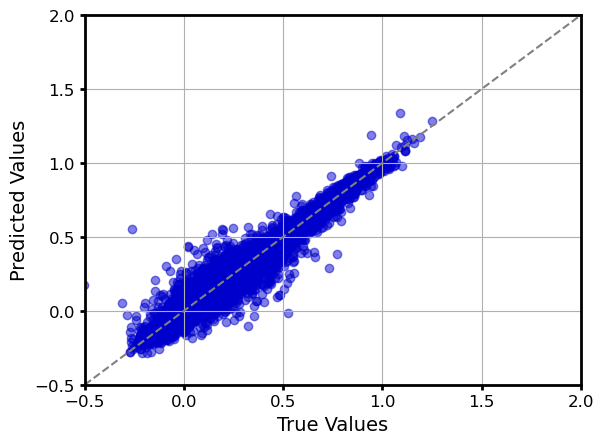

In [17]:
predvals_tensor, truevals_tensor = get_transformer_predictions(test_loader, model, device=device)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [18]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.0387
Test MSE = 0.0032
Test RMSE = 0.0567
Test R2 = 0.941


In [19]:
oneshot_results = pd.DataFrame({"model": "model_6", "truevals": truevals, "predvals": predvals.squeeze()})
oneshot_results.to_csv("model6_oneshot.csv")

## Model 6b

In [1]:
from rdkit import Chem
import torch
from torch_geometric.data import Data

# -------------------------
# Atom feature extraction
# -------------------------
def atom_features(atom):
    return torch.tensor([
        atom.GetAtomicNum(),                 # atomic number
        atom.GetTotalDegree(),               # degree
        atom.GetFormalCharge(),              # formal charge
        int(atom.GetIsAromatic()),           # aromaticity
        atom.GetTotalNumHs(),                # number of Hs
        atom.GetHybridization().real,        # hybridization enum
    ], dtype=torch.float)

# -------------------------
# Bond feature extraction
# -------------------------
def bond_features(bond):
    bt = bond.GetBondType()
    return torch.tensor([
        int(bt == Chem.rdchem.BondType.SINGLE),
        int(bt == Chem.rdchem.BondType.DOUBLE),
        int(bt == Chem.rdchem.BondType.TRIPLE),
        int(bt == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ], dtype=torch.float)

# -------------------------
# Convert SMILES → PyG Data
# -------------------------
def smiles_to_pyg(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    # Node features
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        bf = bond_features(bond)

        # Undirected graph → add both directions
        edge_index.append([i, j])
        edge_attr.append(bf)

        edge_index.append([j, i])
        edge_attr.append(bf)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.stack(edge_attr, dim=0)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    return data

from torch.utils.data import Dataset, DataLoader, random_split
from torch_geometric.data import Batch
from transformers import AutoTokenizer

class MolHybridDataset(Dataset):
    def __init__(self, smiles_list, y_list, smiles_to_pyg_fn):
        self.smiles = smiles_list
        self.y = y_list
        self.smiles_to_pyg = smiles_to_pyg_fn

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        s = self.smiles[idx]
        g = self.smiles_to_pyg(s)  # returns a PyG Data object
        y = self.y[idx]
        return {"smiles": s, "graph": g, "y": y}

def collate_fn(batch):
    smiles_list = [b["smiles"] for b in batch]
    graphs = [b["graph"] for b in batch]
    ys = torch.tensor([b["y"] for b in batch], dtype=torch.float)

    chem_inputs = tokenizer(
        smiles_list,
        padding=True, # it is done at batch-level, so it is dynamic padding
        truncation=True,
        return_tensors="pt",
        max_length=64,
    )

    pyg_batch = Batch.from_data_list(graphs)
    return chem_inputs, pyg_batch, ys

In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GPSConv, GraphNorm, global_mean_pool, GINConv
from torch_geometric.utils import get_laplacian, to_dense_adj


# ---------------------------------------------------------
# Laplacian Positional Encoding (LapPE)
# ---------------------------------------------------------
def compute_lappe(edge_index, num_nodes, k, x):
    edge_index, edge_weight = get_laplacian(edge_index, normalization="sym", num_nodes=num_nodes)
    L = to_dense_adj(edge_index, edge_attr=edge_weight, max_num_nodes=num_nodes)[0].to(x.device)

    eigvals, eigvecs = torch.linalg.eigh(L)
    return eigvecs[:, :k]

# ---------------------------------------------------------
# Random Walk Structural Encoding (RWSE)
# ---------------------------------------------------------
def compute_rwse(edge_index, num_nodes, steps, x):
    A = to_dense_adj(edge_index, max_num_nodes=num_nodes)[0].to(x.device)
    deg = A.sum(dim=-1, keepdim=True) + 1e-8
    P = A / deg

    P_t = torch.eye(num_nodes, device=x.device, dtype=x.dtype)
    rwse_list = []

    for _ in range(steps):
        P_t = P_t @ P
        rwse_list.append(torch.diagonal(P_t).unsqueeze(-1))

    return torch.cat(rwse_list, dim=-1)

# ---------------------------------------------------------
# Centrality Encoding (degree + eigenvector centrality)
# ---------------------------------------------------------
def compute_centrality(edge_index, num_nodes, x):
    A = to_dense_adj(edge_index, max_num_nodes=num_nodes)[0].to(x.device)

    deg = A.sum(dim=-1, keepdim=True)

    v = torch.rand(num_nodes, 1, device=x.device, dtype=x.dtype)
    for _ in range(20):
        v = A @ v
        v = v / (v.norm() + 1e-8)

    return torch.cat([deg, v], dim=-1)

# ---------------------------------------------------------
# Add padding for short SMILES 
# (We set lappe_dim=8 in GPSE_GPSConvEncoder, 
# so compute_lappe() will give wrong dimension 
# for graphs with fewer than 8 nodes
# that make input_proj(x) fail in the forward pass.
# Same can be true for compute_rwse())
# ---------------------------------------------------------

def pad_to_dim(tensor, dim):
    # tensor: [num_nodes, d]
    d = tensor.size(1)
    if d < dim:
        pad = dim - d
        tensor = torch.nn.functional.pad(tensor, (0, pad))
    return tensor

# ---------------------------------------------------------
# GPSE + GPSConv Encoder
# ---------------------------------------------------------
def make_gps_layer(hidden_dim):
    # Local GNN: GIN
    local_gnn = GINConv(
        nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
    )

    # GPSConv with PyG 2.7.0 API
    return GPSConv(
        channels=hidden_dim,
        conv=local_gnn,
        attn_type='multihead',
        heads=4,
        dropout=0.1, # we do not optimize this
        act='relu'
    )

class GPSE_GPSConvEncoder(nn.Module):
    def __init__(
        self,
        node_feat_dim,
        hidden_dim=128,
        num_layers=4,
        graph_activation="gelu", # "relu", "gelu", "silu"
        dropout=0.1,
        rwse_steps=8,
        lappe_dim=8,
        centrality_dim=2,
    ):
        super().__init__()

        self.graph_activation = graph_activation
        self.rwse_steps = rwse_steps
        self.lappe_dim = lappe_dim
        self.centrality_dim = centrality_dim

        total_struct_dim = rwse_steps + lappe_dim + centrality_dim

        self.input_proj = nn.Linear(node_feat_dim + total_struct_dim, hidden_dim)
        self.layers = nn.ModuleList([make_gps_layer(hidden_dim) for _ in range(num_layers)])
        self.norms = nn.ModuleList([GraphNorm(hidden_dim) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch): # compatible with Model 5
        num_nodes = x.size(0)

        rwse = compute_rwse(edge_index, num_nodes, self.rwse_steps, x)
        lappe = compute_lappe(edge_index, num_nodes, self.lappe_dim, x)
        cent = compute_centrality(edge_index, num_nodes, x)

        # print("x:", x.shape)
        # print("rwse:", rwse.shape)
        # print("lappe:", lappe.shape)
        # print("cent:", cent.shape)

        rwse  = pad_to_dim(rwse, self.rwse_steps)
        lappe = pad_to_dim(lappe, self.lappe_dim)
        cent  = pad_to_dim(cent, self.centrality_dim)
        x = torch.cat([x, rwse, lappe, cent], dim=-1)
        x = self.input_proj(x)

        for conv, norm in zip(self.layers, self.norms):
            x = conv(x, edge_index, batch=batch)
            x = norm(x, batch)
            if self.graph_activation == "relu":
                x = F.relu(x)
            elif self.graph_activation == "gelu":
                x = F.gelu(x)
            elif self.graph_activation == "silu":
                x = F.silu(x)
            x = self.dropout(x)

        # Because GPSConv mixes local and global attention, 
        # the node embeddings are already normalized in a way that makes mean pooling a natural fit.
        return global_mean_pool(x, batch)


#----------------------
# ChemBERTa + PyG hybrid model
#----------------------

from transformers import AutoModel

class GatedFusion(nn.Module):
    def __init__(self, chem_dim, graph_dim, hidden_dim):
        super().__init__()

        # Project both modalities to a shared hidden space
        self.proj_chem = nn.Linear(chem_dim, hidden_dim)
        self.proj_graph = nn.Linear(graph_dim, hidden_dim)

        # Gating network: decides how much to trust each modality
        self.gate = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, chem_repr, graph_repr):
        # Project to shared space
        c = self.proj_chem(chem_repr)
        g = self.proj_graph(graph_repr)

        # Compute gate value α in [0, 1]
        alpha = self.gate(torch.cat([c, g], dim=-1))

        # Gated combination
        fused = alpha * c + (1 - alpha) * g
        return fused

class ChemBERTaGraphHybrid(nn.Module):
    def __init__(
        self,
        chemberta_name: str = "seyonec/PubChem10M_SMILES_BPE_450k",
        node_feat_dim: int = 32,
        graph_hidden_dim: int = 256,
        fusion_dim: int = 512,
        num_graph_layers: int = 5,
        graph_activation="gelu",
        graph_dropout=0.1,
        # out_dim: int = 1,
        freeze_chemberta: bool = False,
        freeze_graph: bool = False,
        use_fusion=True,
        head_activation="gelu",
        head_dim: int = 512,
        pooling="cls" # "mean" or "cls"
    ):
        super().__init__()

        self.pooling = pooling
        self.use_fusion = use_fusion
        # ChemBERTa encoder
        self.chemberta = AutoModel.from_pretrained(chemberta_name)
        self.chem_hidden_dim = self.chemberta.config.hidden_size
        self.graph_hidden_dim = graph_hidden_dim
        self.fusion_dim = fusion_dim

        if freeze_chemberta:
            for p in self.chemberta.parameters():
                p.requires_grad = False

        # GPSE + GPSConv Encoder
        self.graph_encoder = GPSE_GPSConvEncoder(
            node_feat_dim=node_feat_dim,
            hidden_dim=self.graph_hidden_dim,
            num_layers=num_graph_layers,
            graph_activation=graph_activation,
            dropout=graph_dropout,
            rwse_steps=8,
            lappe_dim=8,
            centrality_dim=2
        )

        if freeze_graph:
            for p in self.graph_encoder.parameters():
                p.requires_grad = False

        # Optional GatedFusion
        if self.use_fusion:
            self.fusion = GatedFusion(chem_dim=self.chem_hidden_dim, graph_dim=self.graph_hidden_dim, hidden_dim=self.fusion_dim)
            fused_dim = self.fusion_dim
        else:
            # No fusion → concatenate raw representations
            fused_dim = self.chem_hidden_dim + self.graph_hidden_dim

        # Prediction head
        act = nn.GELU() if head_activation == "gelu" else nn.SiLU()
        self.head = nn.Sequential(
            nn.LayerNorm(fused_dim), 
            nn.Linear(fused_dim, head_dim), # 2x expansion might not be optimal for hybrid models
            act,
            nn.Linear(head_dim, 1), # dropout not recommended for a head this small
        )

    def forward(self, chem_inputs, pyg_batch):
        # chem_inputs: dict from ChemBERTa tokenizer
        chem_out = self.chemberta(**chem_inputs)
        # chem_repr = chem_out.last_hidden_state[:, 0]  # [B, chem_hidden_dim]

        if self.pooling == "cls":
            chem_repr = chem_out.last_hidden_state[:, 0]
        else:
            mask = chem_inputs["attention_mask"].unsqueeze(-1)
            chem_repr = (chem_out.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)

        # pyg_batch: a torch_geometric.data.Batch
        x, edge_index, batch = pyg_batch.x, pyg_batch.edge_index, pyg_batch.batch
        graph_repr = self.graph_encoder(x, edge_index, batch)  # [B, graph_hidden_dim]

        if self.use_fusion:
            fused = self.fusion(chem_repr, graph_repr) # [B, fusion_dim]
        else:
            fused = torch.cat([chem_repr, graph_repr], dim=-1)

        pred = self.head(fused)
        return pred


In [32]:
def train_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for chem_inputs, pyg_batch, y in dataloader:
        chem_inputs = {k: v.to(device) for k, v in chem_inputs.items()}
        pyg_batch = pyg_batch.to(device)
        y = y.to(device)

        pred = model(chem_inputs, pyg_batch).squeeze(-1)
        loss = loss_fn(pred, y) # batch‑mean loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * chem_inputs['input_ids'].size(0) # convert the batch‑mean loss back into a sum (mean_loss * batch_size)
    return total_loss / len(dataloader.dataset) # convert the accumulated sum of losses back into a mean loss per sample across the entire dataset (= definition of epoch loss)

def eval_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for chem_inputs, pyg_batch, y in dataloader:
            chem_inputs = {k: v.to(device) for k, v in chem_inputs.items()}
            pyg_batch = pyg_batch.to(device)
            y = y.to(device)

            pred = model(chem_inputs, pyg_batch).squeeze(-1)
            loss = loss_fn(pred, y)
            total_loss += loss.item() * chem_inputs['input_ids'].size(0)
    return total_loss / len(dataloader.dataset)

def get_transformer_predictions(dtaloader, model, device="cpu"): 
    model.eval()
    N = 0
    with torch.no_grad():
        for chem_inputs, pyg_batch, y in dtaloader:
            chem_inputs = {k: v.to(device) for k, v in chem_inputs.items()}
            pyg_batch = pyg_batch.to(device)
            y = y.to(device)
            if N == 0:
                predvals = model(chem_inputs, pyg_batch)
                truevals = y
                N = 1
            else:
                predvals = torch.cat((predvals, model(chem_inputs, pyg_batch)), 0)
                truevals = torch.cat((truevals, y), 0)
    print(f"Shape of pred tensor: {predvals.shape}")
    print(f"Shape of true tensor: {truevals.shape}")
    return predvals, truevals


### 5x5 CV

In [7]:
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import Subset

#-----------------------
# load the tokenizer and the optimized parameters
#-----------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k")

with open("Model6b_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
graph_hidden_dim = optparams["graph_hidden_dim"]
num_graph_layers = optparams["num_graph_layers"]
graph_activation = optparams["graph_activation"]
graph_dropout = optparams["graph_dropout"]
use_fusion = optparams["use_fusion"]
fusion_dim = optparams["fusion_dim"]
pooling = optparams["pooling"]
head_activation = optparams["head_activation"]
head_dim = optparams["head_dim"]
lr = optparams["lr"]
weight_decay = optparams["weight_decay"]
num_epochs = 45

dataset = MolHybridDataset(smiles_list=train_cv_smiles, y_list=train_cv_stg, smiles_to_pyg_fn=smiles_to_pyg)
loss_fn = nn.MSELoss()

#-----------------------
# do the 5x5 CV
#-----------------------

train_mae_list = []
train_mse_list = []
train_rmse_list = []
train_r2_list = []

val_mae_list = []
val_mse_list = []
val_rmse_list = []
val_r2_list = []

patience = 3  # how many epochs to wait for improvement, good practice is to set it slightly higher than in optuna
min_delta = 0.0  # minimum improvement to reset patience

for fold, (train_idx, val_idx) in enumerate(rkf.split(dataset)):
    train_ds = Subset(dataset, train_idx)
    val_ds   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, pin_memory=True)
    # model
    model = ChemBERTaGraphHybrid(
        chemberta_name="seyonec/PubChem10M_SMILES_BPE_450k",
        node_feat_dim=6,      # must match Data.x size (= input dimension for the graph encoder)
        graph_hidden_dim=graph_hidden_dim,
        num_graph_layers=num_graph_layers,
        fusion_dim=fusion_dim,
        graph_activation=graph_activation,
        graph_dropout=graph_dropout,
        head_activation=head_activation,
        head_dim=head_dim,
        use_fusion=use_fusion,
        pooling=pooling).to(device)
    # optimizer
    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": 0.01,
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        }]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=lr)

    best_val_loss = float("inf")
    patience_counter = 0
    for epoch in range(num_epochs):
        tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, device)
        tst_loss = eval_epoch(model, val_loader, loss_fn, device)
        print(f"Epoch {epoch}: train_loss={tr_loss:.4f}, val_loss={tst_loss:.4f}")

        # --- EARLY STOPPING LOGIC ---
        if tst_loss < best_val_loss - min_delta:
            best_val_loss = tst_loss
            patience_counter = 0
            best_state = model.state_dict()  # save best model for this fold
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break
    
    # restore best model for this fold
    model.load_state_dict(best_state)

    # ---- Compute sklearn metrics for this fold ----
    # Collect predictions for train set
    y_train_pred_, y_train_true_ = get_transformer_predictions(train_loader, model, device)
    y_train_true = y_train_true_.detach().cpu().numpy()
    y_train_pred = y_train_pred_.detach().cpu().numpy()

    # Collect predictions for val set
    y_val_pred_, y_val_true_ = get_transformer_predictions(val_loader, model, device)
    y_val_true = y_val_true_.detach().cpu().numpy()
    y_val_pred = y_val_pred_.detach().cpu().numpy()

    # Train metrics
    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    train_mse = mean_squared_error(y_train_true, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_r2 = r2_score(y_train_true, y_train_pred)

    # Val metrics
    val_mae = mean_absolute_error(y_val_true, y_val_pred)
    val_mse = mean_squared_error(y_val_true, y_val_pred)
    val_rmse = np.sqrt(val_mse)
    val_r2 = r2_score(y_val_true, y_val_pred)

    # Store metrics
    train_mae_list.append(train_mae)
    train_mse_list.append(train_mse)
    train_rmse_list.append(train_rmse)
    train_r2_list.append(train_r2)

    val_mae_list.append(val_mae)
    val_mse_list.append(val_mse)
    val_rmse_list.append(val_rmse)
    val_r2_list.append(val_r2)

    print("------------------------")
    print(f"Fold {fold} finished:")
    print(f"Train: MAE={train_mae:.4f}, MSE={train_mse:.4f}, RMSE={train_rmse:.4f}, R2={train_r2:.4f}")
    print(f"Val:   MAE={val_mae:.4f}, MSE={val_mse:.4f}, RMSE={val_rmse:.4f}, R2={val_r2:.4f}")
    print("------------------------")

#-----------------------
# save results
#-----------------------

cv_df_tr = pd.DataFrame({"subset": "train", "mae": train_mae_list, "mse": train_mse_list, "rmse": train_rmse_list, "R2": train_r2_list})
cv_df_val = pd.DataFrame({"subset": "valid", "mae": val_mae_list, "mse": val_mse_list, "rmse": val_rmse_list, "R2": val_r2_list})
cv_df = pd.concat([cv_df_tr, cv_df_val], ignore_index=True)
cv_df.to_csv("model6b_5x5CV.csv")


Optimized parameters loaded: {'batch_size': 32, 'graph_hidden_dim': 192, 'num_graph_layers': 5, 'graph_activation': 'gelu', 'graph_dropout': 0.05847830533540346, 'use_fusion': False, 'fusion_dim': 512, 'pooling': 'mean', 'head_activation': 'silu', 'head_dim': 128, 'lr': 3.093908069838242e-05, 'weight_decay': 4.3199394822067256e-05}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/PubChem10M_SMILES_BPE_450k
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 0: train_loss=0.0205, val_loss=0.0114


KeyboardInterrupt: 

### One‑Shot Evaluation

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def truepred_plotter(predvals, truevals):
    ax_min = -0.5
    ax_max = 2.
    fig = plt.figure()
    plt.scatter(truevals, predvals, color='mediumblue', alpha=0.5, marker="o")
    plt.plot([ax_min, ax_max], [ax_min, ax_max], color='gray', linestyle='--')
    plt.xlabel('True Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.xlim(ax_min, ax_max)
    plt.ylim(ax_min, ax_max)
    for ax in fig.axes:
        ax.tick_params(width=2, labelsize=12)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
    plt.grid()
    plt.show()


#### Hold-Out Test Set

In [80]:
#-----------------------
# load the optimized parameters
#-----------------------

import json

with open("Model6b_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
graph_hidden_dim = optparams["graph_hidden_dim"]
num_graph_layers = optparams["num_graph_layers"]
graph_activation = optparams["graph_activation"]
graph_dropout = optparams["graph_dropout"]
use_fusion = optparams["use_fusion"]
fusion_dim = optparams["fusion_dim"]
pooling = optparams["pooling"]
head_activation = optparams["head_activation"]
head_dim = optparams["head_dim"]

test_smiles = test_df["SMILES"].values
test_stg = test_df["dE(S1-T1)"].values
tst_ds = MolHybridDataset(smiles_list=test_smiles, y_list=test_stg, smiles_to_pyg_fn=smiles_to_pyg)
test_loader = DataLoader(tst_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, pin_memory=True)

#-----------------------
# load model from checkpoint
#-----------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k", clean_up_tokenization_spaces=False)
model = ChemBERTaGraphHybrid(
    chemberta_name="seyonec/PubChem10M_SMILES_BPE_450k",
    node_feat_dim=6,      # must match Data.x size (= input dimension for the graph encoder)
    graph_hidden_dim=graph_hidden_dim,
    num_graph_layers=num_graph_layers,
    fusion_dim=fusion_dim,
    graph_activation=graph_activation,
    graph_dropout=graph_dropout,
    head_activation=head_activation,
    head_dim=head_dim,
    use_fusion=use_fusion,
    pooling=pooling
).to(device)
model.load_state_dict(torch.load("model6b_trial_8.pt", map_location=device))


Optimized parameters loaded: {'batch_size': 32, 'graph_hidden_dim': 192, 'num_graph_layers': 5, 'graph_activation': 'gelu', 'graph_dropout': 0.05847830533540346, 'use_fusion': False, 'fusion_dim': 512, 'pooling': 'mean', 'head_activation': 'silu', 'head_dim': 128, 'lr': 3.093908069838242e-05, 'weight_decay': 4.3199394822067256e-05}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/PubChem10M_SMILES_BPE_450k
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

c:\Users\feher\miniconda3\envs\ml_env_cpu\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Shape of pred tensor: torch.Size([13739, 1])
Shape of true tensor: torch.Size([13739])


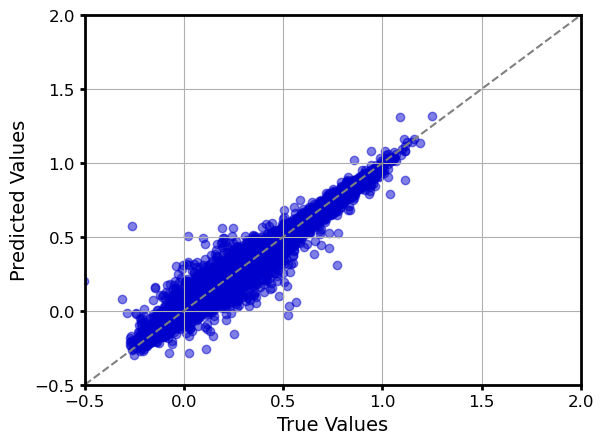

In [59]:
predvals_tensor, truevals_tensor = get_transformer_predictions(test_loader, model, device=device)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [60]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.034
Test MSE = 0.0027
Test RMSE = 0.0521
Test R2 = 0.9503


In [61]:
oneshot_results = pd.DataFrame({"model": "model_6b", "truevals": truevals, "predvals": predvals.squeeze()})
oneshot_results.to_csv("model6b_oneshot.csv")

#### External Test Set

In [34]:
#-----------------------
# load the optimized parameters
#-----------------------

import json

with open("Model6b_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
graph_hidden_dim = optparams["graph_hidden_dim"]
num_graph_layers = optparams["num_graph_layers"]
graph_activation = optparams["graph_activation"]
graph_dropout = optparams["graph_dropout"]
use_fusion = optparams["use_fusion"]
fusion_dim = optparams["fusion_dim"]
pooling = optparams["pooling"]
head_activation = optparams["head_activation"]
head_dim = optparams["head_dim"]

#-----------------------
# load model from checkpoint
#-----------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k", clean_up_tokenization_spaces=False)
model = ChemBERTaGraphHybrid(
    chemberta_name="seyonec/PubChem10M_SMILES_BPE_450k",
    node_feat_dim=6,      # must match Data.x size (= input dimension for the graph encoder)
    graph_hidden_dim=graph_hidden_dim,
    num_graph_layers=num_graph_layers,
    fusion_dim=fusion_dim,
    graph_activation=graph_activation,
    graph_dropout=graph_dropout,
    head_activation=head_activation,
    head_dim=head_dim,
    use_fusion=use_fusion,
    pooling=pooling
).to(device)
model.load_state_dict(torch.load("model6b_trial_8.pt", map_location=device))


Optimized parameters loaded: {'batch_size': 32, 'graph_hidden_dim': 192, 'num_graph_layers': 5, 'graph_activation': 'gelu', 'graph_dropout': 0.05847830533540346, 'use_fusion': False, 'fusion_dim': 512, 'pooling': 'mean', 'head_activation': 'silu', 'head_dim': 128, 'lr': 3.093908069838242e-05, 'weight_decay': 4.3199394822067256e-05}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/PubChem10M_SMILES_BPE_450k
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

In [35]:
external_a = pd.read_csv("extrapolation_data_2.txt")
external_a["canon_SMILES"] = [canonicalize(s) for s in external_a["SMILES"].values]
test_smiles = external_a["canon_SMILES"].values
test_stg = external_a["STG"].values
tst_ds = MolHybridDataset(smiles_list=test_smiles, y_list=test_stg, smiles_to_pyg_fn=smiles_to_pyg)
test_loader = DataLoader(tst_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, pin_memory=True)

Shape of pred tensor: torch.Size([59, 1])
Shape of true tensor: torch.Size([59])


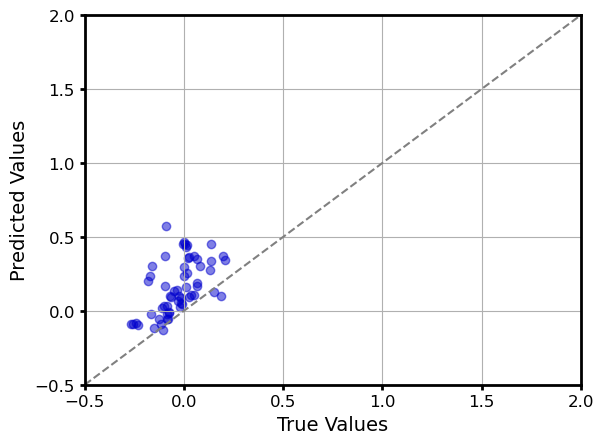

In [36]:
predvals_tensor, truevals_tensor = get_transformer_predictions(test_loader, model, device=device)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [37]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.1955
Test MSE = 0.0599
Test RMSE = 0.2448
Test R2 = -4.0761


In [38]:
oneshot_results = pd.DataFrame({"model": "model_6b", "truevals": truevals, "predvals": predvals.squeeze()})
oneshot_results.to_csv("model6b_external.csv")

In [15]:
# external_a = pd.read_csv("extrapolation_data_1.txt")
external_a = pd.read_csv("extrapolation_data_2.txt")
test_smiles = external_a["SMILES"].values
test_stg = external_a["STG"].values
tst_ds = MolHybridDataset(smiles_list=test_smiles, y_list=test_stg, smiles_to_pyg_fn=smiles_to_pyg)
test_loader = DataLoader(tst_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, pin_memory=True)

Shape of pred tensor: torch.Size([59, 1])
Shape of true tensor: torch.Size([59])


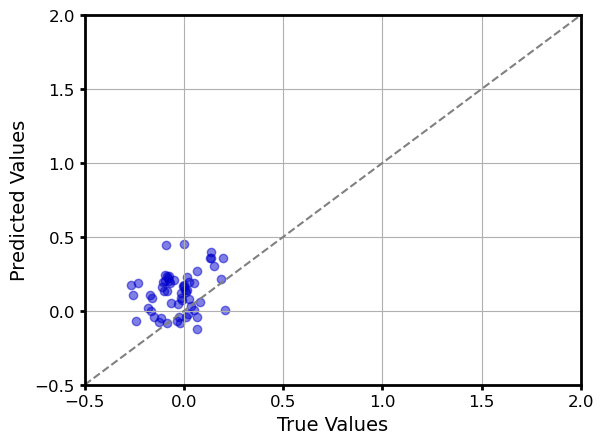

In [16]:
predvals_tensor, truevals_tensor = get_transformer_predictions(test_loader, model, device=device)
truevals = truevals_tensor.detach().cpu().numpy()
predvals = predvals_tensor.detach().cpu().numpy()
truepred_plotter(predvals, truevals)

In [17]:
mae = mean_absolute_error(truevals, predvals)
rmse = root_mean_squared_error(truevals, predvals)
mse = mean_squared_error(truevals, predvals)
r2 = r2_score(truevals, predvals)

print(f"Test MAE = {np.round(mae, 4)}")
print(f"Test MSE = {np.round(mse, 4)}")
print(f"Test RMSE = {np.round(rmse, 4)}")
print(f"Test R2 = {np.round(r2, 4)}")

Test MAE = 0.1847
Test MSE = 0.0486
Test RMSE = 0.2205
Test R2 = -3.12


In [25]:
oneshot_results = pd.DataFrame({"model": "model_6b", "truevals": truevals, "predvals": predvals.squeeze()})
oneshot_results.to_csv("model6b_external.csv")

### Single SMILES Prediction

In [113]:
from rdkit import Chem

def canonicalize(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")
    return Chem.MolToSmiles(mol, canonical=True)

def get_prediction(smiles, model, device="cpu"): # single smiles prediction
    model.eval()
    smiles = canonicalize(smiles)
    chem_input = tokenizer(
        [smiles],
        padding="max_length", # padding=True fails for short SMILES
        truncation=True,
        return_tensors="pt",
        max_length=64)
    chem_input = {k: v.to(device) for k, v in chem_input.items()}
    graph_input = smiles_to_pyg(smiles)
    graph_input = graph_input.to(device)
    with torch.no_grad():
        prediction = model(chem_input, graph_input)
    prediction = prediction.detach().cpu().numpy()
    return round(prediction.item(), 4)

In [114]:
#-----------------------
# load the optimized parameters
#-----------------------

import json

with open("Model6b_optparams.json", "r") as f:
    optparams = json.load(f)
print(f"Optimized parameters loaded: {optparams}")

batch_size = optparams["batch_size"]
graph_hidden_dim = optparams["graph_hidden_dim"]
num_graph_layers = optparams["num_graph_layers"]
graph_activation = optparams["graph_activation"]
graph_dropout = optparams["graph_dropout"]
use_fusion = optparams["use_fusion"]
fusion_dim = optparams["fusion_dim"]
pooling = optparams["pooling"]
head_activation = optparams["head_activation"]
head_dim = optparams["head_dim"]

#-----------------------
# load model from checkpoint
#-----------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("seyonec/PubChem10M_SMILES_BPE_450k", clean_up_tokenization_spaces=False)
model = ChemBERTaGraphHybrid(
    chemberta_name="seyonec/PubChem10M_SMILES_BPE_450k",
    node_feat_dim=6,      # must match Data.x size (= input dimension for the graph encoder)
    graph_hidden_dim=graph_hidden_dim,
    num_graph_layers=num_graph_layers,
    fusion_dim=fusion_dim,
    graph_activation=graph_activation,
    graph_dropout=graph_dropout,
    head_activation=head_activation,
    head_dim=head_dim,
    use_fusion=use_fusion,
    pooling=pooling
).to(device)
model.load_state_dict(torch.load("model6b_trial_8.pt", map_location=device))

Optimized parameters loaded: {'batch_size': 32, 'graph_hidden_dim': 192, 'num_graph_layers': 5, 'graph_activation': 'gelu', 'graph_dropout': 0.05847830533540346, 'use_fusion': False, 'fusion_dim': 512, 'pooling': 'mean', 'head_activation': 'silu', 'head_dim': 128, 'lr': 3.093908069838242e-05, 'weight_decay': 4.3199394822067256e-05}


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/PubChem10M_SMILES_BPE_450k
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>

In [115]:
cyclazine = "C1=CC=C2C=CC=C3C=CC=C1N23"
cyclazine_v2 = "C1C=CC2=CC=CC3=CC=CC=1N23"
heptazine = "N1=CN=C2N=CN=C3N=CN=C1N23"
get_prediction(heptazine, model)

-0.0187

Graph featurization is probably non-determinstic and causes slight deviations in the predictions of the same input.

In [117]:
print(canonicalize(cyclazine))
print(canonicalize(cyclazine_v2))
print(canonicalize(cyclazine) == canonicalize(cyclazine_v2))
print(get_prediction(cyclazine, model))
print(get_prediction(cyclazine_v2, model))

C1=CC2=CC=CC3=CC=CC(=C1)N23
C1=CC2=CC=CC3=CC=CC(=C1)N23
True
0.5732
0.5729


In [118]:
get_prediction("Nc1ccc2c(N)c3c(N)cc(N)c3c(N)c2cc1", model)

-0.1053

In [119]:
get_prediction("C1C=CC=C1", model)

2.1786

## CV statistics

These provide more statistical power than the one‑shot evaluation on the test set.

### repeated measures ANOVA

In [1]:
import pandas as pd

all_dfs = []
xgboost_CV = pd.read_csv("xgboost_5x5CV.csv", index_col=0).query("subset == 'valid'")
xgboost_CV["model"] = "XGBoost"
xgboost_CV["subject"] = [i for i in range(25)]
all_dfs.append(xgboost_CV)

# for i in range(1, 6):
for i in (1, 2, 3, 4, "4b", 5, 6, "6b"):
    df = (pd.read_csv(f"model{i}_5x5CV.csv", index_col=0)
          .query("subset == 'valid'")
          .assign(model=f"model_{i}"))
    df["subject"] = [i for i in range(25)]
    all_dfs.append(df)

final_CV = pd.concat(all_dfs, ignore_index=True)

In [2]:
# import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM

# final_CV must contain: subject, model, score
# subject = fold index (0–24)
# model = model_1, model_2, ...
# score = validation score

anova = AnovaRM(
    data=final_CV,
    depvar="rmse",
    subject="subject",
    within=["model"]).fit()

print(anova)

                Anova
      F Value  Num DF  Den DF  Pr > F
-------------------------------------
model 245.6406 8.0000 192.0000 0.0000



### Tukey HSD

In [3]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

all_dfs = []
xgboost_CV = pd.read_csv("xgboost_5x5CV.csv", index_col=0).query("subset == 'valid'")
xgboost_CV["model"] = "XGBoost"
all_dfs.append(xgboost_CV)

# for i in range(1, 6):
for i in (1, 2, 3, 4, "4b", 5, 6, "6b"):
    df = (pd.read_csv(f"model{i}_5x5CV.csv", index_col=0)
          .query("subset == 'valid'")
          .assign(model=f"model_{i}"))
    all_dfs.append(df)

final_CV = pd.concat(all_dfs, ignore_index=True)

In [4]:
tukey = pairwise_tukeyhsd(endog=final_CV["rmse"], groups=final_CV["model"], alpha=0.05)
print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
 XGBoost  model_1  -0.0149    0.0 -0.0182 -0.0116   True
 XGBoost  model_2  -0.0382    0.0 -0.0415 -0.0349   True
 XGBoost  model_3  -0.0135    0.0 -0.0168 -0.0102   True
 XGBoost  model_4  -0.0208    0.0 -0.0241 -0.0175   True
 XGBoost model_4b  -0.0295    0.0 -0.0328 -0.0262   True
 XGBoost  model_5  -0.0238    0.0 -0.0271 -0.0205   True
 XGBoost  model_6  -0.0265    0.0 -0.0298 -0.0232   True
 XGBoost model_6b  -0.0325    0.0 -0.0358 -0.0292   True
 model_1  model_2  -0.0233    0.0 -0.0266   -0.02   True
 model_1  model_3   0.0014 0.9364  -0.002  0.0047  False
 model_1  model_4  -0.0059    0.0 -0.0092 -0.0026   True
 model_1 model_4b  -0.0147    0.0  -0.018 -0.0113   True
 model_1  model_5  -0.0089    0.0 -0.0122 -0.0056   True
 model_1  model_6  -0.0116    0.0 -0.0149 -0.0083   True
 model_1 model_6b  -0.0177    0

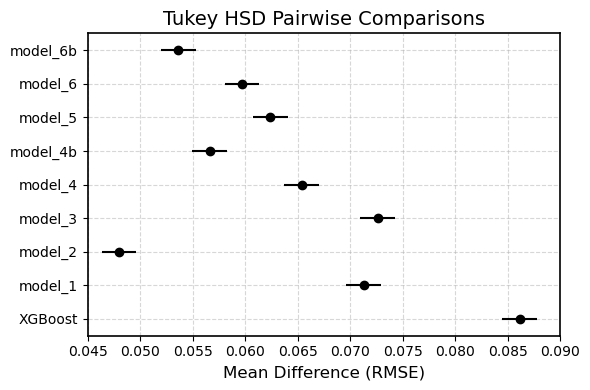

In [5]:
import matplotlib.pyplot as plt

# Generate the Tukey plot
fig = tukey.plot_simultaneous()

# Extract the axes
ax = fig.axes[0]

# --- Customize the plot ---
ax.set_title("Tukey HSD Pairwise Comparisons", fontsize=14)
ax.set_xlabel("Mean Difference (RMSE)", fontsize=12)
# ax.set_ylabel("Model Comparison", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.5)
ax.tick_params(axis="both", labelsize=10)
# print(ax.get_yticks()) # [-1  0  1  2  3  4  5  6]
ax.set_xlim(0.045,0.09)
ax.set_ylim(-0.5,8.5)

# Change axis spine style
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("black")

# Optional: change figure size
fig.set_size_inches(6, 4)

plt.tight_layout()
plt.show()
plt.close()

## One-Shot Figure

In [20]:
import pandas as pd

xgb_df = pd.read_csv("XGBoost_oneshot.csv", index_col=0)
oneshots = [xgb_df]

for i in (1, 2, 3, 4, "4b", 5, 6, "6b"):
    df = (pd.read_csv(f"model{i}_oneshot.csv", index_col=0))
    oneshots.append(df)

oneshot_df = pd.concat(oneshots, ignore_index=True)

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def plot_model_grid_with_metrics(df):
    models = df["model"].unique()
    n = len(models)

    # Compute global x/y limits
    global_xmin = df["truevals"].min() * 1.1
    global_xmax = df["truevals"].max() * 1.1
    global_ymin = df["predvals"].min() * 1.1
    global_ymax = df["predvals"].max() * 1.1
    
    fig, axes = plt.subplots(3, 3, figsize=(12, 8))
    axes = axes.flatten()

    for i, (ax, model) in enumerate(zip(axes, models)):
        sub = df[df["model"] == model]
        x = sub["truevals"].values
        y = sub["predvals"].values

        # Regression line (least squares)
        slope, intercept = np.polyfit(x, y, 1)
        reg_line = slope * x + intercept

        # Metrics
        mae = mean_absolute_error(x, y)
        rmse = root_mean_squared_error(x, y)
        mse = mean_squared_error(x, y)
        r2 = r2_score(x, y)   

        # Scatter plot
        ax.scatter(x, y, s=20, alpha=0.7)

        # Regression line
        ax.plot(x, reg_line, color="green", linewidth=2)

        # y = x reference line
        ax.plot([x.min(), x.max()], [x.min(), x.max()],
                color="red", linestyle="--", linewidth=1)

        # Annotation (top-left)
        ax.text(0.02, 0.98,
                f"MAE: {mae:.4f}\nMSE: {mse:.3f}\nRMSE: {rmse:.3f}\nR²: {r2:.3f}",
                transform=ax.transAxes,
                fontsize=12,
                linespacing=1.25,
                verticalalignment="top")

        # Apply global limits
        ax.set_xlim(global_xmin, global_xmax)
        ax.set_ylim(global_ymin, global_ymax)
        
        ax.set_title(model, size=14)
        # ax.set_title(f"{i}")
        # Remove inner axies labels/ticks
        if i in range(6):
            if (i == 0) or (i == 3):
                ax.set_xlabel("")
                ax.set_xticklabels([])
                ax.tick_params(axis="x", which="both", length=0)
                ax.set_ylabel(r"STG$_{pred}$ [eV]", size=12)
            else:
                ax.set_xlabel("")
                ax.set_xticklabels([])
                ax.tick_params(axis="x", which="both", length=0)
                ax.set_ylabel("")
                ax.set_yticklabels([])
                ax.tick_params(axis="y", which="both", length=0)
        else:
            if i == 6:
                ax.set_xlabel(r"STG$_{true}$ [eV]", size=12)
                ax.set_ylabel(r"STG$_{pred}$ [eV]", size=12)
            else:
                ax.set_xlabel(r"STG$_{true}$ [eV]", size=12)
                ax.set_ylabel("")
                ax.set_yticklabels([])
                ax.tick_params(axis="y", which="both", length=0)
        
        ax.grid(alpha=0.3)

    # Hide unused axes if fewer than 8 models
    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout(pad=1.0)
    plt.savefig('test.png', bbox_inches='tight', pad_inches=0.05)
    # plt.show()


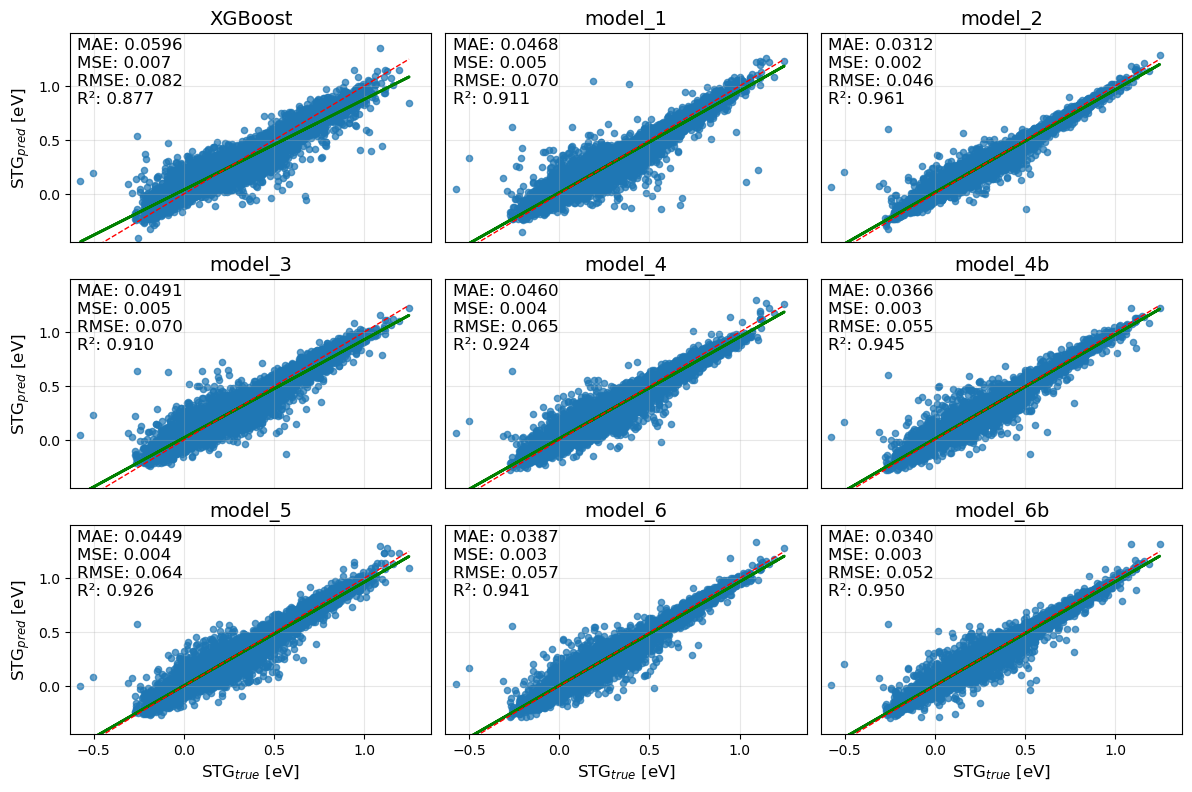

In [26]:
plot_model_grid_with_metrics(oneshot_df)

In [1]:
import pandas as pd

oneshots = []
for i in (2, "4b", "6b"):
    df = (pd.read_csv(f"model{i}_external.csv", index_col=0))
    oneshots.append(df)

oneshot_df = pd.concat(oneshots, ignore_index=True)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

def plot_model_grid_with_metrics(df):
    models = df["model"].unique()
    n = len(models)

    # Compute global x/y limits
    global_xmin = df["truevals"].min() * 1.1
    global_xmax = df["truevals"].max() * 1.1
    global_ymin = df["predvals"].min() * 1.1
    global_ymax = df["predvals"].max() * 1.1
    
    fig, axes = plt.subplots(3, 1, figsize=(5, 8))
    axes = axes.flatten()

    for i, (ax, model) in enumerate(zip(axes, models)):
        sub = df[df["model"] == model]
        x = sub["truevals"].values
        y = sub["predvals"].values

        # Regression line (least squares)
        slope, intercept = np.polyfit(x, y, 1)
        reg_line = slope * x + intercept

        # Metrics
        mae = mean_absolute_error(x, y)
        rmse = root_mean_squared_error(x, y)
        mse = mean_squared_error(x, y)
        r2 = r2_score(x, y)   

        # Scatter plot
        ax.scatter(x, y, s=20, alpha=0.7)

        # Regression line
        ax.plot(x, reg_line, color="green", linewidth=2)

        # y = x reference line
        ax.plot([x.min(), x.max()], [x.min(), x.max()],
                color="red", linestyle="--", linewidth=1)

        # Annotation (top-left)
        ax.text(0.02, 0.98,
                f"MAE: {mae:.4f}\nMSE: {mse:.3f}\nRMSE: {rmse:.3f}\nR²: {r2:.3f}",
                transform=ax.transAxes,
                fontsize=12,
                linespacing=1.25,
                verticalalignment="top")

        # Apply global limits
        # ax.set_xlim(global_xmin, global_xmax)
        # ax.set_ylim(global_ymin, global_ymax)
        ax.set_xlim(global_xmin, global_xmax)
        ax.set_ylim(-0.35, 1.25)

        ax.set_title(model, size=14)
        # ax.set_title(f"{i}")
        # Remove inner axies labels/ticks
        if (i == 0) or (i == 1):
            ax.set_xlabel("")
            ax.set_xticklabels([])
            ax.tick_params(axis="x", which="both", length=0)
            ax.set_ylabel(r"STG$_{pred}$ [eV]", size=12)
        else:
            ax.set_xlabel(r"STG$_{true}$ [eV]", size=12)
            ax.set_ylabel(r"STG$_{pred}$ [eV]", size=12)

        
        ax.grid(alpha=0.3)

    # Hide unused axes if fewer than 8 models
    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout(pad=1.0)
    plt.savefig('externals.png', bbox_inches='tight', pad_inches=0.05)
    # plt.show()


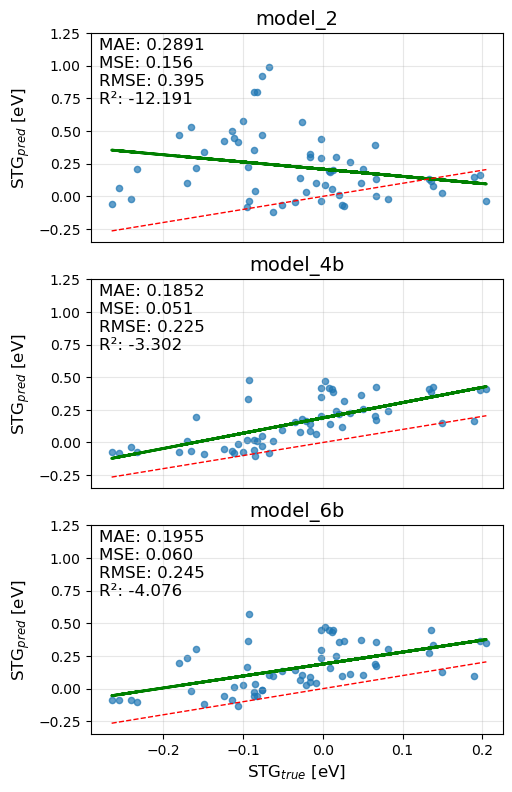

In [3]:
plot_model_grid_with_metrics(oneshot_df)

## External Set Similarity

In [39]:
import pandas as pd

external_df = pd.read_csv("extrapolation_data_2.txt")
aag_smiles = pd.read_csv("AAG_numbers_smiles.csv")
# external_df.head(n=15)

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import pandas as pd
import matplotlib.pyplot as plt

def canonicalize(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")
    return Chem.MolToSmiles(mol, canonical=True)

def tanimoto_to_df(df, input_smiles_, smiles_col="SMILES"):
    """
    Compute Tanimoto similarity between an input SMILES and all SMILES in df[smiles_col].
    Returns a Pandas Series of similarity values.
    """

    input_smiles = canonicalize(input_smiles_)
    mol_query = Chem.MolFromSmiles(input_smiles)

    gen = GetMorganGenerator(radius=2, fpSize=2048)
    fp_query = gen.GetFingerprint(mol_query)

    similarities = []

    for smi in df[smiles_col]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            similarities.append(None)
            continue

        fp = gen.GetFingerprint(mol)
        sim = DataStructs.TanimotoSimilarity(fp_query, fp)
        similarities.append(sim)

    return pd.Series(similarities, index=df.index)


def simple_tanimoto(input_smiles_, ref_smiles_):
    """
    Compute Tanimoto similarity between an input SMILES and a reference SMILES.
    """
    input_smiles = canonicalize(input_smiles_)
    ref_smiles = canonicalize(ref_smiles_)

    mol_query = Chem.MolFromSmiles(input_smiles)
    mol_ref = Chem.MolFromSmiles(ref_smiles)

    gen = GetMorganGenerator(radius=2, fpSize=2048)

    fp_query = gen.GetFingerprint(mol_query)
    fp_ref = gen.GetFingerprint(mol_ref)

    return DataStructs.TanimotoSimilarity(fp_query, fp_ref)


def plot_tanimoto_hist(similarities, bins=30):
    """
    Plot a histogram of Tanimoto similarity values.
    `similarities` should be a Pandas Series or list of floats.
    """
    # Drop None or NaN values
    sims = pd.Series(similarities).dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(sims, bins=bins, color="steelblue", edgecolor="black", alpha=0.8)
    plt.xlabel("Tanimoto similarity")
    plt.ylabel("Count")
    plt.title("Distribution of Tanimoto similarities")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


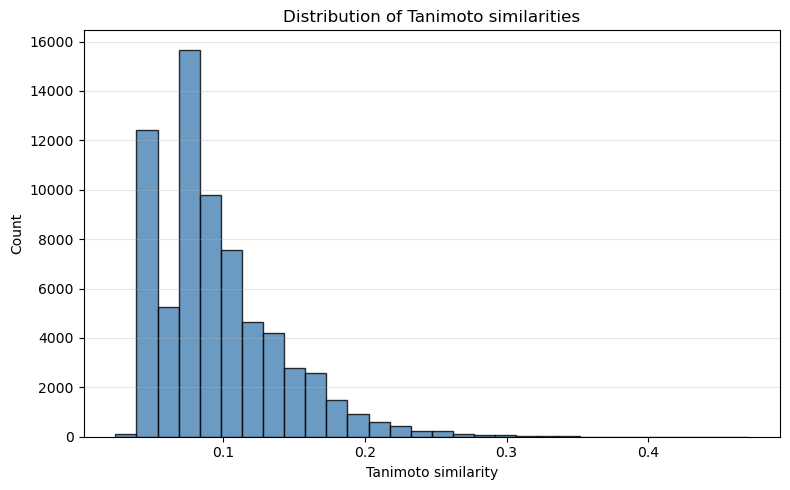

In [46]:
sims = tanimoto_to_df(aag_smiles, external_df["SMILES"][0])
plot_tanimoto_hist(sims)
plt.close()

In [47]:
print(sims.mean())
print(sims.sort_values()[-10:].mean())
print(sims.sort_values()[-5:].mean())
print(sims.max())

0.09612939677229718
0.4191657335911273
0.44007059761703726
0.47058823529411764


In [48]:
maxsims = []
top5sims = []
top10sims = []
meansims = []
most_similars = []
for i in external_df["SMILES"]:
    x = tanimoto_to_df(aag_smiles, i)
    maxsims.append(x.max())
    meansims.append(x.mean())
    most_similars.append(aag_smiles.loc[x.idxmax(), "SMILES"])
    top5sims.append(x.sort_values()[-5:].mean())
    top10sims.append(x.sort_values()[-10:].mean())

In [49]:
sims_df = pd.DataFrame({"SMILES": external_df["SMILES"], "max_sim": maxsims, "top5_sim": top5sims, "top10_sim": top10sims, "mean_sim": meansims, "most_similar": most_similars})
sims_df.to_csv("externals_similarity.csv")

In [50]:
ext_fulldf = external_df.merge(sims_df)

In [51]:
model2_extpreds = pd.read_csv("model2_external.csv", index_col=0)
ext_fulldf["model2_predvals"] = model2_extpreds["predvals"]
# ext_fulldf["model2_truevals"] = model2_extpreds["truevals"] # to check if df orderings match
model4b_extpreds = pd.read_csv("model4b_external.csv", index_col=0)
ext_fulldf["model4b_predvals"] = model4b_extpreds["predvals"]
model6b_extpreds = pd.read_csv("model6b_external.csv", index_col=0)
ext_fulldf["model6b_predvals"] = model6b_extpreds["predvals"]
ext_fulldf.to_csv("externals_allinone.csv")
ext_fulldf.head(n=15)

,SMILES,STG,max_sim,top5_sim,top10_sim,mean_sim,most_similar,model2_predvals,model4b_predvals,model6b_predvals
0,C1C=CC2C=CC3=CC=CC4C=CC=1C=4C=23,0.026,0.470588,0.440071,0.419166,0.096129,c1ccc2ccc3cccc3c2cc1,-0.070357,0.319277,0.366052
1,C1C=CC2C=CC3=C(O)C=C(O)C4C=CC=1C=4C=23,0.007,0.378378,0.371736,0.363844,0.101996,N#Cc1c(N)cccc2ccc3c(N)cc(N)c3c12,0.197750,0.418506,0.448921
2,C1C=CC2C=CC3=C(OC)C=C(OC)C4C=CC=1C=4C=23,0.011,0.342857,0.335341,0.328485,0.096567,Nc1ccc2ccc3cccc3c2c(N)c1,0.056810,0.412176,0.434779
3,C1(O)C=C(O)C2C=CC3=C(O)C=C(O)C4C=CC=1C=4C=23,-0.003,0.269231,0.248674,0.238745,0.092003,Nc1ccc2c(N)c3c(N)cc(N)c3c(N)c2cc1,0.292689,0.347649,0.452480
4,C1(OC)C=C(OC)C2C=CC3=C(OC)C=C(OC)C4C=CC=1C=4C=23,0.013,0.241379,0.224687,0.216533,0.086682,Nc1ccc2c(N)c3c(N)cc(N)c3c(N)c2cc1,0.202401,0.383906,0.448136
5,C1C(C(F)(F)F)=CC2C=CC3=CC(C(F)(F)F)=CC4C=CC=1C...,0.017,0.266667,0.249284,0.242289,0.092075,Nc1ccccc2cc3ccc(N)c3c(N)c12,0.302161,0.242313,0.253165
6,C1C=CC2C(C#N)=C(C#N)C3=CC=CC4C(C#N)=C(C#N)C=1C...,-0.002,0.619048,0.575305,0.553043,0.193887,N#Cc1c2cccccc2c(C#N)c2cccc12,-0.032111,0.203135,0.294488
7,C1C=CC=C2C=CC=CC3C=CC=1C2=3,0.081,0.470588,0.443436,0.421718,0.093475,c1ccc2ccc3cccc3c2cc1,-0.023753,0.244467,0.300537
8,C1C(C#N)=CC=C2C=CC(C#N)=CC3C=CC=1C2=3,0.048,0.600000,0.573838,0.552960,0.182507,N#Cc1ccc(N)c2c(ccc3ccc(C#N)c32)c1,0.104142,0.362998,0.371817
9,C1C=C(N)C=C2C=C(N)C=CC3C=CC=1C2=3,0.020,0.560000,0.494222,0.478943,0.147299,Nc1ccc2ccc3cc(N)cc3c2c(N)c1,0.007562,0.214433,0.357232


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_stg_sim(df):
    x = df["top5_sim"]
    truevals = df["STG"].values
    models = ["model2", "model4b", "model6b"]

    # Compute global x/y limits
    # global_xmin = 0.03
    # global_xmax = 0.22
    global_xmin = 0.1
    global_xmax = 0.7
    
    fig, axes = plt.subplots(3, 1, figsize=(5, 8))
    axes = axes.flatten()

    for i, (ax, model) in enumerate(zip(axes, models)):
        predvals = df[f"{model}_predvals"].values
        y = abs(predvals - truevals)

        # Regression line (least squares)
        slope, intercept = np.polyfit(x, y, 1)
        reg_line = slope * x + intercept

        # Metrics
        # mae = mean_absolute_error(x, y)
        # rmse = root_mean_squared_error(x, y)
        # mse = mean_squared_error(x, y)
        # r2 = r2_score(x, y)
        r, p = pearsonr(x, y)

        # Scatter plot
        ax.scatter(x, y, s=20, alpha=0.7)

        # Regression line
        ax.plot(x, reg_line, color="green", linewidth=2)

        # y = x reference line
        # ax.plot([global_xmin, global_xmax], [x.min(), global_xmax],
        #         color="red", linestyle="--", linewidth=1)

        # Annotation (top-left)
        ax.text(0.77, 0.95,
                f"r: {r:.4f}\np: {p:.4f}",
                transform=ax.transAxes,
                fontsize=12,
                linespacing=1.3,
                verticalalignment="top")

        # Apply global limits
        # ax.set_xlim(global_xmin, global_xmax)
        # ax.set_ylim(global_ymin, global_ymax)
        ax.set_xlim(global_xmin, global_xmax)
        ax.set_ylim(-0.05, 1.2)

        ax.set_title(model, size=14)
        # ax.set_title(f"{i}")
        # Remove inner axies labels/ticks
        if (i == 0) or (i == 1):
            ax.set_xlabel("")
            ax.set_xticklabels([])
            ax.tick_params(axis="x", which="both", length=0)
            ax.set_ylabel("ΔSTG [eV]", size=12)
        else:
            ax.set_xlabel(r"t$_{top5}$", size=12)
            ax.set_ylabel("ΔSTG [eV]", size=12)
        
        ax.grid(alpha=0.3)

    plt.tight_layout(pad=1.0)
    plt.savefig('similarities_vs_MAE.png', bbox_inches='tight', pad_inches=0.05)
    # plt.show()


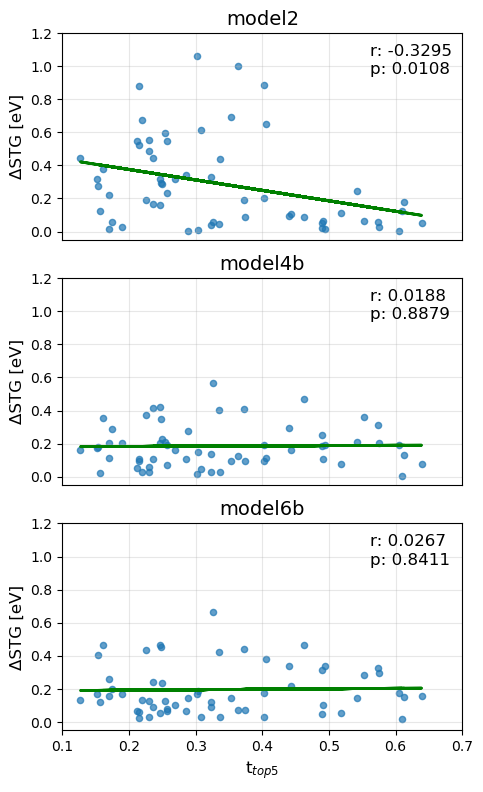

In [53]:
plot_stg_sim(ext_fulldf)

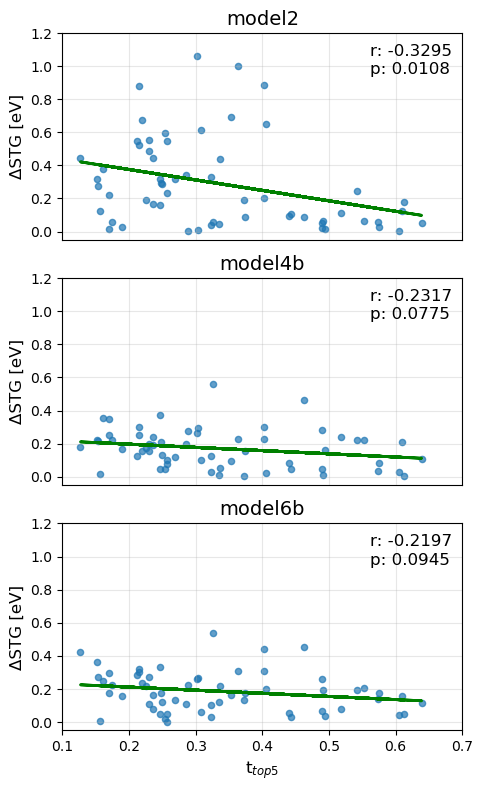

In [98]:
plot_stg_sim(ext_fulldf)

In [54]:
model2_errors = ext_fulldf.get(["SMILES","STG","model2_predvals"])
model2_errors["abs_err"] = abs(model2_errors["model2_predvals"] - model2_errors["STG"])

In [55]:
model2_errors.sort_values(by=["abs_err"])[-10:]

,SMILES,STG,model2_predvals,abs_err
50,N1C=NC2=NC=NC3=CC(O)=CC=1N23,-0.111,0.443678,0.554678
13,C1(O)C=C(O)C=C2C=C(O)C=C(O)C3C=CC=1C2=3,-0.026,0.571082,0.597082
36,N1=C(C#N)N=C2N3C(=NC(C#N)=N2)N=CN=C13,-0.114,0.497492,0.611492
41,C1C(N)=CC2=CC(N)=CC3=CC(N)=CC=1N23,-0.181,0.471966,0.652966
51,N1C=NC2=NC=NC3=CC(OC)=CC=1N23,-0.100,0.574903,0.674903
30,N1C2=NC=NC3=NC=NC(=NC=1)N23,-0.166,0.529074,0.695074
55,N1C=NC2=NC=NC3=CC=C(C(F)(F)F)C=1N23,-0.087,0.795678,0.882678
58,N1C=NC2=NC=NC3=C(C#N)C=C(C#N)C=1N23,-0.083,0.802322,0.885322
56,N1C=NC2=NC=NC3=CC=C(C#N)C=1N23,-0.077,0.925301,1.002301
49,N1C=NC2=NC=NC3=CC=CC=1N23,-0.068,0.992115,1.060115


In [56]:
model4b_errors = ext_fulldf.get(["SMILES","STG","model4b_predvals"])
model4b_errors["abs_err"] = abs(model4b_errors["model4b_predvals"] - model4b_errors["STG"])

In [57]:
model4b_errors.sort_values(by=["abs_err"])[-10:]

,SMILES,STG,model4b_predvals,abs_err
3,C1(O)C=C(O)C2C=CC3=C(O)C=C(O)C4C=CC=1C=4C=23,-0.003,0.347649,0.350649
42,C1C(N(C)C)=CC2=CC(N(C)C)=CC3=CC(N(C)C)=CC=1N23,-0.159,0.198748,0.357748
20,C12=C3C(N)=CC1=CC=C1C=C(N)C=C(N)C1=C2C=C3N,0.067,0.426969,0.359969
4,C1(OC)C=C(OC)C2C=CC3=C(OC)C=C(OC)C4C=CC=1C=4C=23,0.013,0.383906,0.370906
2,C1C=CC2C=CC3=C(OC)C=C(OC)C4C=CC=1C=4C=23,0.011,0.412176,0.401176
1,C1C=CC2C=CC3=C(O)C=C(O)C4C=CC=1C=4C=23,0.007,0.418506,0.411506
21,C12=C3C(O)=CC1=CC=C1C=C(O)C=C(O)C1=C2C=C3O,-0.002,0.414596,0.416596
39,C1C(O)=CC2=CC(O)=CC3=CC=CC=1N23,-0.094,0.329248,0.423248
44,C1C(C#N)=CC2=CC(C#N)=CC3=CC=CC=1N23,0.002,0.472397,0.470397
38,C1C=CC2=CC=CC3=CC=CC=1N23,-0.093,0.475072,0.568072


In [58]:
model6b_errors = ext_fulldf.get(["SMILES","STG","model6b_predvals"])
model6b_errors["abs_err"] = abs(model6b_errors["model6b_predvals"] - model6b_errors["STG"])

In [59]:
model6b_errors.sort_values(by=["abs_err"])[-10:]

,SMILES,STG,model6b_predvals,abs_err
41,C1C(N)=CC2=CC(N)=CC3=CC(N)=CC=1N23,-0.181,0.199542,0.380542
40,C1C(O)=CC2=CC(O)=CC3=CC(O)=CC=1N23,-0.171,0.236180,0.407180
2,C1C=CC2C=CC3=C(OC)C=C(OC)C4C=CC=1C=4C=23,0.011,0.434779,0.423779
4,C1(OC)C=C(OC)C2C=CC3=C(OC)C=C(OC)C4C=CC=1C=4C=23,0.013,0.448136,0.435136
1,C1C=CC2C=CC3=C(O)C=C(O)C4C=CC=1C=4C=23,0.007,0.448921,0.441921
3,C1(O)C=C(O)C2C=CC3=C(O)C=C(O)C4C=CC=1C=4C=23,-0.003,0.452480,0.455480
39,C1C(O)=CC2=CC(O)=CC3=CC=CC=1N23,-0.094,0.367782,0.461782
42,C1C(N(C)C)=CC2=CC(N(C)C)=CC3=CC(N(C)C)=CC=1N23,-0.159,0.303426,0.462426
44,C1C(C#N)=CC2=CC(C#N)=CC3=CC=CC=1N23,0.002,0.468582,0.466582
38,C1C=CC2=CC=CC3=CC=CC=1N23,-0.093,0.571858,0.664858


In [60]:
"C1=CC=C2C=CC=C3C=CC=C1N23"
"C1C=CC2=CC=CC3=CC=CC=1N23"

'C1C=CC2=CC=CC3=CC=CC=1N23'

In [61]:
from rdkit import Chem

def canonicalize(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")
    return Chem.MolToSmiles(mol, canonical=True)

In [62]:
smi_to_pred = ["C1=CC=C1", "N#CC1=C(N)C(C#N)=C1N"]
smi_to_pred = "C1=CC=C1"
canonicalize(smi_to_pred)

'C1=CC=C1'